# Supporting Information Notebook: Replogle perturbation analysis of gene-level support

This notebook reproduces the Replogle dataset analyses used in the manuscript (**Results Section 3.7** and related figures).

**Purpose**
- construct the regulator-focused Replogle benchmark
- train and evaluate MM-KPNN on perturbation classification
- quantify concept-level selectivity and perturbation fingerprints
- evaluate gene-level mechanistic support using attribution-based overlap analyses
- export summary tables and exact figure inputs used in the manuscript

**Execution**
- Run the notebook sequentially from top to bottom.
- The notebook is organized into analysis blocks that map directly onto the manuscript narrative.
- Final figure-generation code is separated into export cells near the end so that plotting can also be reproduced from saved artifacts.

**Main interpretation**
Replogle defines a heterogeneous perturbation regime: concept-space structure is retained, but mechanistic support varies strongly across perturbations and is not explained by regulator class alone.


### Section 1 — Data loading and prior construction

This section initializes the Replogle Perturb-seq dataset and builds the MM-KPNN biological prior used throughout the notebook.

**Steps**
- load the RPE1 perturbation AnnData object
- standardize perturbation labels and collapse controls
- define the gene universe
- load the pruned TF regulon prior
- align regulons to dataset genes
- build the gene × concept mask
- construct model inputs and labels

**Output**
A dataset-aligned concept prior and the tensors needed for benchmark construction and training.


In [32]:
# =========================================
# MM-KPNN scPerturb Benchmark
# Replogle 2022 RPE1 Perturb-seq
# Section 1: Environment + data loading
# =========================================

import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1. Reproducibility + Scanpy setup
# -------------------------------------------------
SEED = 42
np.random.seed(SEED)

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100)

print("Environment ready")
print("----------------------------------")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scanpy version: {sc.__version__}")
print(f"AnnData version: {ad.__version__}")
print("----------------------------------")
print(f"Random seed set to: {SEED}")

# -------------------------------------------------
# 2. Load Replogle dataset
# -------------------------------------------------
adata_path = "/Users/sally/Desktop/Replogle_dataset/data/ReplogleWeissman2022_rpe1.h5ad"
adata = sc.read_h5ad(adata_path)

print("\nLoaded AnnData")
print(adata)

print("\nobs columns:")
print(list(adata.obs.columns))

# -------------------------------------------------
# 3. Basic perturbation census
# -------------------------------------------------
print("\nTotal cells:", adata.n_obs)
print("Unique perturbations:", adata.obs["gene"].nunique())

print("\nTop perturbations by cell count:")
print(adata.obs["gene"].value_counts().head(20))

print("\nDistribution of nperts:")
print(adata.obs["nperts"].value_counts())

print("\nPerturbation types:")
print(adata.obs["perturbation_type"].value_counts())

# -------------------------------------------------
# 4. Standardize perturbation labels
# -------------------------------------------------
adata.obs["perturbation_label"] = adata.obs["gene"].astype(str)
adata.obs.loc[
    adata.obs["perturbation_label"] == "non-targeting",
    "perturbation_label"
] = "control"

print("\nUnique standardized labels:", adata.obs["perturbation_label"].nunique())

print("\nTop labels:")
print(adata.obs["perturbation_label"].value_counts().head(10))

# -------------------------------------------------
# 5. Freeze gene universe
# -------------------------------------------------
gene_universe = adata.var_names.astype(str)

print("\nNumber of genes in dataset:", len(gene_universe))
print("Example genes:", list(gene_universe[:20]))

# -------------------------------------------------
# 6. Load TF regulon prior
# -------------------------------------------------
tf_regulon_file = "/Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_pruned.tsv"
tf_regulons = pd.read_csv(tf_regulon_file, sep="\t")

print("\nPruned TF regulon prior loaded")
print("Shape:", tf_regulons.shape)
print("Columns:", tf_regulons.columns.tolist())
print("Unique TF concepts:", tf_regulons["tf"].nunique())
print("Unique target genes:", tf_regulons["target"].nunique())

display(tf_regulons.head())

Environment ready
----------------------------------
Python version: 3.10.13
NumPy version: 1.26.4
Pandas version: 2.0.3
Scanpy version: 1.11.5
AnnData version: 0.8.0
----------------------------------
Random seed set to: 42

Loaded AnnData
AnnData object with n_obs × n_vars = 247914 × 8749
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'celltype'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'

obs columns:
['batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 

,tf,target,weight,source
0,BCL3,RPL23A,1.0,DoRothEA_OmniPath
1,BCL3,RPL27A,1.0,DoRothEA_OmniPath
2,BCL3,RPL38,1.0,DoRothEA_OmniPath
3,BCL3,PDE4DIP,1.0,DoRothEA_OmniPath
4,BCL3,CACYBP,1.0,DoRothEA_OmniPath


In [33]:
# =========================================
# Section 1.2 — Align regulons, build mask, and prepare indices only
# =========================================

import numpy as np
import pandas as pd

assert "adata" in globals(), "adata not loaded"
assert "gene_universe" in globals(), "gene_universe missing"
assert "tf_regulons" in globals(), "tf_regulons not loaded"

# 1. Align regulons
tf_regulons["tf"] = tf_regulons["tf"].astype(str)
tf_regulons["target"] = tf_regulons["target"].astype(str)

gene_universe_set = set(gene_universe)

tf_regulons_aligned = tf_regulons[
    tf_regulons["target"].isin(gene_universe_set)
].copy()

print("Aligned regulon table")
print("Original edges:", len(tf_regulons))
print("Aligned edges :", len(tf_regulons_aligned))
print("Retained TF concepts:", tf_regulons_aligned["tf"].nunique())
print("Retained target genes:", tf_regulons_aligned["target"].nunique())

# 2. Build mask
concepts = sorted(tf_regulons_aligned["tf"].unique())
concept_genes = sorted(tf_regulons_aligned["target"].unique())

gene_to_idx = pd.Series(np.arange(len(concept_genes)), index=concept_genes)
concept_to_idx = pd.Series(np.arange(len(concepts)), index=concepts)

rows = tf_regulons_aligned["target"].map(gene_to_idx).to_numpy()
cols = tf_regulons_aligned["tf"].map(concept_to_idx).to_numpy()

mask = np.zeros((len(concept_genes), len(concepts)), dtype=np.float32)
mask[rows, cols] = 1.0

print("\nGene × concept mask")
print("Mask shape:", mask.shape)
print("Mask density:", mask.sum() / mask.size)

# 3. Prepare gene indices only
var_names = pd.Index(adata.var_names.astype(str))
concept_gene_idx = var_names.get_indexer(concept_genes)

if (concept_gene_idx < 0).any():
    missing = np.array(concept_genes)[concept_gene_idx < 0]
    raise ValueError(f"Missing concept genes: {missing[:10]}")

# 4. Keep labels only
y = adata.obs["perturbation_label"].astype(str).values

print("\nPrepared lightweight dataset objects")
print("n concept genes:", len(concept_genes))
print("n gene indices :", len(concept_gene_idx))
print("y shape:", y.shape)
print("Number of perturbation classes:", pd.Series(y).nunique())

print("\nTop labels:")
print(pd.Series(y).value_counts().head(10))

Aligned regulon table
Original edges: 78423
Aligned edges : 49974
Retained TF concepts: 312
Retained target genes: 6015

Gene × concept mask
Mask shape: (6015, 312)
Mask density: 0.02662894046933947

Prepared lightweight dataset objects
n concept genes: 6015
n gene indices : 6015
y shape: (247914,)
Number of perturbation classes: 2394

Top labels:
control    11485
TFAM        3580
SLC1A5      1962
GFM1        1699
MRPL36      1686
TARDBP      1675
PPP6C       1581
MRPL35      1491
NBPF12      1159
CCDC6       1086
Name: count, dtype: int64


### Section 2 — Regulator-focused benchmark construction

This section builds the biologically aligned Replogle benchmark.

**Steps:**
- Expand perturbation set to regulator-enriched genes
- Curate into biologically meaningful categories:
  - TF regulators
  - Chromatin / epigenetic regulators
  - Mixed / other regulators
- Train MM-KPNN with fixed architecture
- Extract:
  - Concept activations
  - Perturbation fingerprints in concept space

**Interpretation:**
This step ensures:
- The task forces **regulatory reasoning**
- Avoids marker-driven shortcuts
- Produces a **regulatory response manifold**

This defines the **biological regime** used for interpretability evaluation.

In [34]:
# === Replogle TF+regulator benchmark: expansion cell ===
# Build a broader regulator-enriched benchmark from Replogle
# while keeping the MM-KPNN architecture fixed

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------------------------------
# 1. Start from perturbation census
# -------------------------------------------------
label_series_full = pd.Series(y, name="perturbation_label").astype(str)
pert_counts = label_series_full.value_counts()

all_perturbations = sorted([p for p in pert_counts.index if p != "control"])
tf_concepts_set = set(concepts)
concept_gene_set = set(concept_genes)

print("Full perturbation space")
print(f"total perturbations (non-control): {len(all_perturbations)}")
print(f"control cells                    : {int((label_series_full == 'control').sum()):,}")

# -------------------------------------------------
# 2. Build regulator candidate sets
# -------------------------------------------------
# A. direct TF concept perturbations
direct_tf_candidates = sorted(set(all_perturbations).intersection(tf_concepts_set))

# B. concept-supporting perturbations with broad regulon participation
target_degree = (
    tf_regulons_aligned.groupby("target")["tf"]
    .nunique()
    .sort_values(ascending=False)
)

target_degree = target_degree[target_degree.index.isin(all_perturbations)]

MIN_REGULON_DEGREE = 8
network_regulator_candidates = sorted(target_degree[target_degree >= MIN_REGULON_DEGREE].index.tolist())

# C. union
regulator_candidates = sorted(set(direct_tf_candidates).union(network_regulator_candidates))

print("\nRegulator candidate construction")
print(f"direct TF perturbations               : {len(direct_tf_candidates)}")
print(f"network-enriched regulator candidates : {len(network_regulator_candidates)}")
print(f"union candidate set                   : {len(regulator_candidates)}")

print("\nTop 30 network-enriched candidates by regulon degree:")
display(target_degree.head(30).rename("n_linked_tf_concepts").to_frame())

# -------------------------------------------------
# 3. Apply benchmark support filter
# -------------------------------------------------
MIN_CELLS = 80

candidate_counts = pert_counts[pert_counts.index.isin(regulator_candidates)].sort_values(ascending=False)
selected_regulators = candidate_counts[candidate_counts >= MIN_CELLS].index.tolist()

print("\nCell-count filtered regulator benchmark")
print(f"min cells per perturbation : {MIN_CELLS}")
print(f"selected perturbations     : {len(selected_regulators)}")

selected_counts_df = (
    candidate_counts[candidate_counts >= MIN_CELLS]
    .rename("n_cells")
    .to_frame()
)
selected_counts_df["is_direct_tf"] = selected_counts_df.index.isin(direct_tf_candidates)
selected_counts_df["regulon_degree"] = selected_counts_df.index.map(target_degree.to_dict()).fillna(0).astype(int)

print("\nSelected perturbations:")
display(selected_counts_df)

# -------------------------------------------------
# 4. Build expanded benchmark cell subset
# -------------------------------------------------
selected_labels_expanded = ["control"] + selected_regulators
cell_mask_expanded = label_series_full.isin(selected_labels_expanded).values

y_expanded = label_series_full[cell_mask_expanded].reset_index(drop=True)

# feature space remains fixed: concept-supporting genes only
X_expanded = adata.X[cell_mask_expanded][:, concept_gene_idx]

if sparse.issparse(X_expanded):
    X_expanded = X_expanded.toarray()
X_expanded = np.asarray(X_expanded, dtype=np.float32)

print("\nExpanded benchmark dataset")
print(f"X_expanded shape : {X_expanded.shape}")
print(f"classes          : {y_expanded.nunique()}")

print("\nExpanded label distribution:")
print(y_expanded.value_counts())

# -------------------------------------------------
# 5. Encode labels and reproducible splits
# -------------------------------------------------
label_encoder_expanded = LabelEncoder()
y_expanded_encoded = label_encoder_expanded.fit_transform(y_expanded.values)
expanded_class_names = list(label_encoder_expanded.classes_)

all_idx = np.arange(len(y_expanded))

train_idx_exp, temp_idx_exp = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=y_expanded.values
)

val_idx_exp, test_idx_exp = train_test_split(
    temp_idx_exp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_expanded.iloc[temp_idx_exp].values
)

split_exp = np.full(len(y_expanded), "train", dtype=object)
split_exp[val_idx_exp] = "val"
split_exp[test_idx_exp] = "test"

split_exp_series = pd.Series(split_exp, name="split")
print("\nExpanded split sizes:")
print(split_exp_series.value_counts())

print("\nExpanded split × label table:")
display(pd.crosstab(split_exp_series, y_expanded))

# -------------------------------------------------
# 6. Rebuild benchmark mask in the same feature order
# -------------------------------------------------
benchmark_genes_expanded = pd.Index(np.array(concept_genes, dtype=str), name="gene_symbol")
concept_names_expanded = pd.Index(sorted(tf_regulons_aligned["tf"].astype(str).unique()), name="concept")

gene_to_idx = {g: i for i, g in enumerate(benchmark_genes_expanded)}
concept_to_idx = {c: j for j, c in enumerate(concept_names_expanded)}

mask_expanded = np.zeros((len(benchmark_genes_expanded), len(concept_names_expanded)), dtype=np.float32)

mapped_edges = 0
for row in tf_regulons_aligned.itertuples(index=False):
    tf = str(row.tf)
    target = str(row.target)
    if (target in gene_to_idx) and (tf in concept_to_idx):
        mask_expanded[gene_to_idx[target], concept_to_idx[tf]] = 1.0
        mapped_edges += 1

print("\nExpanded benchmark mask")
print(f"mask shape   : {mask_expanded.shape}")
print(f"mapped edges : {mapped_edges:,}")

# -------------------------------------------------
# 7. Torch tensors
# -------------------------------------------------
train_mask_exp = (split_exp_series.values == "train")
val_mask_exp   = (split_exp_series.values == "val")
test_mask_exp  = (split_exp_series.values == "test")

X_train_exp = X_expanded[train_mask_exp]
X_val_exp   = X_expanded[val_mask_exp]
X_test_exp  = X_expanded[test_mask_exp]

y_train_exp = y_expanded_encoded[train_mask_exp]
y_val_exp   = y_expanded_encoded[val_mask_exp]
y_test_exp  = y_expanded_encoded[test_mask_exp]

mask_tensor_exp = torch.tensor(mask_expanded, dtype=torch.float32)

X_train_tensor_exp = torch.tensor(X_train_exp, dtype=torch.float32)
X_val_tensor_exp   = torch.tensor(X_val_exp, dtype=torch.float32)
X_test_tensor_exp  = torch.tensor(X_test_exp, dtype=torch.float32)

y_train_tensor_exp = torch.tensor(y_train_exp, dtype=torch.long)
y_val_tensor_exp   = torch.tensor(y_val_exp, dtype=torch.long)
y_test_tensor_exp  = torch.tensor(y_test_exp, dtype=torch.long)

print("\nExpanded torch tensors")
print(f"mask_tensor_exp    : {tuple(mask_tensor_exp.shape)}")
print(f"X_train_tensor_exp : {tuple(X_train_tensor_exp.shape)}")
print(f"X_val_tensor_exp   : {tuple(X_val_tensor_exp.shape)}")
print(f"X_test_tensor_exp  : {tuple(X_test_tensor_exp.shape)}")
print(f"y_train_tensor_exp : {tuple(y_train_tensor_exp.shape)}")
print(f"y_val_tensor_exp   : {tuple(y_val_tensor_exp.shape)}")
print(f"y_test_tensor_exp  : {tuple(y_test_tensor_exp.shape)}")

# -------------------------------------------------
# 8. Save stage artifacts
# -------------------------------------------------
EXPANDED_BENCHMARK_ARTIFACTS = {
    "selected_regulators": selected_regulators,
    "selected_counts_df": selected_counts_df,
    "expanded_class_names": expanded_class_names,
    "benchmark_genes_expanded": benchmark_genes_expanded.tolist(),
    "concept_names_expanded": concept_names_expanded.tolist(),
    "mask_expanded": mask_expanded,
    "X_expanded_shape": X_expanded.shape,
    "train_idx_exp": train_idx_exp,
    "val_idx_exp": val_idx_exp,
    "test_idx_exp": test_idx_exp,
}

print("\nSaved expanded benchmark artifacts:")
print(EXPANDED_BENCHMARK_ARTIFACTS.keys())

Full perturbation space
total perturbations (non-control): 2393
control cells                    : 11,485

Regulator candidate construction
direct TF perturbations               : 54
network-enriched regulator candidates : 252
union candidate set                   : 297

Top 30 network-enriched candidates by regulon degree:


,n_linked_tf_concepts
target,
PRPF31,191
PCBP1,97
VPS13D,90
PTK2,89
BCR,86
ARID5B,82
CDK6,80
ACTB,76
MYC,75



Cell-count filtered regulator benchmark
min cells per perturbation : 80
selected perturbations     : 168

Selected perturbations:


,n_cells,is_direct_tf,regulon_degree
perturbation_label,,,
SLC1A5,1962,False,30
CCDC6,1086,False,10
MYBL2,894,True,4
FBXO42,883,False,10
CLOCK,718,True,4
...,...,...,...
FBRSL1,81,False,17
LDB1,81,False,8
GAK,80,False,9



Expanded benchmark dataset
X_expanded shape : (42170, 6015)
classes          : 169

Expanded label distribution:
perturbation_label
control    11485
SLC1A5      1962
CCDC6       1086
MYBL2        894
FBXO42       883
           ...  
FBRSL1        81
LDB1          81
CTNNBL1       80
GAK           80
FOXL2         80
Name: count, Length: 169, dtype: int64

Expanded split sizes:
split
train    29519
test      6326
val       6325
Name: count, dtype: int64

Expanded split × label table:


perturbation_label,ACTB,AHCY,ANKRD11,ARID3A,ARID5B,ATP2A2,BCL2L1,BCLAF1,BCR,BRD2,...,VPS13D,VPS41,VPS54,WNK1,YY1,ZBTB17,ZDHHC7,ZNF207,ZNF718,control
split,,,,,,,,,,,,,,,,,,,,,
test,35,13,25,18,17,22,62,12,14,12,...,14,41,35,16,13,43,61,20,66,1723
train,165,62,115,83,83,101,290,57,69,58,...,68,190,162,76,60,200,284,94,304,8040
val,35,14,25,18,18,21,62,13,15,13,...,15,41,35,17,13,42,60,20,65,1722



Expanded benchmark mask
mask shape   : (6015, 312)
mapped edges : 49,974

Expanded torch tensors
mask_tensor_exp    : (6015, 312)
X_train_tensor_exp : (29519, 6015)
X_val_tensor_exp   : (6325, 6015)
X_test_tensor_exp  : (6326, 6015)
y_train_tensor_exp : (29519,)
y_val_tensor_exp   : (6325,)
y_test_tensor_exp  : (6326,)

Saved expanded benchmark artifacts:
dict_keys(['selected_regulators', 'selected_counts_df', 'expanded_class_names', 'benchmark_genes_expanded', 'concept_names_expanded', 'mask_expanded', 'X_expanded_shape', 'train_idx_exp', 'val_idx_exp', 'test_idx_exp'])


In [35]:
# === Replogle final regulator benchmark: curation cell ===
# Curate the expanded Replogle benchmark into a biologically aligned
# regulator-focused benchmark for MM-KPNN

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------------------------------
# 1. Start from expanded candidate table
# -------------------------------------------------
candidate_table = selected_counts_df.copy()
candidate_table.index.name = "gene"
candidate_table = candidate_table.reset_index()

# -------------------------------------------------
# 2. Biological regulator curation rules
# -------------------------------------------------
TF_SEED = set(direct_tf_candidates)

CHROMATIN_KEYWORDS = {
    "ARID", "SMARC", "SETD", "KDM", "KAT", "EP300", "CREBBP", "HDAC", "DNMT",
    "MBD", "CHD", "EHMT", "SUZ", "EZH", "ASH1", "MEN1", "BPTF", "CBX", "NSD",
    "PHF", "BRD", "PBRM", "HELLS", "MTA", "SIN3", "KMT2", "ASH2", "RBBP",
    "MORF", "WHSC", "ATRX", "DAXX", "TET", "SMARCA", "SMARCD", "SMARCE"
}

COFACTOR_KEYWORDS = {
    "MED", "NCOA", "NCOR", "SIN3", "MBD", "BRD", "TAF", "GTF", "TFDP", "THAP",
    "ZBTB", "BCLAF", "CTBP", "LDB", "SSRP", "SUPT", "RBM", "CCNT", "CDK9",
    "POLR", "BRF", "SNAPC", "PAF", "NELF", "SPEN", "TRIM28", "RUVBL"
}

SIGNALING_KEYWORDS = {
    "STAT", "JAK", "MAPK", "MAP2K", "MAP3K", "RAF", "KRAS", "HRAS", "NRAS",
    "PIK3", "AKT", "MTOR", "PTEN", "SRC", "FYN", "LCK", "YES", "ABL", "BCR",
    "SMAD", "BMPR", "TGFBR", "EGFR", "ERBB", "FGFR", "PDGFR", "KIT", "MET",
    "NOTCH", "CSNK", "GSK3", "PPP", "PTK", "RHOA", "ROCK", "SOCS", "CBL"
}

EXCLUDE_KEYWORDS = {
    "MRPL", "MRPS", "RPL", "RPS", "NDUF", "COX", "ATP5", "SLC", "VPS", "ACT",
    "TUB", "KRT", "EXOC", "DNAJ", "HSP", "EIF", "PSM", "PSMB", "PSMC", "PSMD",
    "UQCR", "TIMM", "TOMM", "GFM", "RRP", "PRPF", "SF3", "SNR", "DDX", "DHX",
    "NOP", "NOL", "LSM", "CCT", "TOM", "IMMT"
}

MANUAL_INCLUDE = {
    "MEN1", "MBD3", "SIN3A", "DNMT1", "SETDB1", "SMARCB1", "KDM6A",
    "MYBL2", "CLOCK", "STAT5B", "TFDP1", "THAP1", "THAP11", "ARID3A",
    "HHEX", "FOXL2", "YY1", "BCLAF1", "BRD2", "ARID5B", "CDK6", "MYC",
    "CCND1", "CCND3", "LDB1", "ZBTB17", "ZNF207", "ZNF718", "BCR", "FYN",
    "PTK2", "BCL2L1", "ATP2A2", "AHCY", "VMP1", "ANKRD11"
}

MANUAL_EXCLUDE = {
    "SLC1A5", "FBXO42", "ACTB", "VPS13D", "PRPF31", "MRPS27", "VPS41",
    "VPS54", "GAK", "CTNNBL1", "CCDC6", "NBAS", "PRPF8", "TBCD", "EXOC4",
    "KRT8", "CAST", "DNM2"
}

def has_keyword(gene, keywords):
    return any(gene.startswith(k) or (k in gene) for k in keywords)

def classify_gene(gene, is_direct_tf):
    gene = str(gene)

    if gene in MANUAL_EXCLUDE:
        return "exclude"

    if is_direct_tf or gene in TF_SEED:
        return "tf"

    if gene in MANUAL_INCLUDE:
        if has_keyword(gene, SIGNALING_KEYWORDS):
            return "signaling"
        if has_keyword(gene, CHROMATIN_KEYWORDS):
            return "chromatin"
        if has_keyword(gene, COFACTOR_KEYWORDS):
            return "cofactor"
        return "regulator_other"

    if has_keyword(gene, EXCLUDE_KEYWORDS):
        return "exclude"

    if has_keyword(gene, CHROMATIN_KEYWORDS):
        return "chromatin"

    if has_keyword(gene, COFACTOR_KEYWORDS):
        return "cofactor"

    if has_keyword(gene, SIGNALING_KEYWORDS):
        return "signaling"

    return "other"

candidate_table["regulator_class"] = [
    classify_gene(g, tf_flag)
    for g, tf_flag in zip(candidate_table["gene"], candidate_table["is_direct_tf"])
]

candidate_table["retain"] = candidate_table["regulator_class"].isin(
    ["tf", "chromatin", "cofactor", "signaling", "regulator_other"]
)

# -------------------------------------------------
# 3. Summaries of curation
# -------------------------------------------------
print("Curation summary")
print(candidate_table["regulator_class"].value_counts())

print("\nRetained perturbations:", int(candidate_table["retain"].sum()))
print("Excluded perturbations:", int((~candidate_table["retain"]).sum()))

final_regulator_table = (
    candidate_table[candidate_table["retain"]]
    .sort_values(["regulator_class", "n_cells"], ascending=[True, False])
    .reset_index(drop=True)
)

excluded_table = (
    candidate_table[~candidate_table["retain"]]
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)

print("\nFinal retained regulator benchmark")
display(final_regulator_table)

print("\nTop excluded candidates")
display(excluded_table.head(40))

# -------------------------------------------------
# 4. Build final regulator benchmark dataset
# -------------------------------------------------
final_regulators = final_regulator_table["gene"].tolist()
final_labels = ["control"] + final_regulators

label_series_full = pd.Series(y, name="perturbation_label").astype(str)
final_cell_mask = label_series_full.isin(final_labels).values

X_final = adata.X[final_cell_mask][:, concept_gene_idx]
y_final = label_series_full[final_cell_mask].astype(str).reset_index(drop=True)

if sparse.issparse(X_final):
    X_final = X_final.toarray()
X_final = np.asarray(X_final, dtype=np.float32)

print("\nFinal regulator benchmark dataset")
print(f"X_final shape : {X_final.shape}")
print(f"classes       : {y_final.nunique()}")

print("\nFinal label distribution")
print(y_final.value_counts())

# -------------------------------------------------
# 5. Reproducible stratified splits
# -------------------------------------------------
label_encoder_final = LabelEncoder()
y_final_encoded = label_encoder_final.fit_transform(y_final.values)
final_class_names = list(label_encoder_final.classes_)

all_idx = np.arange(len(y_final))

train_idx_final, temp_idx_final = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=y_final.values
)

val_idx_final, test_idx_final = train_test_split(
    temp_idx_final,
    test_size=0.50,
    random_state=SEED,
    stratify=y_final.iloc[temp_idx_final].values
)

split_final = np.full(len(y_final), "train", dtype=object)
split_final[val_idx_final] = "val"
split_final[test_idx_final] = "test"

split_final_series = pd.Series(split_final, name="split")

print("\nFinal split sizes")
print(split_final_series.value_counts())

print("\nFinal split × label table")
display(pd.crosstab(split_final_series, y_final))

# -------------------------------------------------
# 6. Architecture remains fixed
# -------------------------------------------------
benchmark_genes_final = pd.Index(np.array(concept_genes, dtype=str), name="gene_symbol")
concept_names_final = pd.Index(sorted(tf_regulons_aligned["tf"].astype(str).unique()), name="concept")

gene_to_idx = {g: i for i, g in enumerate(benchmark_genes_final)}
concept_to_idx = {c: j for j, c in enumerate(concept_names_final)}

mask_final = np.zeros((len(benchmark_genes_final), len(concept_names_final)), dtype=np.float32)
mapped_edges = 0

for row in tf_regulons_aligned.itertuples(index=False):
    tf = str(row.tf)
    target = str(row.target)
    if (target in gene_to_idx) and (tf in concept_to_idx):
        mask_final[gene_to_idx[target], concept_to_idx[tf]] = 1.0
        mapped_edges += 1

print("\nFinal benchmark mask")
print(f"mask shape   : {mask_final.shape}")
print(f"mapped edges : {mapped_edges:,}")

# -------------------------------------------------
# 7. Torch tensors
# -------------------------------------------------
train_mask_final = (split_final_series.values == "train")
val_mask_final   = (split_final_series.values == "val")
test_mask_final  = (split_final_series.values == "test")

X_train_final = X_final[train_mask_final]
X_val_final   = X_final[val_mask_final]
X_test_final  = X_final[test_mask_final]

y_train_final = y_final_encoded[train_mask_final]
y_val_final   = y_final_encoded[val_mask_final]
y_test_final  = y_final_encoded[test_mask_final]

mask_tensor_final = torch.tensor(mask_final, dtype=torch.float32)

X_train_tensor_final = torch.tensor(X_train_final, dtype=torch.float32)
X_val_tensor_final   = torch.tensor(X_val_final, dtype=torch.float32)
X_test_tensor_final  = torch.tensor(X_test_final, dtype=torch.float32)

y_train_tensor_final = torch.tensor(y_train_final, dtype=torch.long)
y_val_tensor_final   = torch.tensor(y_val_final, dtype=torch.long)
y_test_tensor_final  = torch.tensor(y_test_final, dtype=torch.long)

print("\nFinal torch tensors")
print(f"mask_tensor_final    : {tuple(mask_tensor_final.shape)}")
print(f"X_train_tensor_final : {tuple(X_train_tensor_final.shape)}")
print(f"X_val_tensor_final   : {tuple(X_val_tensor_final.shape)}")
print(f"X_test_tensor_final  : {tuple(X_test_tensor_final.shape)}")
print(f"y_train_tensor_final : {tuple(y_train_tensor_final.shape)}")
print(f"y_val_tensor_final   : {tuple(y_val_tensor_final.shape)}")
print(f"y_test_tensor_final  : {tuple(y_test_tensor_final.shape)}")

# -------------------------------------------------
# 8. Save artifacts
# -------------------------------------------------
FINAL_REGULATOR_BENCHMARK_ARTIFACTS = {
    "candidate_table": candidate_table,
    "final_regulator_table": final_regulator_table,
    "excluded_table": excluded_table,
    "final_regulators": final_regulators,
    "final_class_names": final_class_names,
    "benchmark_genes_final": benchmark_genes_final.tolist(),
    "concept_names_final": concept_names_final.tolist(),
    "mask_final": mask_final,
    "X_final_shape": X_final.shape,
    "train_idx_final": train_idx_final,
    "val_idx_final": val_idx_final,
    "test_idx_final": test_idx_final,
}

print("\nSaved final regulator benchmark artifacts:")
print(FINAL_REGULATOR_BENCHMARK_ARTIFACTS.keys())

Curation summary
regulator_class
other              96
tf                 27
exclude            23
regulator_other     9
cofactor            5
signaling           5
chromatin           3
Name: count, dtype: int64

Retained perturbations: 49
Excluded perturbations: 119

Final retained regulator benchmark


,gene,n_cells,is_direct_tf,regulon_degree,regulator_class,retain
0,CHD4,132,False,12,chromatin,True
1,ARID5B,118,False,82,chromatin,True
2,BRD2,83,False,30,chromatin,True
3,ZBTB17,285,False,14,cofactor,True
4,NCOA4,106,False,18,cofactor,True
5,RBM33,98,False,18,cofactor,True
6,TAF1D,90,False,9,cofactor,True
7,LDB1,81,False,8,cofactor,True
8,ZNF718,435,False,23,regulator_other,True
9,BCL2L1,414,False,19,regulator_other,True



Top excluded candidates


,gene,n_cells,is_direct_tf,regulon_degree,regulator_class,retain
0,SLC1A5,1962,False,30,exclude,False
1,CCDC6,1086,False,10,exclude,False
2,FBXO42,883,False,10,exclude,False
3,TACC3,594,False,18,other,False
4,SSBP3,447,False,49,other,False
5,ZDHHC7,405,False,15,other,False
6,PMF1,338,False,18,other,False
7,DNM1,319,False,15,other,False
8,CENPT,316,False,19,other,False
9,TFRC,315,False,13,other,False



Final regulator benchmark dataset
X_final shape : (19808, 6015)
classes       : 50

Final label distribution
perturbation_label
control    11485
MYBL2        894
CLOCK        718
ZNF718       435
BCL2L1       414
ZBTB17       285
LMO2         268
KDM6A        213
HHEX         209
PTEN         206
MBD3         203
CDK6         198
STAT5B       173
TFDP1        173
ANKRD11      165
THAP1        152
FYN          152
SIN3A        147
THAP11       147
ATP2A2       144
SMARCB1      141
ZNF207       134
CHD4         132
SRCAP        125
SETDB1       122
NFYC         121
ARID3A       119
ARID5B       118
DNMT1        113
NCOA4        106
MEN1         100
RBM33         98
BCR           98
NELFE         98
CTBP2         97
STAT5A        95
HDAC7         95
BRF2          94
TAF1D         90
AHCY          89
SMARCC1       89
SNAPC4        87
MYC           86
YY1           86
PTK2          85
BRD2          83
CCND3         83
BCLAF1        82
LDB1          81
FOXL2         80
Name: count, dtype: i

perturbation_label,AHCY,ANKRD11,ARID3A,ARID5B,ATP2A2,BCL2L1,BCLAF1,BCR,BRD2,BRF2,...,STAT5B,TAF1D,TFDP1,THAP1,THAP11,YY1,ZBTB17,ZNF207,ZNF718,control
split,,,,,,,,,,,,,,,,,,,,,
test,13,25,18,18,22,62,12,14,12,14,...,26,13,26,23,22,13,43,20,66,1723
train,62,115,83,83,101,290,57,69,58,66,...,121,63,121,106,103,60,199,94,304,8039
val,14,25,18,17,21,62,13,15,13,14,...,26,14,26,23,22,13,43,20,65,1723



Final benchmark mask
mask shape   : (6015, 312)
mapped edges : 49,974

Final torch tensors
mask_tensor_final    : (6015, 312)
X_train_tensor_final : (13865, 6015)
X_val_tensor_final   : (2971, 6015)
X_test_tensor_final  : (2972, 6015)
y_train_tensor_final : (13865,)
y_val_tensor_final   : (2971,)
y_test_tensor_final  : (2972,)

Saved final regulator benchmark artifacts:
dict_keys(['candidate_table', 'final_regulator_table', 'excluded_table', 'final_regulators', 'final_class_names', 'benchmark_genes_final', 'concept_names_final', 'mask_final', 'X_final_shape', 'train_idx_final', 'val_idx_final', 'test_idx_final'])


In [36]:
# === Replogle final regulator benchmark: training cell ===
# Train fixed MM-KPNN on the biologically curated final benchmark

import copy
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------------------------------
# 1. Data loaders
# -------------------------------------------------
BATCH_SIZE = 256

train_ds_final = TensorDataset(X_train_tensor_final, y_train_tensor_final)
val_ds_final   = TensorDataset(X_val_tensor_final, y_val_tensor_final)
test_ds_final  = TensorDataset(X_test_tensor_final, y_test_tensor_final)

train_loader_final = DataLoader(train_ds_final, batch_size=BATCH_SIZE, shuffle=True)
val_loader_final   = DataLoader(val_ds_final, batch_size=BATCH_SIZE, shuffle=False)
test_loader_final  = DataLoader(test_ds_final, batch_size=BATCH_SIZE, shuffle=False)

print("\nData loaders")
print(f"train batches : {len(train_loader_final)}")
print(f"val batches   : {len(val_loader_final)}")
print(f"test batches  : {len(test_loader_final)}")

# -------------------------------------------------
# 2. Fixed masked linear layer
# -------------------------------------------------
class MaskedLinear(nn.Module):
    def __init__(self, in_features, out_features, mask):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        mask_t = mask.T.contiguous().float()
        self.register_buffer("mask", mask_t)

        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        masked_weight = self.weight * self.mask
        return x @ masked_weight.T + self.bias

# -------------------------------------------------
# 3. MM-KPNN
# -------------------------------------------------
class MMKPNN(nn.Module):
    def __init__(self, n_genes, n_concepts, n_classes, mask):
        super().__init__()
        self.gene_to_concept = MaskedLinear(
            in_features=n_genes,
            out_features=n_concepts,
            mask=mask
        )
        self.concept_activation = nn.ReLU()
        self.concept_to_output = nn.Linear(n_concepts, n_classes)

    def forward(self, x, return_concepts=False):
        concept_logits = self.gene_to_concept(x)
        concept_act = self.concept_activation(concept_logits)
        output_logits = self.concept_to_output(concept_act)

        if return_concepts:
            return output_logits, concept_act
        return output_logits

n_genes_final = X_train_tensor_final.shape[1]
n_concepts_final = mask_tensor_final.shape[1]
n_classes_final = len(final_class_names)

model_final = MMKPNN(
    n_genes=n_genes_final,
    n_concepts=n_concepts_final,
    n_classes=n_classes_final,
    mask=mask_tensor_final
).to(DEVICE)

print("\nModel dimensions")
print(f"genes     : {n_genes_final}")
print(f"concepts  : {n_concepts_final}")
print(f"classes   : {n_classes_final}")

# -------------------------------------------------
# 4. Optimization
# -------------------------------------------------
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 100
PATIENCE = 12

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_final.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# -------------------------------------------------
# 5. Helper
# -------------------------------------------------
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        y_true.append(yb.detach().cpu().numpy())
        y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc, y_true, y_pred

# -------------------------------------------------
# 6. Training loop
# -------------------------------------------------
history_final = []
best_val_loss_final = math.inf
best_state_final = None
best_epoch_final = -1
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc, _, _ = run_epoch(
        model_final, train_loader_final, criterion, optimizer=optimizer, device=DEVICE
    )

    val_loss, val_acc, _, _ = run_epoch(
        model_final, val_loader_final, criterion, optimizer=None, device=DEVICE
    )

    history_final.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    improved = val_loss < best_val_loss_final
    if improved:
        best_val_loss_final = val_loss
        best_epoch_final = epoch
        best_state_final = copy.deepcopy(model_final.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# -------------------------------------------------
# 7. Restore best model
# -------------------------------------------------
model_final.load_state_dict(best_state_final)

print("\nBest checkpoint")
print(f"best_epoch    : {best_epoch_final}")
print(f"best_val_loss : {best_val_loss_final:.4f}")

history_final_df = pd.DataFrame(history_final)

print("\nTraining history tail")
display(history_final_df.tail())

# -------------------------------------------------
# 8. Final evaluation
# -------------------------------------------------
train_loss, train_acc, y_train_true, y_train_pred = run_epoch(
    model_final, train_loader_final, criterion, optimizer=None, device=DEVICE
)
val_loss, val_acc, y_val_true, y_val_pred = run_epoch(
    model_final, val_loader_final, criterion, optimizer=None, device=DEVICE
)
test_loss, test_acc, y_test_true, y_test_pred = run_epoch(
    model_final, test_loader_final, criterion, optimizer=None, device=DEVICE
)

print("\nFinal performance")
print(f"train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f}")
print(f"val_loss   : {val_loss:.4f} | val_acc   : {val_acc:.4f}")
print(f"test_loss  : {test_loss:.4f} | test_acc  : {test_acc:.4f}")

print("\nTest classification report")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=final_class_names,
    digits=3,
    zero_division=0
))

# -------------------------------------------------
# 9. Save artifacts
# -------------------------------------------------
FINAL_TRAINING_ARTIFACTS = {
    "model_state_dict": copy.deepcopy(model_final.state_dict()),
    "history_final_df": history_final_df,
    "final_class_names": final_class_names,
    "benchmark_genes_final": benchmark_genes_final.tolist(),
    "concept_names_final": concept_names_final.tolist(),
    "best_epoch_final": best_epoch_final,
    "best_val_loss_final": best_val_loss_final,
    "train_idx_final": train_idx_final,
    "val_idx_final": val_idx_final,
    "test_idx_final": test_idx_final,
}

print("\nSaved final training artifacts:")
print(FINAL_TRAINING_ARTIFACTS.keys())

Device: cpu

Data loaders
train batches : 55
val batches   : 12
test batches  : 12

Model dimensions
genes     : 6015
concepts  : 312
classes   : 50
Epoch 001 | train_loss=2.5685 train_acc=0.5581 | val_loss=2.3532 val_acc=0.5793
Epoch 002 | train_loss=2.2851 train_acc=0.5847 | val_loss=2.1848 val_acc=0.5931
Epoch 003 | train_loss=2.1176 train_acc=0.5978 | val_loss=2.0662 val_acc=0.6001
Epoch 004 | train_loss=1.9720 train_acc=0.6031 | val_loss=1.9698 val_acc=0.6052
Epoch 005 | train_loss=1.8439 train_acc=0.6101 | val_loss=1.8854 val_acc=0.6099
Epoch 006 | train_loss=1.7373 train_acc=0.6212 | val_loss=1.8287 val_acc=0.6146
Epoch 007 | train_loss=1.6417 train_acc=0.6329 | val_loss=1.7691 val_acc=0.6247
Epoch 008 | train_loss=1.5581 train_acc=0.6441 | val_loss=1.7445 val_acc=0.6321
Epoch 009 | train_loss=1.4888 train_acc=0.6541 | val_loss=1.7220 val_acc=0.6314
Epoch 010 | train_loss=1.4271 train_acc=0.6624 | val_loss=1.6933 val_acc=0.6388
Epoch 011 | train_loss=1.3617 train_acc=0.6731 | va

,epoch,train_loss,train_acc,val_loss,val_acc
24,25,0.797378,0.784277,1.767180,0.649950
25,26,0.758233,0.790408,1.762734,0.648603
26,27,0.739219,0.796899,1.823387,0.648940
27,28,0.702698,0.805698,1.779567,0.643554
28,29,0.681082,0.810963,1.822064,0.646247



Final performance
train_loss : 1.0072 | train_acc : 0.7367
val_loss   : 1.6431 | val_acc   : 0.6520
test_loss  : 1.6671 | test_acc  : 0.6487

Test classification report
              precision    recall  f1-score   support

        AHCY      0.000     0.000     0.000        13
     ANKRD11      0.737     0.560     0.636        25
      ARID3A      0.000     0.000     0.000        18
      ARID5B      1.000     0.278     0.435        18
      ATP2A2      0.938     0.682     0.789        22
      BCL2L1      0.167     0.032     0.054        62
      BCLAF1      0.000     0.000     0.000        12
         BCR      1.000     0.071     0.133        14
        BRD2      1.000     0.083     0.154        12
        BRF2      0.000     0.000     0.000        14
       CCND3      0.000     0.000     0.000        12
        CDK6      0.000     0.000     0.000        30
        CHD4      0.867     0.650     0.743        20
       CLOCK      0.938     0.556     0.698       108
       CTBP2      0

In [37]:
# === Replogle final regulator benchmark: interpretation cell ===
# Extract concept activations, build perturbation fingerprints,
# and compute the final Replogle regulatory response manifold

import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final.eval()

# -------------------------------------------------
# 1. Get concept activations for all cells in the final benchmark
# -------------------------------------------------
with torch.no_grad():
    X_final_tensor_all = torch.tensor(X_final, dtype=torch.float32).to(DEVICE)
    logits_final_all, concept_acts_final_all = model_final(X_final_tensor_all, return_concepts=True)

concept_acts_final = concept_acts_final_all.cpu().numpy()
logits_final = logits_final_all.cpu().numpy()

print("Concept activation matrix:", concept_acts_final.shape)
print("Logit matrix:", logits_final.shape)

# -------------------------------------------------
# 2. Wrap in dataframes
# -------------------------------------------------
concept_act_final_df = pd.DataFrame(
    concept_acts_final,
    columns=concept_names_final,
    index=np.arange(len(y_final))
)

metadata_final_df = pd.DataFrame({
    "perturbation_label": y_final.values
}, index=concept_act_final_df.index)

print("\nCell-level concept activation frame:")
print(concept_act_final_df.shape)
print(metadata_final_df["perturbation_label"].value_counts())

# -------------------------------------------------
# 3. Perturbation-level mean concept fingerprints
# -------------------------------------------------
perturbation_fingerprints_final = (
    concept_act_final_df
    .groupby(metadata_final_df["perturbation_label"])
    .mean()
    .sort_index()
)

print("\nPerturbation fingerprint matrix:")
print(perturbation_fingerprints_final.shape)

# -------------------------------------------------
# 4. Control-referenced concept shifts
# -------------------------------------------------
control_profile_final = perturbation_fingerprints_final.loc["control"].copy()

delta_fingerprints_final = perturbation_fingerprints_final.subtract(control_profile_final, axis=1)
delta_fingerprints_final = delta_fingerprints_final.drop(index="control")

print("\nDelta fingerprint matrix (vs control):")
print(delta_fingerprints_final.shape)

# -------------------------------------------------
# 5. Concept selectivity across perturbations
# -------------------------------------------------
eps = 1e-8
concept_means_final = delta_fingerprints_final.abs().mean(axis=0) + eps
concept_max_final = delta_fingerprints_final.abs().max(axis=0)

concept_selectivity_final = (concept_max_final / concept_means_final).sort_values(ascending=False)

concept_selectivity_final_df = pd.DataFrame({
    "concept": concept_selectivity_final.index,
    "selectivity_score": concept_selectivity_final.values
})

print("\nTop 25 selective concepts:")
display(concept_selectivity_final_df.head(25))

# -------------------------------------------------
# 6. Top shifted concepts per perturbation
# -------------------------------------------------
top_concepts_per_perturbation_final = {}
for pert in delta_fingerprints_final.index:
    ranked = delta_fingerprints_final.loc[pert].abs().sort_values(ascending=False)
    top_concepts_per_perturbation_final[pert] = ranked.head(10).index.tolist()

top_concepts_final_df = pd.DataFrame({
    "perturbation": list(top_concepts_per_perturbation_final.keys()),
    "top_concepts": list(top_concepts_per_perturbation_final.values())
}).sort_values("perturbation")

print("\nTop concepts per perturbation:")
display(top_concepts_final_df)

# -------------------------------------------------
# 7. PCA of the final perturbation response manifold
# -------------------------------------------------
pca_final = PCA(
    n_components=min(10, delta_fingerprints_final.shape[0], delta_fingerprints_final.shape[1]),
    random_state=42
)

delta_pca_final = pca_final.fit_transform(delta_fingerprints_final.values)

pca_scores_final_df = pd.DataFrame(
    delta_pca_final,
    index=delta_fingerprints_final.index,
    columns=[f"PC{i+1}" for i in range(delta_pca_final.shape[1])]
)

pca_var_final_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca_final.explained_variance_ratio_))],
    "explained_variance_ratio": pca_final.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(pca_final.explained_variance_ratio_)
})

print("\nPCA variance explained:")
display(pca_var_final_df)

print("\nPerturbation PCA scores:")
display(pca_scores_final_df)

# -------------------------------------------------
# 8. PC loading summaries
# -------------------------------------------------
loadings_final_df = pd.DataFrame(
    pca_final.components_.T,
    index=delta_fingerprints_final.columns,
    columns=[f"PC{i+1}" for i in range(pca_final.components_.shape[0])]
)

pc_loading_summary_final = {}
for pc in loadings_final_df.columns[:5]:
    pos = loadings_final_df[pc].sort_values(ascending=False).head(10)
    neg = loadings_final_df[pc].sort_values(ascending=True).head(10)
    pc_loading_summary_final[pc] = {
        "top_positive": pos.index.tolist(),
        "top_negative": neg.index.tolist()
    }

print("\nTop loading concepts for first 5 PCs:")
for pc, summary in pc_loading_summary_final.items():
    print(f"\n{pc}")
    print("  positive:", summary["top_positive"])
    print("  negative:", summary["top_negative"])

# -------------------------------------------------
# 9. Optional: simple family annotation for within-Replogle interpretation
# -------------------------------------------------
family_map = {
    "chromatin": ["CHD4", "ARID5B", "BRD2", "KDM6A", "MBD3", "SIN3A", "SMARCB1", "SETDB1", "DNMT1", "MEN1", "HDAC7", "SMARCC1"],
    "cofactor": ["ZBTB17", "NCOA4", "RBM33", "TAF1D", "LDB1", "CTBP2", "BRF2", "SNAPC4", "NELFE"],
    "signaling": ["PTEN", "FYN", "SRCAP", "BCR", "PTK2", "STAT5A", "STAT5B"],
    "tf_core": ["MYBL2", "CLOCK", "LMO2", "HHEX", "TFDP1", "THAP1", "THAP11", "ARID3A", "NFYC", "FOXL2", "BCLAF1", "ZNF207", "ZNF718", "YY1", "MYC"],
    "regulator_other": ["BCL2L1", "CDK6", "ANKRD11", "ATP2A2", "AHCY", "CCND3"]
}

family_rows = []
for pert in delta_fingerprints_final.index:
    assigned_family = "unassigned"
    for fam, genes_ in family_map.items():
        if pert in genes_:
            assigned_family = fam
            break
    family_rows.append((pert, assigned_family))

family_df = pd.DataFrame(family_rows, columns=["perturbation", "family"]).set_index("perturbation")

print("\nFamily annotation counts:")
print(family_df["family"].value_counts())

# -------------------------------------------------
# 10. Save artifacts for downstream analysis
# -------------------------------------------------
FINAL_INTERPRETATION_ARTIFACTS = {
    "concept_act_final_df": concept_act_final_df,
    "metadata_final_df": metadata_final_df,
    "perturbation_fingerprints_final": perturbation_fingerprints_final,
    "delta_fingerprints_final": delta_fingerprints_final,
    "concept_selectivity_final_df": concept_selectivity_final_df,
    "top_concepts_final_df": top_concepts_final_df,
    "pca_scores_final_df": pca_scores_final_df,
    "pca_var_final_df": pca_var_final_df,
    "loadings_final_df": loadings_final_df,
    "pc_loading_summary_final": pc_loading_summary_final,
    "family_df": family_df,
}

print("\nSaved final interpretation artifacts:")
print(FINAL_INTERPRETATION_ARTIFACTS.keys())

Concept activation matrix: (19808, 312)
Logit matrix: (19808, 50)

Cell-level concept activation frame:
(19808, 312)
perturbation_label
control    11485
MYBL2        894
CLOCK        718
ZNF718       435
BCL2L1       414
ZBTB17       285
LMO2         268
KDM6A        213
HHEX         209
PTEN         206
MBD3         203
CDK6         198
STAT5B       173
TFDP1        173
ANKRD11      165
THAP1        152
FYN          152
SIN3A        147
THAP11       147
ATP2A2       144
SMARCB1      141
ZNF207       134
CHD4         132
SRCAP        125
SETDB1       122
NFYC         121
ARID3A       119
ARID5B       118
DNMT1        113
NCOA4        106
MEN1         100
RBM33         98
BCR           98
NELFE         98
CTBP2         97
STAT5A        95
HDAC7         95
BRF2          94
TAF1D         90
AHCY          89
SMARCC1       89
SNAPC4        87
MYC           86
YY1           86
PTK2          85
BRD2          83
CCND3         83
BCLAF1        82
LDB1          81
FOXL2         80
Name: count, d

,concept,selectivity_score
0,KLF5,48.992405
1,CDX2,48.987667
2,BACH2,48.931194
3,E2F5,48.754948
4,ELK4,42.727448
5,CUX1,41.450691
6,CREB3L1,35.670895
7,TGIF2,27.148705
8,SIN3A,21.244881
9,TEAD2,21.075653



Top concepts per perturbation:


,perturbation,top_concepts
0,AHCY,"[PPARG, ZEB2, CHD2, PAX6, SMARCA4, MBD1, ZBED1..."
1,ANKRD11,"[PPARG, PAX6, ETV4, ZBTB11, EPAS1, SOX9, CEBPD..."
2,ARID3A,"[PAX6, ZBED1, SMAD4, PPARG, NEUROD1, NR1H2, ZN..."
3,ARID5B,"[PAX6, ZBED1, SMAD1, EPAS1, SMARCA4, ZEB2, SOX..."
4,ATP2A2,"[ZNF740, FOXJ2, HDAC9, PPARG, FOXM1, CEBPD, SM..."
5,BCL2L1,"[ETV4, PRDM1, PAX6, SMARCA4, ZHX1, SMAD1, RELB..."
6,BCLAF1,"[RELB, PPARG, CHD2, ZHX1, ZEB2, PAX6, SMAD4, H..."
7,BCR,"[MAZ, CEBPZ, PAX6, NR1H2, TAF7, SMARCA4, ETV4,..."
8,BRD2,"[PPARG, PAX6, SMAD1, RELB, SMARCA4, MAZ, MAFG,..."
9,BRF2,"[PPARG, SMARCA4, ZBED1, PAX6, ELF5, FOXJ2, CEB..."



PCA variance explained:


,PC,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.252892,0.252892
1,PC2,0.174235,0.427127
2,PC3,0.102778,0.529905
3,PC4,0.070609,0.600515
4,PC5,0.059759,0.660273
5,PC6,0.049659,0.709933
6,PC7,0.035662,0.745595
7,PC8,0.032816,0.778411
8,PC9,0.027583,0.805995
9,PC10,0.023970,0.829965



Perturbation PCA scores:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
perturbation_label,,,,,,,,,,
AHCY,-3.899074,1.213438,0.428663,-0.097630,-0.687410,-0.694184,0.188079,0.019365,-0.232587,-0.240697
ANKRD11,-2.743766,-1.901736,-5.602005,3.364030,4.095742,-0.912181,0.934579,1.240992,3.201331,1.773431
ARID3A,0.101552,1.268554,0.270270,-1.326321,-0.195432,0.509420,0.868746,-0.424439,-0.100405,-0.123001
ARID5B,-1.009693,1.539195,-1.003023,4.515136,-3.433779,-1.966919,-2.399770,0.398707,-0.098689,-0.438727
ATP2A2,-3.358084,-1.266888,-0.431657,-1.584443,3.422308,7.188089,-0.495796,0.425991,-2.646886,4.479668
BCL2L1,-2.149887,0.639016,0.636701,0.151047,-0.225826,-0.366907,0.390072,-0.601649,-0.011181,0.340376
BCLAF1,-3.897527,1.899439,0.405152,0.350316,0.542749,-0.623343,0.088754,-1.185320,-0.341300,-0.536961
BCR,1.864584,0.627803,3.304511,-0.126393,-0.653299,-2.957560,5.831339,2.567276,-0.603420,1.674080
BRD2,-5.385097,-1.596938,-1.797045,-2.122252,1.289621,2.882900,-0.157366,-0.736479,2.676947,-0.744869



Top loading concepts for first 5 PCs:

PC1
  positive: ['PAX6', 'ZEB2', 'RELB', 'CHD2', 'PPARG', 'ONECUT1', 'TP73', 'SMARCA4', 'ZBTB16', 'PROX1']
  negative: ['ZBED1', 'ETV4', 'FOXJ2', 'TRIM28', 'LEF1', 'EPAS1', 'ZNF24', 'FOXP2', 'ZNF592', 'PGR']

PC2
  positive: ['SMARCA4', 'PAX6', 'ZBED1', 'NR1H2', 'CEBPZ', 'EZH2', 'ZHX1', 'HBP1', 'ETV4', 'MBD1']
  negative: ['PPARG', 'MAF', 'ZEB2', 'SOX9', 'PRDM1', 'NFE2L1', 'RELB', 'ETV1', 'ONECUT1', 'AHR']

PC3
  positive: ['PAX6', 'SMAD1', 'ESRRA', 'MAZ', 'GRHL2', 'TP73', 'ZNF143', 'NFIB', 'ADNP', 'RUNX2']
  negative: ['RELB', 'PPARG', 'CEBPZ', 'SMARCA4', 'ONECUT1', 'ETV4', 'ZBTB11', 'SOX9', 'MAF', 'SP3']

PC4
  positive: ['ZBED1', 'SMAD1', 'SMARCA4', 'ESRRA', 'MAZ', 'TEAD1', 'ZEB2', 'ZBTB11', 'ZNF274', 'ZNF217']
  negative: ['PAX6', 'RELB', 'ZHX1', 'HBP1', 'ZNF165', 'EZH2', 'MYNN', 'NR1H2', 'KMT2B', 'FOXJ2']

PC5
  positive: ['ETV4', 'PAX6', 'PPARG', 'ZBTB11', 'HOXA9', 'PRDM1', 'TP73', 'LEF1', 'AHR', 'ETV1']
  negative: ['RELB', 'ZEB2', 'CHD2',

### Section 3 — Stratified concept-level interpretability

This section evaluates concept behavior across perturbation regimes.

**Metrics:**
- Activation magnitude
- Sparsity
- Selectivity
- Number of active concepts
- Specificity gap

**Stratification:**
- TF perturbations
- Chromatin perturbations
- Mixed perturbations

**Interpretation:**
Tests the core hypothesis:

> Interpretability depends on biological regime

Observed pattern:
- TF perturbations → more structured concept usage
- Chromatin → intermediate
- Mixed → weaker structure

This validates **when concept bottlenecks behave mechanistically**.

In [38]:
# === Stratified Replogle mechanistic metrics: concept-level by perturbation group ===

import numpy as np
import pandas as pd

# -------------------------------------------------
# 0. Required inputs
# -------------------------------------------------
required = [
    "delta_fingerprints_final",
    "perturbation_fingerprints_final",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Collapse benchmark curation classes to paper classes
#    tf -> TF
#    chromatin -> Chromatin
#    everything else retained -> Other
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        perturbation_category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["perturbation_category"]
)

# keep only perturbations present in final fingerprints
perturbation_category_map = perturbation_category_map.loc[
    perturbation_category_map.index.intersection(delta_fingerprints_final.index)
].sort_index()

# -------------------------------------------------
# 2. Align perturbation-level matrices
# -------------------------------------------------
delta_by_pert = delta_fingerprints_final.loc[perturbation_category_map.index].copy()
mean_act_by_pert = perturbation_fingerprints_final.loc[perturbation_category_map.index].copy()

# -------------------------------------------------
# 3. Per-perturbation concept metrics
# -------------------------------------------------
# activation magnitude: mean absolute control-referenced concept shift
activation_magnitude = delta_by_pert.abs().mean(axis=1)

# sparsity: fraction of concepts with near-zero perturbation effect
# threshold defined relative to each perturbation's own max absolute shift
SPARSITY_REL_THRESHOLD = 0.10
row_max = delta_by_pert.abs().max(axis=1).replace(0, np.nan)
sparsity = (
    delta_by_pert.abs()
    .div(row_max, axis=0)
    .lt(SPARSITY_REL_THRESHOLD)
    .mean(axis=1)
    .fillna(1.0)
)

# selectivity: concentration of perturbation effect into few concepts
# top1 / mean(abs shift)
eps = 1e-8
selectivity = delta_by_pert.abs().max(axis=1) / (delta_by_pert.abs().mean(axis=1) + eps)

perturbation_concept_metrics = pd.DataFrame({
    "perturbation": delta_by_pert.index,
    "category": perturbation_category_map.loc[delta_by_pert.index].values,
    "activation_magnitude": activation_magnitude.values,
    "concept_sparsity": sparsity.values,
    "concept_selectivity": selectivity.values,
    "n_active_concepts_abs_gt_0": (delta_by_pert.abs() > 0).sum(axis=1).values,
})

# -------------------------------------------------
# 4. Group summaries
# -------------------------------------------------
group_concept_summary = (
    perturbation_concept_metrics
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        activation_magnitude_mean=("activation_magnitude", "mean"),
        activation_magnitude_median=("activation_magnitude", "median"),
        concept_sparsity_mean=("concept_sparsity", "mean"),
        concept_sparsity_median=("concept_sparsity", "median"),
        concept_selectivity_mean=("concept_selectivity", "mean"),
        concept_selectivity_median=("concept_selectivity", "median"),
    )
    .sort_index()
)

# -------------------------------------------------
# 5. Top concepts per perturbation (for downstream mechanistic checks)
# -------------------------------------------------
TOPK_CONCEPTS = 10
top_concepts_by_perturbation = pd.DataFrame({
    "perturbation": delta_by_pert.index,
    "category": perturbation_category_map.loc[delta_by_pert.index].values,
    "top_concepts": [
        delta_by_pert.loc[p].abs().sort_values(ascending=False).head(TOPK_CONCEPTS).index.tolist()
        for p in delta_by_pert.index
    ]
}).sort_values(["category", "perturbation"]).reset_index(drop=True)

print("Perturbation-level concept metrics")
display(perturbation_concept_metrics.sort_values(["category", "activation_magnitude"], ascending=[True, False]))

print("\nGroup summary")
display(group_concept_summary)

print("\nTop concepts per perturbation")
display(top_concepts_by_perturbation)

# -------------------------------------------------
# 6. Save in memory
# -------------------------------------------------
REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS = {
    "perturbation_category_map": perturbation_category_map,
    "delta_by_pert": delta_by_pert,
    "mean_act_by_pert": mean_act_by_pert,
    "perturbation_concept_metrics": perturbation_concept_metrics,
    "group_concept_summary": group_concept_summary,
    "top_concepts_by_perturbation": top_concepts_by_perturbation,
}

print("\nSaved artifacts:")
print(REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS.keys())

Perturbation-level concept metrics


,perturbation,category,activation_magnitude,concept_sparsity,concept_selectivity,n_active_concepts_abs_gt_0
12,CHD4,Chromatin,0.280667,0.817308,18.402569,233
3,ARID5B,Chromatin,0.223979,0.766026,14.351316,233
8,BRD2,Chromatin,0.205210,0.833333,16.878090,233
41,TAF1D,Other,0.297129,0.766026,14.415852,233
26,MYC,Other,0.286392,0.852564,19.336426,233
4,ATP2A2,Other,0.274607,0.858974,21.772701,233
1,ANKRD11,Other,0.248752,0.836538,19.373081,233
30,PTEN,Other,0.241601,0.849359,20.348577,233
17,FYN,Other,0.237911,0.948718,39.435532,233
32,RBM33,Other,0.215032,0.785256,12.946664,233



Group summary


,n_perturbations,activation_magnitude_mean,activation_magnitude_median,concept_sparsity_mean,concept_sparsity_median,concept_selectivity_mean,concept_selectivity_median
category,,,,,,,
Chromatin,3,0.236618,0.223979,0.805556,0.817308,16.543991,16.878090
Other,19,0.167336,0.165969,0.780027,0.778846,15.660168,13.370031
TF,27,0.211682,0.156988,0.761871,0.762821,14.262544,13.789671



Top concepts per perturbation


,perturbation,category,top_concepts
0,ARID5B,Chromatin,"[PAX6, ZBED1, SMAD1, EPAS1, SMARCA4, ZEB2, SOX..."
1,BRD2,Chromatin,"[PPARG, PAX6, SMAD1, RELB, SMARCA4, MAZ, MAFG,..."
2,CHD4,Chromatin,"[SMARCA4, PAX6, ZHX1, RELB, ETV4, ZBED1, EPAS1..."
3,AHCY,Other,"[PPARG, ZEB2, CHD2, PAX6, SMARCA4, MBD1, ZBED1..."
4,ANKRD11,Other,"[PPARG, PAX6, ETV4, ZBTB11, EPAS1, SOX9, CEBPD..."
5,ATP2A2,Other,"[ZNF740, FOXJ2, HDAC9, PPARG, FOXM1, CEBPD, SM..."
6,BCL2L1,Other,"[ETV4, PRDM1, PAX6, SMARCA4, ZHX1, SMAD1, RELB..."
7,BCR,Other,"[MAZ, CEBPZ, PAX6, NR1H2, TAF7, SMARCA4, ETV4,..."
8,CCND3,Other,"[SMAD1, PPARG, NR1H2, MAFG, ELF5, MAF, ETV1, S..."
9,CDK6,Other,"[ZBED1, PAX6, PPARG, EPAS1, BHLHE22, TCF7, REL..."



Saved artifacts:
dict_keys(['perturbation_category_map', 'delta_by_pert', 'mean_act_by_pert', 'perturbation_concept_metrics', 'group_concept_summary', 'top_concepts_by_perturbation'])


In [39]:
# === Thresholded active concept counts + perturbation specificity ===

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist

delta_by_pert = REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["delta_by_pert"].copy()
perturbation_category_map = REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["perturbation_category_map"]
perturbation_concept_metrics = REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["perturbation_concept_metrics"].copy()

# -------------------------------------------------
# 1. Thresholded active concepts
# -------------------------------------------------
REL_ACTIVE_THRESHOLD = 0.25  # concept counted active if abs(delta) >= 25% of perturbation max abs(delta)

abs_delta = delta_by_pert.abs()
row_max = abs_delta.max(axis=1).replace(0, np.nan)
active_mask = abs_delta.div(row_max, axis=0) >= REL_ACTIVE_THRESHOLD

perturbation_concept_metrics["n_active_concepts_rel25"] = active_mask.sum(axis=1).values
perturbation_concept_metrics["active_concept_fraction_rel25"] = active_mask.mean(axis=1).values

# -------------------------------------------------
# 2. Perturbation specificity
#    lower cosine similarity to other perturbations = more specific
# -------------------------------------------------
X = abs_delta.values
X_norm = np.linalg.norm(X, axis=1, keepdims=True)
X_norm[X_norm == 0] = 1.0
Xn = X / X_norm
cos_sim = Xn @ Xn.T

sim_df = pd.DataFrame(cos_sim, index=delta_by_pert.index, columns=delta_by_pert.index)

mean_similarity_to_others = []
mean_similarity_within_group = []
mean_similarity_outside_group = []

for p in delta_by_pert.index:
    cat = perturbation_category_map.loc[p]
    same_group = [q for q in delta_by_pert.index if q != p and perturbation_category_map.loc[q] == cat]
    other_group = [q for q in delta_by_pert.index if perturbation_category_map.loc[q] != cat]
    all_others = [q for q in delta_by_pert.index if q != p]

    mean_similarity_to_others.append(sim_df.loc[p, all_others].mean())
    mean_similarity_within_group.append(sim_df.loc[p, same_group].mean() if len(same_group) else np.nan)
    mean_similarity_outside_group.append(sim_df.loc[p, other_group].mean() if len(other_group) else np.nan)

perturbation_concept_metrics["mean_cosine_to_others"] = mean_similarity_to_others
perturbation_concept_metrics["mean_cosine_within_group"] = mean_similarity_within_group
perturbation_concept_metrics["mean_cosine_outside_group"] = mean_similarity_outside_group
perturbation_concept_metrics["specificity_gap"] = (
    perturbation_concept_metrics["mean_cosine_within_group"] -
    perturbation_concept_metrics["mean_cosine_outside_group"]
)

group_specificity_summary = (
    perturbation_concept_metrics
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        activation_magnitude_mean=("activation_magnitude", "mean"),
        concept_sparsity_mean=("concept_sparsity", "mean"),
        concept_selectivity_mean=("concept_selectivity", "mean"),
        n_active_concepts_rel25_mean=("n_active_concepts_rel25", "mean"),
        active_concept_fraction_rel25_mean=("active_concept_fraction_rel25", "mean"),
        mean_cosine_to_others_mean=("mean_cosine_to_others", "mean"),
        mean_cosine_within_group_mean=("mean_cosine_within_group", "mean"),
        mean_cosine_outside_group_mean=("mean_cosine_outside_group", "mean"),
        specificity_gap_mean=("specificity_gap", "mean"),
    )
    .sort_index()
)

display(
    perturbation_concept_metrics.sort_values(
        ["category", "activation_magnitude"], ascending=[True, False]
    )
)
display(group_specificity_summary)

REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["perturbation_concept_metrics"] = perturbation_concept_metrics
REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["group_specificity_summary"] = group_specificity_summary
REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["active_mask_rel25"] = active_mask

,perturbation,category,activation_magnitude,concept_sparsity,concept_selectivity,n_active_concepts_abs_gt_0,n_active_concepts_rel25,active_concept_fraction_rel25,mean_cosine_to_others,mean_cosine_within_group,mean_cosine_outside_group,specificity_gap
12,CHD4,Chromatin,0.280667,0.817308,18.402569,233,15,0.048077,0.668819,0.738314,0.665798,0.072516
3,ARID5B,Chromatin,0.223979,0.766026,14.351316,233,21,0.067308,0.676932,0.759489,0.673342,0.086147
8,BRD2,Chromatin,0.205210,0.833333,16.878090,233,22,0.070513,0.681003,0.746762,0.678144,0.068618
41,TAF1D,Other,0.297129,0.766026,14.415852,233,27,0.086538,0.616377,0.575118,0.641132,-0.066015
26,MYC,Other,0.286392,0.852564,19.336426,233,14,0.044872,0.634953,0.610258,0.649769,-0.039511
4,ATP2A2,Other,0.274607,0.858974,21.772701,233,8,0.025641,0.523778,0.514857,0.529131,-0.014274
1,ANKRD11,Other,0.248752,0.836538,19.373081,233,14,0.044872,0.637020,0.601100,0.658572,-0.057472
30,PTEN,Other,0.241601,0.849359,20.348577,233,11,0.035256,0.581922,0.572167,0.587775,-0.015608
17,FYN,Other,0.237911,0.948718,39.435532,233,1,0.003205,0.504959,0.483862,0.517618,-0.033756
32,RBM33,Other,0.215032,0.785256,12.946664,233,33,0.105769,0.638337,0.622344,0.647933,-0.025589


,n_perturbations,activation_magnitude_mean,concept_sparsity_mean,concept_selectivity_mean,n_active_concepts_rel25_mean,active_concept_fraction_rel25_mean,mean_cosine_to_others_mean,mean_cosine_within_group_mean,mean_cosine_outside_group_mean,specificity_gap_mean
category,,,,,,,,,,
Chromatin,3,0.236618,0.805556,16.543991,19.333333,0.061966,0.675585,0.748188,0.672428,0.075760
Other,19,0.167336,0.780027,15.660168,26.894737,0.086201,0.618943,0.597934,0.631548,-0.033613
TF,27,0.211682,0.761871,14.262544,27.518519,0.088200,0.644529,0.651445,0.636355,0.015090


In [40]:
# === Group contrasts for perturbation-level concept metrics ===

import numpy as np
import pandas as pd

df = REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["perturbation_concept_metrics"].copy()

metrics = [
    "activation_magnitude",
    "concept_sparsity",
    "concept_selectivity",
    "n_active_concepts_rel25",
    "active_concept_fraction_rel25",
    "specificity_gap",
]

comparisons = [
    ("TF", "Other"),
    ("TF", "Chromatin"),
    ("Chromatin", "Other"),
]

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

def perm_pvalue(x, y, n_perm=20000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = x.mean() - y.mean()
    z = np.concatenate([x, y])
    nx = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(z)
        stat = z[:nx].mean() - z[nx:].mean()
        if abs(stat) >= abs(obs):
            count += 1
    return obs, (count + 1) / (n_perm + 1)

rows = []
for metric in metrics:
    for g1, g2 in comparisons:
        x = df.loc[df["category"] == g1, metric].dropna().values
        y = df.loc[df["category"] == g2, metric].dropna().values
        if len(x) == 0 or len(y) == 0:
            continue
        mean_diff, p_perm = perm_pvalue(x, y, n_perm=20000, seed=0)
        rows.append({
            "metric": metric,
            "group1": g1,
            "group2": g2,
            "n1": len(x),
            "n2": len(y),
            "mean1": x.mean(),
            "mean2": y.mean(),
            "mean_diff_g1_minus_g2": mean_diff,
            "cliffs_delta": cliffs_delta(x, y),
            "perm_p_two_sided": p_perm,
        })

group_contrasts_df = pd.DataFrame(rows).sort_values(["metric", "group1", "group2"])
display(group_contrasts_df)

REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["group_contrasts_df"] = group_contrasts_df

,metric,group1,group2,n1,n2,mean1,mean2,mean_diff_g1_minus_g2,cliffs_delta,perm_p_two_sided
2,activation_magnitude,Chromatin,Other,3,19,0.236618,0.167336,0.069283,0.473684,0.176091
1,activation_magnitude,TF,Chromatin,27,3,0.211682,0.236618,-0.024937,-0.382716,0.785061
0,activation_magnitude,TF,Other,27,19,0.211682,0.167336,0.044346,0.138402,0.206490
14,active_concept_fraction_rel25,Chromatin,Other,3,19,0.061966,0.086201,-0.024235,-0.368421,0.380731
13,active_concept_fraction_rel25,TF,Chromatin,27,3,0.088200,0.061966,0.026235,0.543210,0.246388
12,active_concept_fraction_rel25,TF,Other,27,19,0.088200,0.086201,0.001999,-0.023392,0.872506
8,concept_selectivity,Chromatin,Other,3,19,16.543991,15.660166,0.883825,0.333333,0.838808
7,concept_selectivity,TF,Chromatin,27,3,14.262543,16.543991,-2.281448,-0.629630,0.313184
6,concept_selectivity,TF,Other,27,19,14.262543,15.660166,-1.397623,0.009747,0.468877
5,concept_sparsity,Chromatin,Other,3,19,0.805556,0.780027,0.025529,0.192982,0.586421


### Section 4 — Gene-level mechanistic validation

This section evaluates whether predictions are explained through regulatory programs.

**Steps:**
- Compute gene attributions (per perturbation)
- Measure overlap with regulon genes of active concepts
- Apply filtering:
  - Remove ubiquitous genes
  - Focus on top drivers
- Compute:
  - Top-1 concept overlap
  - Cumulative coverage (k = 1,3,5,10)

**Interpretation:**

Two signals:

1. **Gene–concept concordance**
   - Do attributed genes belong to active programs?

2. **Driver-level explanation**
   - Are predictions explained through those programs?

Findings:
- Moderate overlap (~0.14–0.25)
- Strong enrichment vs null
- Coverage increases with multiple concepts

Conclusion:
- Mechanisms exist but are **distributed across programs**
- Single-concept explanations are insufficient in Replogle

In [41]:
# === Replogle final benchmark: perturbation-level gene attributions ===

import numpy as np
import pandas as pd
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final.eval()

required = [
    "model_final",
    "X_final",
    "y_final",
    "label_encoder_final",
    "benchmark_genes_final",
    "delta_fingerprints_final",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Prepare tensors / labels
# -------------------------------------------------
X_tensor = torch.tensor(X_final, dtype=torch.float32, device=DEVICE, requires_grad=True)

# y_final in notebook is perturbation label per cell (string)
y_final_series = pd.Series(y_final).astype(str).reset_index(drop=True)
y_final_encoded = label_encoder_final.transform(y_final_series.values)

gene_names = pd.Index(benchmark_genes_final).astype(str)
perturbations_noncontrol = delta_fingerprints_final.index.astype(str)

# -------------------------------------------------
# 2. Compute input×gradient attribution for the true class logit
# -------------------------------------------------
logits = model_final(X_tensor)  # [n_cells, n_classes]
target_logits = logits[torch.arange(logits.shape[0], device=DEVICE), torch.tensor(y_final_encoded, device=DEVICE)]
target_logits.sum().backward()

grads = X_tensor.grad.detach().cpu().numpy()
x_np = X_tensor.detach().cpu().numpy()
ixg = x_np * grads  # input × gradient

attr_cell_df = pd.DataFrame(ixg, columns=gene_names)
attr_cell_df["perturbation"] = y_final_series.values

# -------------------------------------------------
# 3. Drop control for perturbation-level mechanistic analysis
# -------------------------------------------------
attr_cell_df = attr_cell_df[attr_cell_df["perturbation"].isin(perturbations_noncontrol)].copy()

# -------------------------------------------------
# 4. Aggregate to perturbation level
#    signed mean and abs mean are both useful; use abs_mean for top drivers
# -------------------------------------------------
perturbation_attr_mean = (
    attr_cell_df.groupby("perturbation")[gene_names.tolist()]
    .mean()
    .sort_index()
)

perturbation_attr_abs_mean = (
    attr_cell_df.groupby("perturbation")[gene_names.tolist()]
    .apply(lambda df: df.abs().mean(axis=0))
    .sort_index()
)

# -------------------------------------------------
# 5. Top genes per perturbation
# -------------------------------------------------
TOPK_GENES = 50

rows = []
for pert in perturbation_attr_abs_mean.index:
    s = perturbation_attr_abs_mean.loc[pert].sort_values(ascending=False).head(TOPK_GENES)
    for rank, (gene, score) in enumerate(s.items(), start=1):
        rows.append({
            "perturbation": pert,
            "gene": str(gene),
            "attribution_score": float(score),
            "rank": rank,
        })

perturbation_top_attributions_df = pd.DataFrame(rows)

display(perturbation_top_attributions_df.head(20))

REPLGLE_ATTRIBUTION_ARTIFACTS = {
    "attr_cell_df": attr_cell_df,
    "perturbation_attr_mean": perturbation_attr_mean,
    "perturbation_attr_abs_mean": perturbation_attr_abs_mean,
    "perturbation_top_attributions_df": perturbation_top_attributions_df,
}

print(REPLGLE_ATTRIBUTION_ARTIFACTS.keys())

,perturbation,gene,attribution_score,rank
0,AHCY,VIM,2.282940,1
1,AHCY,ACTB,0.816422,2
2,AHCY,LGALS1,0.666708,3
3,AHCY,MT2A,0.604961,4
4,AHCY,EEF1A1,0.576733,5
5,AHCY,TMSB4X,0.575763,6
6,AHCY,RPL13A,0.475351,7
7,AHCY,TPM1,0.431599,8
8,AHCY,RPL3,0.430660,9
9,AHCY,HSP90AA1,0.366163,10


dict_keys(['attr_cell_df', 'perturbation_attr_mean', 'perturbation_attr_abs_mean', 'perturbation_top_attributions_df'])


In [42]:
# === Replogle final benchmark: gene–concept overlap by perturbation category ===

import numpy as np
import pandas as pd

required = [
    "delta_fingerprints_final",
    "final_regulator_table",
    "tf_regulons_aligned",
    "perturbation_top_attributions_df",
    "benchmark_genes_final",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

perturbation_category_map = perturbation_category_map.loc[
    perturbation_category_map.index.intersection(delta_fingerprints_final.index.astype(str))
]

# -------------------------------------------------
# 2. Concept -> regulon genes
# -------------------------------------------------
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)

concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

# -------------------------------------------------
# 3. Active concepts per perturbation
# -------------------------------------------------
TOPK_CONCEPTS = 10

active_concepts_by_pert = {}
active_program_genes_by_pert = {}

for pert in delta_fingerprints_final.index.astype(str):
    top_concepts = (
        delta_fingerprints_final.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .head(TOPK_CONCEPTS)
        .index.astype(str)
        .tolist()
    )
    active_concepts_by_pert[pert] = top_concepts

    gene_union = set()
    for c in top_concepts:
        gene_union |= concept_to_genes.get(c, set())
    active_program_genes_by_pert[pert] = gene_union

# -------------------------------------------------
# 4. Overlap metrics per perturbation
# -------------------------------------------------
TOPK_GENES = perturbation_top_attributions_df["rank"].max()
gene_universe = set(pd.Index(benchmark_genes_final).astype(str))
N_UNIVERSE = len(gene_universe)

rows = []
N_NULL = 2000
rng = np.random.default_rng(42)
gene_universe_arr = np.array(sorted(gene_universe))

for pert in sorted(set(perturbation_top_attributions_df["perturbation"])):
    if pert not in active_program_genes_by_pert:
        continue

    top_gene_df = (
        perturbation_top_attributions_df.loc[
            perturbation_top_attributions_df["perturbation"] == pert
        ]
        .sort_values("rank")
    )

    top_gene_list = top_gene_df["gene"].astype(str).tolist()
    top_gene_set = set(top_gene_list)

    active_concepts = active_concepts_by_pert[pert]
    active_program_genes = active_program_genes_by_pert[pert]

    overlap_genes = sorted(top_gene_set & active_program_genes)
    overlap_n = len(overlap_genes)
    overlap_frac = overlap_n / max(len(top_gene_set), 1)

    # null baseline: random gene sets of same size
    active_program_genes_arr = np.array(sorted(active_program_genes))
    null_overlaps = []
    for _ in range(N_NULL):
        rand = set(rng.choice(gene_universe_arr, size=len(top_gene_set), replace=False))
        null_overlaps.append(len(rand & active_program_genes) / max(len(top_gene_set), 1))
    null_overlaps = np.array(null_overlaps)

    rows.append({
        "perturbation": pert,
        "category": perturbation_category_map.loc[pert],
        "n_top_genes": len(top_gene_set),
        "n_active_concepts": len(active_concepts),
        "n_active_program_genes": len(active_program_genes),
        "gene_concept_overlap_n": overlap_n,
        "gene_concept_overlap_frac": overlap_frac,
        "null_overlap_frac_mean": float(null_overlaps.mean()),
        "null_overlap_frac_std": float(null_overlaps.std(ddof=1)),
        "overlap_enrichment_vs_null": float(overlap_frac / (null_overlaps.mean() + 1e-8)),
        "overlap_zscore_vs_null": float((overlap_frac - null_overlaps.mean()) / (null_overlaps.std(ddof=1) + 1e-8)),
        # operationally identical here: top attributed genes are prediction drivers
        "driver_overlap_n": overlap_n,
        "driver_overlap_frac": overlap_frac,
        "top_concepts": active_concepts,
        "overlap_genes": overlap_genes,
    })

overlap_metrics_df = pd.DataFrame(rows).sort_values(
    ["category", "gene_concept_overlap_frac"], ascending=[True, False]
)

group_overlap_summary = (
    overlap_metrics_df
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        gene_concept_overlap_frac_mean=("gene_concept_overlap_frac", "mean"),
        gene_concept_overlap_frac_median=("gene_concept_overlap_frac", "median"),
        null_overlap_frac_mean=("null_overlap_frac_mean", "mean"),
        overlap_enrichment_vs_null_mean=("overlap_enrichment_vs_null", "mean"),
        overlap_zscore_vs_null_mean=("overlap_zscore_vs_null", "mean"),
        driver_overlap_frac_mean=("driver_overlap_frac", "mean"),
    )
    .sort_index()
)

display(overlap_metrics_df)
display(group_overlap_summary)

REPLGLE_STRATIFIED_OVERLAP_ARTIFACTS = {
    "active_concepts_by_pert": active_concepts_by_pert,
    "active_program_genes_by_pert": active_program_genes_by_pert,
    "overlap_metrics_df": overlap_metrics_df,
    "group_overlap_summary": group_overlap_summary,
}
print(REPLGLE_STRATIFIED_OVERLAP_ARTIFACTS.keys())

,perturbation,category,n_top_genes,n_active_concepts,n_active_program_genes,gene_concept_overlap_n,gene_concept_overlap_frac,null_overlap_frac_mean,null_overlap_frac_std,overlap_enrichment_vs_null,overlap_zscore_vs_null,driver_overlap_n,driver_overlap_frac,top_concepts,overlap_genes
3,ARID5B,Chromatin,50,10,1815,43,0.86,0.30426,0.065608,2.826530,8.470617,43,0.86,"[PAX6, ZBED1, SMAD1, EPAS1, SMARCA4, ZEB2, SOX...","[ACTG1, ANXA2, CCND1, CDKN2A, EEF1A1, EIF5A, E..."
12,CHD4,Chromatin,50,10,1536,43,0.86,0.25487,0.062557,3.374269,9.673180,43,0.86,"[SMARCA4, PAX6, ZHX1, RELB, ETV4, ZBED1, EPAS1...","[ACTB, ACTG1, ANXA2, CAST, CCND1, CFL1, DCBLD2..."
8,BRD2,Chromatin,50,10,1486,39,0.78,0.24809,0.060882,3.144020,8.736750,39,0.78,"[PPARG, PAX6, SMAD1, RELB, SMARCA4, MAZ, MAFG,...","[ACTB, ACTG1, ANXA1, ANXA2, CAST, CFL1, CLIC1,..."
26,MYC,Other,50,10,1598,45,0.90,0.26480,0.062783,3.398791,10.117354,45,0.90,"[PAX6, SMARCA4, ZBED1, EZH2, CEBPZ, ZHX1, HBP1...","[ACTB, ACTG1, ALCAM, ANXA2, CCND1, CFL1, DST, ..."
48,ZNF718,Other,50,10,1746,44,0.88,0.28987,0.063756,3.035844,9.256082,44,0.88,"[PAX6, SMARCA4, FOXP2, HBP1, TCF7, TP73, NR2F6...","[ACTB, ACTG1, AHNAK, ANXA2, C12orf57, CDKN2A, ..."
5,BCL2L1,Other,50,10,1501,43,0.86,0.24772,0.060447,3.471661,10.129218,43,0.86,"[ETV4, PRDM1, PAX6, SMARCA4, ZHX1, SMAD1, RELB...","[ACTB, ACTG1, ANXA5, ASPH, CALD1, CCND1, CFL1,..."
1,ANKRD11,Other,50,10,1711,42,0.84,0.28536,0.064141,2.943650,8.647135,42,0.84,"[PPARG, PAX6, ETV4, ZBTB11, EPAS1, SOX9, CEBPD...","[ACTB, ACTG1, ANXA2, CAST, CCND1, CD44, CFL1, ..."
17,FYN,Other,50,10,1327,42,0.84,0.21990,0.059297,3.819918,10.457505,42,0.84,"[RELB, ZBED1, PRDM1, SMARCA4, SMAD1, AHR, LHX2...","[ACTB, ACTG1, AHNAK, ANXA2, CAP1, CCND1, EEF1A..."
32,RBM33,Other,50,10,1506,41,0.82,0.25130,0.062108,3.263032,9.156587,41,0.82,"[RELB, CEBPD, PAX6, SMAD4, ESRRA, ZBED1, EPAS1...","[ACTB, ACTG1, ANKRD11, ANXA2, CALD1, CD44, CLI..."
7,BCR,Other,50,10,1660,40,0.80,0.27464,0.062719,2.912904,8.376446,40,0.80,"[MAZ, CEBPZ, PAX6, NR1H2, TAF7, SMARCA4, ETV4,...","[ACTB, ACTG1, AHNAK, ANXA2, CCND1, CFL1, CIRBP..."


,n_perturbations,gene_concept_overlap_frac_mean,gene_concept_overlap_frac_median,null_overlap_frac_mean,overlap_enrichment_vs_null_mean,overlap_zscore_vs_null_mean,driver_overlap_frac_mean
category,,,,,,,
Chromatin,3,0.833333,0.86,0.269073,3.114940,8.960183,0.833333
Other,19,0.763158,0.78,0.257975,2.964013,8.226562,0.763158
TF,27,0.776296,0.78,0.253624,3.083222,8.570087,0.776296


dict_keys(['active_concepts_by_pert', 'active_program_genes_by_pert', 'overlap_metrics_df', 'group_overlap_summary'])


### Section 4A — Stricter mechanistic controls

The next cells apply stricter versions of the overlap analysis.

**Purpose**
- focus on top-ranked active concepts
- test whether overlap is driven by broadly reused attributed genes
- estimate how much mechanistic signal remains after removing ubiquitous genes

These cells do not change the main benchmark; they provide robustness checks for the gene-level support claims.


In [43]:
# === OPTIONAL -Stricter overlap: top-1 / top-3 active concepts only ===

import numpy as np
import pandas as pd

required = [
    "delta_fingerprints_final",
    "tf_regulons_aligned",
    "perturbation_top_attributions_df",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# concept -> genes
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)
concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

# category map
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

gene_universe = sorted(set(perturbation_top_attributions_df["gene"].astype(str)))
gene_universe_arr = np.array(gene_universe)
rng = np.random.default_rng(42)

def compute_overlap(topk_concepts):
    rows = []
    for pert in delta_fingerprints_final.index.astype(str):
        if pert not in set(perturbation_top_attributions_df["perturbation"].astype(str)):
            continue

        active_concepts = (
            delta_fingerprints_final.loc[pert]
            .abs()
            .sort_values(ascending=False)
            .head(topk_concepts)
            .index.astype(str)
            .tolist()
        )

        active_genes = set()
        for c in active_concepts:
            active_genes |= concept_to_genes.get(c, set())

        top_gene_set = set(
            perturbation_top_attributions_df.loc[
                perturbation_top_attributions_df["perturbation"] == pert, "gene"
            ].astype(str)
        )

        overlap_frac = len(top_gene_set & active_genes) / max(len(top_gene_set), 1)

        # null
        N_NULL = 2000
        null_vals = []
        for _ in range(N_NULL):
            rand = set(rng.choice(gene_universe_arr, size=len(top_gene_set), replace=False))
            null_vals.append(len(rand & active_genes) / max(len(top_gene_set), 1))
        null_vals = np.array(null_vals)

        rows.append({
            "perturbation": pert,
            "category": perturbation_category_map.loc[pert],
            "topk_concepts": topk_concepts,
            "n_active_program_genes": len(active_genes),
            "overlap_frac": overlap_frac,
            "null_mean": null_vals.mean(),
            "enrichment": overlap_frac / (null_vals.mean() + 1e-8),
            "zscore": (overlap_frac - null_vals.mean()) / (null_vals.std(ddof=1) + 1e-8),
        })
    return pd.DataFrame(rows)

overlap_top1 = compute_overlap(1)
overlap_top3 = compute_overlap(3)
overlap_top10 = compute_overlap(10)

strict_overlap_summary = pd.concat([overlap_top1, overlap_top3, overlap_top10], axis=0)
strict_group_summary = (
    strict_overlap_summary
    .groupby(["topk_concepts", "category"])
    .agg(
        n_perturbations=("perturbation", "count"),
        n_active_program_genes_mean=("n_active_program_genes", "mean"),
        overlap_frac_mean=("overlap_frac", "mean"),
        null_mean=("null_mean", "mean"),
        enrichment_mean=("enrichment", "mean"),
        zscore_mean=("zscore", "mean"),
    )
)

display(strict_group_summary)

n_perturbations  n_active_program_genes_mean  \
topk_concepts category                                                  
1             Chromatin                3                   253.333333   
              Other                   19                   288.000000   
              TF                      27                   279.851852   
3             Chromatin                3                   692.000000   
              Other                   19                   695.789474   
              TF                      27                   693.481481   
10            Chromatin                3                  1612.333333   
              Other                   19                  1553.210526   
              TF                      27                  1525.518519   

                         overlap_frac_mean  null_mean  enrichment_mean  \
topk_concepts category                                                   
1             Chromatin           0.273333   0.220660         1.234384   
              Other               0.238947   0.188457         1.348573   
              TF                  0.233333   0.178816         1.303760   
3             Chromatin           0.620000   0.528817         1.173627   
              Other               0.534737   0.434983         1.220942   
              TF                  0.514815   0.423228         1.206951   
10            Chromatin           0.833333   0.758177         1.098747   
              Other               0.763158   0.671582         1.132763   
              TF                  0.776296   0.674573         1.152086   

                         zscore_mean  
topk_concepts category                
1             Chromatin     1.005715  
              Other         1.119615  
              TF            1.130659  
3             Chromatin     1.486406  
              Other         1.639585  
              TF            1.503758  
10            Chromatin     1.419305  
              Other         1.618507  
              TF            1.774543

In [44]:
# === Ubiquitous attributed genes across perturbations ===

import numpy as np
import pandas as pd

required = ["perturbation_top_attributions_df"]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

TOPK_GENES = 50

top_attr = (
    perturbation_top_attributions_df
    .loc[perturbation_top_attributions_df["rank"] <= TOPK_GENES]
    .copy()
)
top_attr["gene"] = top_attr["gene"].astype(str)
top_attr["perturbation"] = top_attr["perturbation"].astype(str)

gene_attr_freq = (
    top_attr.groupby("gene")["perturbation"]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_perturbations")
    .to_frame()
)

gene_attr_freq["freq_frac"] = gene_attr_freq["n_perturbations"] / top_attr["perturbation"].nunique()

display(gene_attr_freq.head(30))

# remove top 5% and top 10% most ubiquitous attributed genes
n_genes = len(gene_attr_freq)
remove_5pct = set(gene_attr_freq.head(max(1, int(np.ceil(0.05 * n_genes)))).index)
remove_10pct = set(gene_attr_freq.head(max(1, int(np.ceil(0.10 * n_genes)))).index)

UBIQUITOUS_GENE_FILTERS = {
    "none": set(),
    "remove_top_5pct": remove_5pct,
    "remove_top_10pct": remove_10pct,
}

print({k: len(v) for k, v in UBIQUITOUS_GENE_FILTERS.items()})

,n_perturbations,freq_frac
gene,,
ACTB,47,0.959184
LGALS1,46,0.938776
MT2A,46,0.938776
VIM,45,0.918367
ACTG1,45,0.918367
EEF1A1,44,0.897959
TPM1,44,0.897959
RPS14,42,0.857143
ANXA2,40,0.816327


{'none': 0, 'remove_top_5pct': 11, 'remove_top_10pct': 21}


In [45]:
# === Strict top-1 overlap after removing top 10% ubiquitous attributed genes ===

import numpy as np
import pandas as pd

required = [
    "delta_fingerprints_final",
    "tf_regulons_aligned",
    "perturbation_top_attributions_df",
    "final_regulator_table",
    "benchmark_genes_final",
    "remove_10pct",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

# -------------------------------------------------
# 2. Concept -> regulon genes
# -------------------------------------------------
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)
concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

# -------------------------------------------------
# 3. Inputs
# -------------------------------------------------
removed_genes = set(remove_10pct)
gene_universe = set(pd.Index(benchmark_genes_final).astype(str)) - removed_genes
gene_universe_arr = np.array(sorted(gene_universe))

top_attr = perturbation_top_attributions_df.copy()
top_attr["gene"] = top_attr["gene"].astype(str)
top_attr["perturbation"] = top_attr["perturbation"].astype(str)

TOPK_CONCEPTS = 1
N_NULL = 2000
rng = np.random.default_rng(42)

# -------------------------------------------------
# 4. Per-perturbation filtered strict overlap
# -------------------------------------------------
rows = []

for pert in delta_fingerprints_final.index.astype(str):
    if pert not in set(top_attr["perturbation"]):
        continue
    if pert not in perturbation_category_map.index:
        continue

    active_concepts = (
        delta_fingerprints_final.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .head(TOPK_CONCEPTS)
        .index.astype(str)
        .tolist()
    )

    active_gene_union = set()
    for c in active_concepts:
        active_gene_union |= concept_to_genes.get(c, set())
    active_gene_union = active_gene_union & gene_universe

    top_gene_list = (
        top_attr.loc[top_attr["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .tolist()
    )
    top_gene_list = [g for g in top_gene_list if g in gene_universe]
    top_gene_set = set(top_gene_list)

    if len(top_gene_set) == 0:
        continue

    overlap_frac = len(top_gene_set & active_gene_union) / len(top_gene_set)

    null_vals = []
    for _ in range(N_NULL):
        rand = set(rng.choice(gene_universe_arr, size=len(top_gene_set), replace=False))
        null_vals.append(len(rand & active_gene_union) / len(top_gene_set))
    null_vals = np.array(null_vals)

    rows.append({
        "perturbation": pert,
        "category": perturbation_category_map.loc[pert],
        "n_top_genes_after_filter": len(top_gene_set),
        "n_active_program_genes_after_filter": len(active_gene_union),
        "overlap_frac": overlap_frac,
        "null_mean": float(null_vals.mean()),
        "null_std": float(null_vals.std(ddof=1)),
        "enrichment": float(overlap_frac / (null_vals.mean() + 1e-8)),
        "zscore": float((overlap_frac - null_vals.mean()) / (null_vals.std(ddof=1) + 1e-8)),
        "active_concept": active_concepts[0] if len(active_concepts) else None,
        "overlap_genes": sorted(top_gene_set & active_gene_union),
    })

filtered_top1_overlap_df = pd.DataFrame(rows).sort_values(
    ["category", "enrichment"], ascending=[True, False]
)

filtered_top1_group_summary = (
    filtered_top1_overlap_df
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        n_top_genes_after_filter_mean=("n_top_genes_after_filter", "mean"),
        n_active_program_genes_after_filter_mean=("n_active_program_genes_after_filter", "mean"),
        overlap_frac_mean=("overlap_frac", "mean"),
        null_mean=("null_mean", "mean"),
        enrichment_mean=("enrichment", "mean"),
        zscore_mean=("zscore", "mean"),
    )
    .sort_index()
)

display(filtered_top1_overlap_df)
display(filtered_top1_group_summary)

FILTERED_TOP1_OVERLAP_ARTIFACTS = {
    "filtered_top1_overlap_df": filtered_top1_overlap_df,
    "filtered_top1_group_summary": filtered_top1_group_summary,
}
print(FILTERED_TOP1_OVERLAP_ARTIFACTS.keys())

,perturbation,category,n_top_genes_after_filter,n_active_program_genes_after_filter,overlap_frac,null_mean,null_std,enrichment,zscore,active_concept,overlap_genes
3,ARID5B,Chromatin,35,248,0.342857,0.042000,0.034009,8.163263,8.846524,PAX6,"[HMGA1, MYH9, MYL6, RPL15, RPL3, RPL37A, RPL7,..."
12,CHD4,Chromatin,35,174,0.171429,0.027943,0.027479,6.134967,5.221686,SMARCA4,"[ENO1, RPL13A, RPL37, RPS12, RPS18, TPM4]"
8,BRD2,Chromatin,35,311,0.114286,0.052900,0.037789,2.160410,1.624427,PPARG,"[ANXA1, CAST, DST, MYH9]"
26,MYC,Other,29,248,0.413793,0.041862,0.036733,9.884676,10.125258,PAX6,"[CFL1, DST, ITGB1, KCNMA1, MYL6, RPL15, RPL3, ..."
48,ZNF718,Other,32,248,0.343750,0.041797,0.035165,8.224297,8.586845,PAX6,"[DCBLD2, ITGB1, MYH9, MYL6, PRPF31, RPL15, RPL..."
38,SRCAP,Other,34,299,0.382353,0.049426,0.037159,7.735791,8.959444,ZBED1,"[CFL1, HSP90B1, MYH9, MYL6, RPL13, RPL3, RPL6,..."
31,PTK2,Other,33,299,0.363636,0.049652,0.038182,7.323770,8.223381,ZBED1,"[ENO1, GNAS, HSP90B1, MYL6, PTMA, RPL13, RPL3,..."
11,CDK6,Other,30,299,0.333333,0.049050,0.040110,6.795785,7.087638,ZBED1,"[CFL1, ENO1, HSP90B1, RPL29, RPL3, RPLP0, RPS1..."
21,LDB1,Other,33,174,0.181818,0.029621,0.029852,6.138105,5.098316,SMARCA4,"[CLIC1, ENO1, HSP90AB1, RPL13A, RPL37, RPS12]"
17,FYN,Other,31,218,0.193548,0.036871,0.032945,5.249342,4.755659,RELB,"[AHNAK, KCNMA1, LMNA, PSMA6, SEC14L1, TBCA]"


,n_perturbations,n_top_genes_after_filter_mean,n_active_program_genes_after_filter_mean,overlap_frac_mean,null_mean,enrichment_mean,zscore_mean
category,,,,,,,
Chromatin,3,35.000000,244.333333,0.209524,0.040948,5.486214,5.230879
Other,19,32.631579,281.789474,0.208188,0.046991,4.549837,4.372892
TF,27,32.888889,274.222222,0.213280,0.045866,4.966155,4.748105


dict_keys(['filtered_top1_overlap_df', 'filtered_top1_group_summary'])


In [46]:
# === Cumulative mechanistic coverage after removing top 10% ubiquitous attributed genes ===
# For each perturbation, measure how much of the filtered top attributed gene set
# is covered by the union of the top-k active concepts, for k = 1,3,5,10.

import numpy as np
import pandas as pd

required = [
    "delta_fingerprints_final",
    "tf_regulons_aligned",
    "perturbation_top_attributions_df",
    "final_regulator_table",
    "benchmark_genes_final",
    "remove_10pct",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

# -------------------------------------------------
# 2. Concept -> regulon genes
# -------------------------------------------------
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)
concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

# -------------------------------------------------
# 3. Filtered attributed genes
# -------------------------------------------------
removed_genes = set(remove_10pct)
gene_universe = set(pd.Index(benchmark_genes_final).astype(str)) - removed_genes

top_attr = perturbation_top_attributions_df.copy()
top_attr["gene"] = top_attr["gene"].astype(str)
top_attr["perturbation"] = top_attr["perturbation"].astype(str)

TOPK_LIST = [1, 3, 5, 10]

# -------------------------------------------------
# 4. Per-perturbation cumulative coverage
# -------------------------------------------------
rows = []

for pert in delta_fingerprints_final.index.astype(str):
    if pert not in set(top_attr["perturbation"]):
        continue
    if pert not in perturbation_category_map.index:
        continue

    top_gene_list = (
        top_attr.loc[top_attr["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .tolist()
    )
    top_gene_list = [g for g in top_gene_list if g in gene_universe]
    top_gene_set = set(top_gene_list)

    if len(top_gene_set) == 0:
        continue

    ranked_concepts = (
        delta_fingerprints_final.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )

    for k in TOPK_LIST:
        active_concepts = ranked_concepts[:k]

        active_gene_union = set()
        for c in active_concepts:
            active_gene_union |= concept_to_genes.get(c, set())
        active_gene_union = active_gene_union & gene_universe

        covered_genes = sorted(top_gene_set & active_gene_union)

        rows.append({
            "perturbation": pert,
            "category": perturbation_category_map.loc[pert],
            "topk_concepts": k,
            "n_top_genes_after_filter": len(top_gene_set),
            "n_active_program_genes_after_filter": len(active_gene_union),
            "coverage_frac": len(covered_genes) / len(top_gene_set),
            "n_covered_genes": len(covered_genes),
            "active_concepts": active_concepts,
            "covered_genes": covered_genes,
        })

cumulative_coverage_df = pd.DataFrame(rows).sort_values(
    ["topk_concepts", "category", "coverage_frac"],
    ascending=[True, True, False]
)

cumulative_coverage_summary = (
    cumulative_coverage_df
    .groupby(["topk_concepts", "category"])
    .agg(
        n_perturbations=("perturbation", "count"),
        n_top_genes_after_filter_mean=("n_top_genes_after_filter", "mean"),
        n_active_program_genes_after_filter_mean=("n_active_program_genes_after_filter", "mean"),
        coverage_frac_mean=("coverage_frac", "mean"),
        coverage_frac_median=("coverage_frac", "median"),
    )
    .sort_index()
)

display(cumulative_coverage_df)
display(cumulative_coverage_summary)

CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS = {
    "cumulative_coverage_df": cumulative_coverage_df,
    "cumulative_coverage_summary": cumulative_coverage_summary,
}
print(CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS.keys())

,perturbation,category,topk_concepts,n_top_genes_after_filter,n_active_program_genes_after_filter,coverage_frac,n_covered_genes,active_concepts,covered_genes
12,ARID5B,Chromatin,1,35,248,0.342857,12,[PAX6],"[HMGA1, MYH9, MYL6, RPL15, RPL3, RPL37A, RPL7,..."
48,CHD4,Chromatin,1,35,174,0.171429,6,[SMARCA4],"[ENO1, RPL13A, RPL37, RPS12, RPS18, TPM4]"
32,BRD2,Chromatin,1,35,311,0.114286,4,[PPARG],"[ANXA1, CAST, DST, MYH9]"
104,MYC,Other,1,29,248,0.413793,12,[PAX6],"[CFL1, DST, ITGB1, KCNMA1, MYL6, RPL15, RPL3, ..."
152,SRCAP,Other,1,34,299,0.382353,13,[ZBED1],"[CFL1, HSP90B1, MYH9, MYL6, RPL13, RPL3, RPL6,..."
...,...,...,...,...,...,...,...,...,...
27,BCLAF1,TF,10,33,1465,0.666667,22,"[RELB, PPARG, CHD2, ZHX1, ZEB2, PAX6, SMAD4, H...","[ANXA1, CAPN2, CLIC1, DST, EIF5A, GPX4, HMGB1,..."
39,BRF2,TF,10,30,1502,0.666667,20,"[PPARG, SMARCA4, ZBED1, PAX6, ELF5, FOXJ2, CEB...","[ANXA1, CDKN2A, CFL1, CLIC1, EEF2, HNRNPA2B1, ..."
163,STAT5B,TF,10,32,1601,0.625000,20,"[ZBTB11, PAX6, ETV4, SMAD1, EPAS1, CEBPE, MBD1...","[AHNAK, CD44, CFL1, ENO1, GPX4, HPCAL1, HSP90B..."
179,THAP11,TF,10,34,1388,0.617647,21,"[ZEB2, ETV4, SMAD1, ESRRA, PAX6, KMT2B, ZBED1,...","[CDKN1A, CFL1, CTNNA1, DLG1, DST, GPX4, HSPA5,..."


n_perturbations  n_top_genes_after_filter_mean  \
topk_concepts category                                                    
1             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
3             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
5             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
10            Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   

                         n_active_program_genes_after_filter_mean  \
topk_concepts category                                              
1             Chromatin                                244.333333   
              Other                                    281.789474   
              TF                                       274.222222   
3             Chromatin                                677.333333   
              Other                                    683.210526   
              TF                                       680.629630   
5             Chromatin                                997.000000   
              Other                                    999.000000   
              TF                                       982.222222   
10            Chromatin                               1592.666667   
              Other                                   1536.263158   
              TF                                      1508.148148   

                         coverage_frac_mean  coverage_frac_median  
topk_concepts category                                             
1             Chromatin            0.209524              0.171429  
              Other                0.208188              0.181818  
              TF                   0.213280              0.176471  
3             Chromatin            0.590476              0.657143  
              Other                0.496498              0.515152  
              TF                   0.467415              0.484848  
5             Chromatin            0.704762              0.685714  
              Other                0.607055              0.633333  
              TF                   0.591126              0.612903  
10            Chromatin            0.790476              0.828571  
              Other                0.738129              0.763158  
              TF                   0.749079              0.735294

dict_keys(['cumulative_coverage_df', 'cumulative_coverage_summary'])


### Section 5A — Selected perturbation case studies

The following cells build a perturbation-level casebook.

**Purpose**
- inspect representative strong, moderate, and weak cases
- compare expected biology with observed concept fingerprints
- assign qualitative verdicts using the same exported metrics used elsewhere in the notebook

This section is intended as a mechanistic interpretation layer on top of the global summary analyses above.


### Section 5 — Mechanistic casebook (perturbation-level)

This section performs targeted mechanistic evaluation.

**For selected perturbations:**
- Define expected:
  - Activated programs
  - Repressed programs
  - Driver genes
- Compare with observed:
  - Top concepts
  - Driver genes
  - Coverage metrics

**Output:**
- Qualitative mechanistic verdict:
  - strong match
  - partial match
  - weak match

**Interpretation:**
Provides **causal interpretability assessment**.

Observed:
- ~30% strong matches
- ~50% partial matches
- ~15% weak

Conclusion:
- MM-KPNN captures **partial mechanisms**
- Failures arise from:
  - indirect regulation
  - non-TF perturbation effects

In [47]:
# === Replogle mechanistic casebook (selected perturbations) ===

import pandas as pd

# choose representative perturbations per category
# (balanced + biologically meaningful)
selected_casebook = []

# from your final regulator table
tf_subset = final_regulator_table[final_regulator_table["regulator_class"] == "tf"]["gene"].head(5).tolist()
chrom_subset = final_regulator_table[final_regulator_table["regulator_class"] == "chromatin"]["gene"].head(5).tolist()
other_subset = final_regulator_table[
    final_regulator_table["regulator_class"].isin(["cofactor", "signaling", "regulator_other"])
]["gene"].head(5).tolist()

selected_casebook = tf_subset + chrom_subset + other_subset

# fallback if any category is small
selected_casebook = list(dict.fromkeys(selected_casebook))[:12]

# build dataframe
casebook_df = pd.DataFrame({
    "perturbation": selected_casebook
})

# map category
category_map = dict(
    zip(final_regulator_table["gene"], final_regulator_table["regulator_class"])
)

casebook_df["category"] = casebook_df["perturbation"].map(category_map)

# placeholders (will be filled later)
casebook_df["observed_top_concepts"] = None
casebook_df["observed_top_negative_concepts"] = None
casebook_df["observed_top_driver_genes"] = None
casebook_df["top3_coverage"] = None
casebook_df["top5_coverage"] = None
casebook_df["mechanistic_match_notes"] = ""

display(casebook_df)

REPLGLE_MECHANISTIC_CASEBOOK = casebook_df.copy()
print("Saved: REPLGLE_MECHANISTIC_CASEBOOK")

,perturbation,category,observed_top_concepts,observed_top_negative_concepts,observed_top_driver_genes,top3_coverage,top5_coverage,mechanistic_match_notes
0,MYBL2,tf,None,None,None,None,None,
1,CLOCK,tf,None,None,None,None,None,
2,LMO2,tf,None,None,None,None,None,
3,KDM6A,tf,None,None,None,None,None,
4,HHEX,tf,None,None,None,None,None,
5,CHD4,chromatin,None,None,None,None,None,
6,ARID5B,chromatin,None,None,None,None,None,
7,BRD2,chromatin,None,None,None,None,None,
8,ZBTB17,cofactor,None,None,None,None,None,
9,NCOA4,cofactor,None,None,None,None,None,


Saved: REPLGLE_MECHANISTIC_CASEBOOK


In [48]:
# === Section 5.2 — Create and fill mechanistic expectation table ===

import pandas as pd

required = [
    "REPLGLE_MECHANISTIC_CASEBOOK",
    "delta_fingerprints_final",
    "perturbation_top_attributions_df",
    "concept_selectivity_final_df",
    "REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS",
    "FILTERED_TOP1_OVERLAP_ARTIFACTS",
    "CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

casebook_df = REPLGLE_MECHANISTIC_CASEBOOK.copy()
casebook_df["perturbation"] = casebook_df["perturbation"].astype(str)
casebook_df["category"] = casebook_df["category"].astype(str)

delta_df = delta_fingerprints_final.copy()
delta_df.index = delta_df.index.astype(str)
delta_df.columns = delta_df.columns.astype(str)

top_attr_df = perturbation_top_attributions_df.copy()
top_attr_df["perturbation"] = top_attr_df["perturbation"].astype(str)
top_attr_df["gene"] = top_attr_df["gene"].astype(str)

concept_selectivity_map = (
    concept_selectivity_final_df.copy()
    .assign(concept=lambda df: df["concept"].astype(str))
    .set_index("concept")["selectivity_score"]
    .to_dict()
)

perturbation_metrics_df = REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS["perturbation_concept_metrics"].copy()
perturbation_metrics_df["perturbation"] = perturbation_metrics_df["perturbation"].astype(str)

filtered_top1_overlap_df = FILTERED_TOP1_OVERLAP_ARTIFACTS["filtered_top1_overlap_df"].copy()
filtered_top1_overlap_df["perturbation"] = filtered_top1_overlap_df["perturbation"].astype(str)

cumulative_coverage_df = CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS["cumulative_coverage_df"].copy()
cumulative_coverage_df["perturbation"] = cumulative_coverage_df["perturbation"].astype(str)

def category_expectation_fields(category: str) -> pd.Series:
    category = str(category)

    if category == "tf":
        return pd.Series({
            "expectation_level": "class-level",
            "expected_concepts_up": "targeted regulator-linked concepts; sparse dominant concept response",
            "expected_concepts_down": "no fixed concept-down expectation",
            "expected_responding_cell_states": "focused downstream regulatory-state shift",
            "expected_gene_drivers": "perturbation-specific downstream targets; stronger concept-driver concordance expected",
            "expected_mechanistic_pattern": "highest selectivity and strongest mechanistic usefulness among Replogle classes",
        })

    if category == "chromatin":
        return pd.Series({
            "expectation_level": "class-level",
            "expected_concepts_up": "broad chromatin/transcription-associated concept activity",
            "expected_concepts_down": "no fixed concept-down expectation",
            "expected_responding_cell_states": "distributed transcriptional deregulation",
            "expected_gene_drivers": "broad transcriptional / chromatin-linked drivers; weaker specificity expected",
            "expected_mechanistic_pattern": "broader, less selective, more diffuse mechanistic response",
        })

    return pd.Series({
        "expectation_level": "class-level",
        "expected_concepts_up": "heterogeneous mixed regulatory programs",
        "expected_concepts_down": "no fixed concept-down expectation",
        "expected_responding_cell_states": "mixed or context-dependent regulatory-state shift",
        "expected_gene_drivers": "perturbation-dependent mixed drivers",
        "expected_mechanistic_pattern": "heterogeneous mechanistic behavior; intermediate or weak selectivity expected",
    })

rows = []

for row in casebook_df.itertuples(index=False):
    pert = str(row.perturbation)
    category = str(row.category)

    expectation = category_expectation_fields(category)

    if pert not in delta_df.index:
        raise RuntimeError(f"Perturbation not found in delta_fingerprints_final: {pert}")

    ranked_signed = delta_df.loc[pert].sort_values(ascending=False)
    ranked_abs = delta_df.loc[pert].abs().sort_values(ascending=False)

    observed_top_concepts = ranked_abs.head(5).index.astype(str).tolist()
    observed_top_positive_concepts = ranked_signed.head(5).index.astype(str).tolist()
    observed_top_negative_concepts = ranked_signed.sort_values(ascending=True).head(5).index.astype(str).tolist()

    observed_top_driver_genes = (
        top_attr_df.loc[top_attr_df["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .astype(str)
        .head(10)
        .tolist()
    )

    perturbation_metric_row = perturbation_metrics_df.loc[
        perturbation_metrics_df["perturbation"] == pert
    ]
    if len(perturbation_metric_row) != 1:
        raise RuntimeError(f"Expected one perturbation metric row for {pert}, found {len(perturbation_metric_row)}")
    perturbation_metric_row = perturbation_metric_row.iloc[0]

    top1_overlap_row = filtered_top1_overlap_df.loc[
        filtered_top1_overlap_df["perturbation"] == pert
    ]
    if len(top1_overlap_row) != 1:
        raise RuntimeError(f"Expected one strict top-1 overlap row for {pert}, found {len(top1_overlap_row)}")
    top1_overlap_row = top1_overlap_row.iloc[0]

    top3_cov_row = cumulative_coverage_df.loc[
        (cumulative_coverage_df["perturbation"] == pert) &
        (cumulative_coverage_df["topk_concepts"] == 3)
    ]
    top5_cov_row = cumulative_coverage_df.loc[
        (cumulative_coverage_df["perturbation"] == pert) &
        (cumulative_coverage_df["topk_concepts"] == 5)
    ]

    top3_coverage = float(top3_cov_row["coverage_frac"].iloc[0]) if len(top3_cov_row) == 1 else None
    top5_coverage = float(top5_cov_row["coverage_frac"].iloc[0]) if len(top5_cov_row) == 1 else None

    top1_active_concept = str(top1_overlap_row["active_concept"]) if pd.notna(top1_overlap_row["active_concept"]) else None
    top1_active_concept_global_selectivity = (
        float(concept_selectivity_map[top1_active_concept])
        if (top1_active_concept is not None and top1_active_concept in concept_selectivity_map)
        else None
    )

    rows.append({
        "perturbation": pert,
        "category": category,
        "expectation_level": expectation["expectation_level"],
        "expected_concepts_up": expectation["expected_concepts_up"],
        "expected_concepts_down": expectation["expected_concepts_down"],
        "expected_responding_cell_states": expectation["expected_responding_cell_states"],
        "expected_gene_drivers": expectation["expected_gene_drivers"],
        "expected_mechanistic_pattern": expectation["expected_mechanistic_pattern"],
        "observed_top_concepts": observed_top_concepts,
        "observed_top_positive_concepts": observed_top_positive_concepts,
        "observed_top_negative_concepts": observed_top_negative_concepts,
        "observed_top_driver_genes": observed_top_driver_genes,
        "activation_magnitude": float(perturbation_metric_row["activation_magnitude"]),
        "concept_sparsity": float(perturbation_metric_row["concept_sparsity"]),
        "concept_selectivity": float(perturbation_metric_row["concept_selectivity"]),
        "top1_active_concept": top1_active_concept,
        "top1_active_concept_global_selectivity": top1_active_concept_global_selectivity,
        "top1_strict_driver_overlap_frac": float(top1_overlap_row["overlap_frac"]),
        "top1_strict_driver_overlap_enrichment": float(top1_overlap_row["enrichment"]),
        "top3_driver_coverage_frac": top3_coverage,
        "top5_driver_coverage_frac": top5_coverage,
        "mechanistic_verdict": "",
        "notes": "",
    })

df = pd.DataFrame(rows)

display(df)

REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE = df.copy()
print("Saved: REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE")

,perturbation,category,expectation_level,expected_concepts_up,expected_concepts_down,expected_responding_cell_states,expected_gene_drivers,expected_mechanistic_pattern,observed_top_concepts,observed_top_positive_concepts,...,concept_sparsity,concept_selectivity,top1_active_concept,top1_active_concept_global_selectivity,top1_strict_driver_overlap_frac,top1_strict_driver_overlap_enrichment,top3_driver_coverage_frac,top5_driver_coverage_frac,mechanistic_verdict,notes
0,MYBL2,tf,class-level,targeted regulator-linked concepts; sparse dom...,no fixed concept-down expectation,focused downstream regulatory-state shift,perturbation-specific downstream targets; stro...,highest selectivity and strongest mechanistic ...,"[ZBTB11, PAX6, BMAL1, TP73, RUNX2]","[ZBTB11, PAX6, BMAL1, TP73, RUNX2]",...,0.740385,11.266799,ZBTB11,3.608672,0.029412,0.498132,0.294118,0.500000,,
1,CLOCK,tf,class-level,targeted regulator-linked concepts; sparse dom...,no fixed concept-down expectation,focused downstream regulatory-state shift,perturbation-specific downstream targets; stro...,highest selectivity and strongest mechanistic ...,"[SMARCA4, ZBED1, MAZ, ESRRA, HBP1]","[SMARCA4, ZBED1, MAZ, ESRRA, HBP1]",...,0.923077,36.624893,SMARCA4,6.879968,0.333333,11.616646,0.694444,0.750000,,
2,LMO2,tf,class-level,targeted regulator-linked concepts; sparse dom...,no fixed concept-down expectation,focused downstream regulatory-state shift,perturbation-specific downstream targets; stro...,highest selectivity and strongest mechanistic ...,"[ETV4, SMAD1, ZBED1, RELB, PAX6]","[RELB, PAX6, ZNF165, ZEB2, ELF5]",...,0.746795,12.886209,ETV4,4.307806,0.166667,3.054367,0.533333,0.633333,,
3,KDM6A,tf,class-level,targeted regulator-linked concepts; sparse dom...,no fixed concept-down expectation,focused downstream regulatory-state shift,perturbation-specific downstream targets; stro...,highest selectivity and strongest mechanistic ...,"[ESRRA, SMARCA4, RELB, ZNF217, SMAD4]","[SMARCA4, RELB, SMAD4, ZBTB11, ETV1]",...,0.705128,9.938190,ESRRA,5.044447,0.157895,3.506720,0.210526,0.368421,,
4,HHEX,tf,class-level,targeted regulator-linked concepts; sparse dom...,no fixed concept-down expectation,focused downstream regulatory-state shift,perturbation-specific downstream targets; stro...,highest selectivity and strongest mechanistic ...,"[PAX6, PRDM1, ZNF589, AHR, RELB]","[PAX6, PRDM1, ZNF589, AHR, ZBTB11]",...,0.714744,11.448058,PAX6,4.631703,0.352941,8.667387,0.441176,0.558824,,
5,CHD4,chromatin,class-level,broad chromatin/transcription-associated conce...,no fixed concept-down expectation,distributed transcriptional deregulation,broad transcriptional / chromatin-linked drive...,"broader, less selective, more diffuse mechanis...","[SMARCA4, PAX6, ZHX1, RELB, ETV4]","[MAZ, MEIS1, PRDM1, NFKBIA, ESRRA]",...,0.817308,18.402569,SMARCA4,6.879968,0.171429,6.134967,0.657143,0.685714,,
6,ARID5B,chromatin,class-level,broad chromatin/transcription-associated conce...,no fixed concept-down expectation,distributed transcriptional deregulation,broad transcriptional / chromatin-linked drive...,"broader, less selective, more diffuse mechanis...","[PAX6, ZBED1, SMAD1, EPAS1, SMARCA4]","[ZBED1, SMAD1, SMARCA4, ZEB2, SOX13]",...,0.766026,14.351316,PAX6,4.631703,0.342857,8.163263,0.657143,0.828571,,
7,BRD2,chromatin,class-level,broad chromatin/transcription-associated conce...,no fixed concept-down expectation,distributed transcriptional deregulation,broad transcriptional / chromatin-linked drive...,"broader, less selective, more diffuse mechanis...","[PPARG, PAX6, SMAD1, RELB, SMARCA4]","[PPARG, EPAS1, SOX9, MYNN, MAF]",...,0.833333,16.878090,PPARG,3.804883,0.114286,2.160410,0.457143,0.600000,,
8,ZBTB17,cofactor,class-level,heterogeneous mixed regulatory programs,no fixed concept-down expectation,mixed or context-dependent regulatory-state shift,perturbation-dependent mixed drivers,heterogeneous mechanistic behavior; intermedia...,"[ZBTB11, HBP1, PPARG, CEBPD, PAX6]","[ZBTB11, PPARG, CEBPD, HOXA9, ELF5]",

Saved: REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE


In [49]:
# === Section 5.3 — Assign mechanistic verdicts (metric-based) ===

import pandas as pd

if "REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE" not in globals():
    raise RuntimeError("REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE is not defined.")

df = REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE.copy()

def classify_mechanistic(row):
    sel = row["concept_selectivity"]
    overlap = row["top1_strict_driver_overlap_frac"]
    coverage = row["top3_driver_coverage_frac"]

    if pd.isna(sel) or pd.isna(overlap):
        return "missing"

    # Strong mechanistic
    if (sel > 10) and (overlap > 0.15) and (coverage is not None and coverage > 0.5):
        return "strong_mechanistic"

    # Moderate mechanistic
    if (sel > 5) and (overlap > 0.1):
        return "moderate_mechanistic"

    # Weak / non-mechanistic
    return "weak_or_non_mechanistic"


def make_note(row):
    if pd.notna(row["top3_driver_coverage_frac"]):
        return (
            f"sel={row['concept_selectivity']:.2f}, "
            f"overlap={row['top1_strict_driver_overlap_frac']:.2f}, "
            f"top3_cov={row['top3_driver_coverage_frac']:.2f}"
        )
    else:
        return (
            f"sel={row['concept_selectivity']:.2f}, "
            f"overlap={row['top1_strict_driver_overlap_frac']:.2f}"
        )


df["mechanistic_verdict"] = df.apply(classify_mechanistic, axis=1)
df["notes"] = df.apply(make_note, axis=1)

display(df[[
    "perturbation",
    "category",
    "concept_selectivity",
    "top1_strict_driver_overlap_frac",
    "top3_driver_coverage_frac",
    "mechanistic_verdict",
    "notes"
]])

REPLGLE_MECHANISTIC_EVALUATION = df.copy()
print("Saved: REPLGLE_MECHANISTIC_EVALUATION")

,perturbation,category,concept_selectivity,top1_strict_driver_overlap_frac,top3_driver_coverage_frac,mechanistic_verdict,notes
0,MYBL2,tf,11.266799,0.029412,0.294118,weak_or_non_mechanistic,"sel=11.27, overlap=0.03, top3_cov=0.29"
1,CLOCK,tf,36.624893,0.333333,0.694444,strong_mechanistic,"sel=36.62, overlap=0.33, top3_cov=0.69"
2,LMO2,tf,12.886209,0.166667,0.533333,strong_mechanistic,"sel=12.89, overlap=0.17, top3_cov=0.53"
3,KDM6A,tf,9.938190,0.157895,0.210526,moderate_mechanistic,"sel=9.94, overlap=0.16, top3_cov=0.21"
4,HHEX,tf,11.448058,0.352941,0.441176,moderate_mechanistic,"sel=11.45, overlap=0.35, top3_cov=0.44"
5,CHD4,chromatin,18.402569,0.171429,0.657143,strong_mechanistic,"sel=18.40, overlap=0.17, top3_cov=0.66"
6,ARID5B,chromatin,14.351316,0.342857,0.657143,strong_mechanistic,"sel=14.35, overlap=0.34, top3_cov=0.66"
7,BRD2,chromatin,16.878090,0.114286,0.457143,moderate_mechanistic,"sel=16.88, overlap=0.11, top3_cov=0.46"
8,ZBTB17,cofactor,13.978074,0.151515,0.515152,strong_mechanistic,"sel=13.98, overlap=0.15, top3_cov=0.52"
9,NCOA4,cofactor,10.812307,0.129032,0.290323,moderate_mechanistic,"sel=10.81, overlap=0.13, top3_cov=0.29"


Saved: REPLGLE_MECHANISTIC_EVALUATION


1. TF perturbations
strong: CLOCK, LMO2
moderate: KDM6A, HHEX
weak: MYBL2
→ heterogeneous, but includes strongest mechanistic cases

2. Chromatin regulators
strong: CHD4, ARID5B
moderate: BRD2
→ unexpectedly strong mechanistic signal

(This is important — contradicts naive expectation)

3. Cofactors
mixed:
strong: ZBTB17
moderate: NCOA4, TAF1D
weak: RBM33
→ heterogeneous / intermediate regime

In Replogle perturbations, mechanistic interpretability is heterogeneous and not strictly determined by regulator class: while some TF and chromatin perturbations exhibit strong mechanistic signatures, others do not, indicating that interpretability depends on the effective regulatory response structure rather than perturbation category alone.

### Section 6 — Program-level abstraction (family-level)

This section aggregates TF concepts into broader biological programs.

**Steps:**
- Map TFs → program families:
  - stress / redox
  - chromatin
  - cell cycle
  - EMT / adhesion
  - signaling
- Collapse concept activations → family-level activations
- Recompute:
  - coverage
  - selectivity
  - entropy
- Handle "unmapped" concepts:
  - expand mapping
  - rebuild analysis

**Interpretation:**

Key result:
- TF-level interpretability is weak
- Program-level interpretability is stronger

Evidence:
- Coverage improves substantially
- Family-level patterns are consistent across perturbations

Conclusion:
> Mechanistic signal exists at **program level**, not individual TF level

This explains why Replogle appears weaker at concept resolution.

In [50]:
# === Program-family map for Replogle mechanistic casebook ===

# Coarse families; revise manually after inspection if needed
PROGRAM_FAMILY_MAP = {
    # stress / redox / detox
    "NFE2L2": "stress_redox",
    "NFE2L1": "stress_redox",
    "ATF6": "stress_redox",
    "CREB3": "stress_redox",
    "AHR": "stress_redox",
    "ARNT": "stress_redox",
    "ARNT_HIF1A": "stress_redox",
    "EPAS1": "stress_redox",
    "NR1H2": "stress_redox",

    # cell cycle / proliferation / growth
    "PTTG1": "cell_cycle_growth",
    "TFDP1": "cell_cycle_growth",
    "FOXM1": "cell_cycle_growth",
    "MYBL2": "cell_cycle_growth",
    "E2F4": "cell_cycle_growth",
    "E2F7": "cell_cycle_growth",
    "CCND3": "cell_cycle_growth",

    # chromatin / epigenetic / transcriptional machinery
    "SMARCB1": "chromatin_transcription",
    "SMARCC1": "chromatin_transcription",
    "BRF2": "chromatin_transcription",
    "DNMT1": "chromatin_transcription",
    "MBD1": "chromatin_transcription",
    "MBD3": "chromatin_transcription",
    "KMT2A": "chromatin_transcription",
    "KMT2B": "chromatin_transcription",
    "SETDB1": "chromatin_transcription",
    "GLYR1": "chromatin_transcription",
    "GTF2F1": "chromatin_transcription",
    "ZBED1": "chromatin_transcription",
    "ZC3H8": "chromatin_transcription",

    # differentiation / lineage / developmental
    "KLF1": "lineage_differentiation",
    "KLF6": "lineage_differentiation",
    "KLF9": "lineage_differentiation",
    "LHX2": "lineage_differentiation",
    "MEIS1": "lineage_differentiation",
    "FOXP2": "lineage_differentiation",
    "FOXP1": "lineage_differentiation",
    "PROX1": "lineage_differentiation",
    "TBX21": "lineage_differentiation",
    "TCF3": "lineage_differentiation",
    "LEF1": "lineage_differentiation",
    "HEY1": "lineage_differentiation",
    "SOX6": "lineage_differentiation",
    "SOX9": "lineage_differentiation",
    "ONECUT1": "lineage_differentiation",
    "RUNX3": "lineage_differentiation",
    "LMO2": "lineage_differentiation",

    # signaling / inflammatory / immediate early
    "STAT5A": "signaling_inflammatory",
    "STAT5B": "signaling_inflammatory",
    "RBPJ": "signaling_inflammatory",
    "CEBPD": "signaling_inflammatory",
    "MAFG": "signaling_inflammatory",
    "NR5A2": "signaling_inflammatory",
    "NR2F2": "signaling_inflammatory",
    "PGR": "signaling_inflammatory",

    # EMT / adhesion / morphology
    "ZEB2": "emt_adhesion",
    "SNAI1": "emt_adhesion",
    "SNAI2": "emt_adhesion",
    "TEAD1": "emt_adhesion",
    "HMBOX1": "emt_adhesion",
    "SP4": "emt_adhesion",
    "ZHX1": "emt_adhesion",
    "ZNF584": "emt_adhesion",
    "ZNF589": "emt_adhesion",
    "ZNF639": "emt_adhesion",
    "ZNF92": "emt_adhesion",
}

print(f"Mapped concepts: {len(PROGRAM_FAMILY_MAP)}")

Mapped concepts: 65


In [51]:
# === Collapse Replogle concept fingerprints to program-family fingerprints ===

import numpy as np
import pandas as pd

required = [
    "delta_fingerprints_final",
    "perturbation_fingerprints_final",
    "PROGRAM_FAMILY_MAP",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Map every concept to a program family
# -------------------------------------------------
concept_names = pd.Index(delta_fingerprints_final.columns).astype(str)

concept_family_map = pd.Series(
    {c: PROGRAM_FAMILY_MAP.get(c, "unmapped") for c in concept_names},
    name="program_family"
)

concept_to_family_df = concept_family_map.rename_axis("concept").reset_index()

# -------------------------------------------------
# 2. Collapse perturbation-level concept fingerprints
#    - delta: signed family shift
#    - abs_delta: family activity magnitude
#    - mean_act: mean concept activation grouped by family
# -------------------------------------------------
delta_family = (
    delta_fingerprints_final.copy()
    .groupby(concept_family_map, axis=1)
    .sum()
)

abs_delta_family = (
    delta_fingerprints_final.abs()
    .groupby(concept_family_map, axis=1)
    .sum()
)

mean_act_family = (
    perturbation_fingerprints_final.copy()
    .groupby(concept_family_map, axis=1)
    .mean()
)

# consistent column order
family_order = sorted(delta_family.columns)
delta_family = delta_family[family_order]
abs_delta_family = abs_delta_family[family_order]
mean_act_family = mean_act_family[family_order]

display(concept_to_family_df.head(20))
display(delta_family.head())

REPLGLE_PROGRAM_LEVEL_ARTIFACTS = {
    "concept_family_map": concept_family_map,
    "concept_to_family_df": concept_to_family_df,
    "delta_family": delta_family,
    "abs_delta_family": abs_delta_family,
    "mean_act_family": mean_act_family,
}

print("Saved:", REPLGLE_PROGRAM_LEVEL_ARTIFACTS.keys())

,concept,program_family
0,ABL1,unmapped
1,ADNP,unmapped
2,AHR,stress_redox
3,APC,unmapped
4,ARID2,unmapped
5,ARID3A,unmapped
6,ARNT,stress_redox
7,ARNT_HIF1A,stress_redox
8,ASCL1,unmapped
9,ATF2,unmapped


program_family,cell_cycle_growth,chromatin_transcription,emt_adhesion,lineage_differentiation,signaling_inflammatory,stress_redox,unmapped
perturbation_label,,,,,,,
AHCY,-0.094872,-0.006478,-1.626185,-2.657892,-1.680948,-1.578233,-18.162235
ANKRD11,0.265228,1.370013,-1.296096,2.588632,2.609203,0.026977,18.398430
ARID3A,0.072885,-1.814520,0.032413,-0.205181,-0.319635,-0.769285,1.523080
ARID5B,-0.443462,1.518932,0.897814,1.750932,-1.239707,-3.105843,6.157023
ATP2A2,2.112920,-2.524709,-2.602452,-1.552244,-2.572648,-1.534262,1.340784


Saved: dict_keys(['concept_family_map', 'concept_to_family_df', 'delta_family', 'abs_delta_family', 'mean_act_family'])


In [52]:
# === Program-family metrics by perturbation group ===

import numpy as np
import pandas as pd
from scipy.stats import entropy

required = [
    "REPLGLE_PROGRAM_LEVEL_ARTIFACTS",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

delta_family = REPLGLE_PROGRAM_LEVEL_ARTIFACTS["delta_family"].copy()
abs_delta_family = REPLGLE_PROGRAM_LEVEL_ARTIFACTS["abs_delta_family"].copy()

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

perturbation_category_map = perturbation_category_map.loc[
    perturbation_category_map.index.intersection(delta_family.index.astype(str))
]

delta_family = delta_family.loc[perturbation_category_map.index]
abs_delta_family = abs_delta_family.loc[perturbation_category_map.index]

# -------------------------------------------------
# 2. Per-perturbation family metrics
# -------------------------------------------------
eps = 1e-12

family_activation_magnitude = abs_delta_family.mean(axis=1)

row_max = abs_delta_family.max(axis=1).replace(0, np.nan)
family_active_frac_rel25 = abs_delta_family.div(row_max, axis=0).ge(0.25).mean(axis=1).fillna(0.0)
family_n_active_rel25 = abs_delta_family.div(row_max, axis=0).ge(0.25).sum(axis=1).fillna(0).astype(int)

family_selectivity = abs_delta_family.max(axis=1) / (abs_delta_family.mean(axis=1) + eps)

prob = abs_delta_family.div(abs_delta_family.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
family_entropy = prob.apply(lambda x: entropy(x + eps, base=2), axis=1)
family_dominance = prob.max(axis=1)

program_family_metrics_df = pd.DataFrame({
    "perturbation": delta_family.index.astype(str),
    "category": perturbation_category_map.loc[delta_family.index].values,
    "family_activation_magnitude": family_activation_magnitude.values,
    "family_n_active_rel25": family_n_active_rel25.values,
    "family_active_frac_rel25": family_active_frac_rel25.values,
    "family_selectivity": family_selectivity.values,
    "family_entropy": family_entropy.values,
    "family_dominance": family_dominance.values,
})

program_family_group_summary = (
    program_family_metrics_df
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        family_activation_magnitude_mean=("family_activation_magnitude", "mean"),
        family_n_active_rel25_mean=("family_n_active_rel25", "mean"),
        family_active_frac_rel25_mean=("family_active_frac_rel25", "mean"),
        family_selectivity_mean=("family_selectivity", "mean"),
        family_entropy_mean=("family_entropy", "mean"),
        family_dominance_mean=("family_dominance", "mean"),
    )
    .sort_index()
)

display(program_family_metrics_df.sort_values(["category", "family_entropy"], ascending=[True, False]))
display(program_family_group_summary)

REPLGLE_PROGRAM_LEVEL_ARTIFACTS["program_family_metrics_df"] = program_family_metrics_df
REPLGLE_PROGRAM_LEVEL_ARTIFACTS["program_family_group_summary"] = program_family_group_summary

,perturbation,category,family_activation_magnitude,family_n_active_rel25,family_active_frac_rel25,family_selectivity,family_entropy,family_dominance
0,CHD4,Chromatin,12.509728,1,0.142857,4.725122,1.651487,0.675017
2,BRD2,Chromatin,9.146499,1,0.142857,4.766625,1.620229,0.680946
1,ARID5B,Chromatin,9.983040,1,0.142857,4.887393,1.610526,0.698199
21,PTK2,Other,6.623523,1,0.142857,4.606318,1.713587,0.658045
14,YY1,Other,7.397491,1,0.142857,4.682509,1.699887,0.668930
11,ANKRD11,Other,11.087243,1,0.142857,4.722796,1.660594,0.674685
5,RBM33,Other,9.584261,1,0.142857,4.757401,1.649554,0.679629
17,PTEN,Other,10.768516,1,0.142857,4.777212,1.646377,0.682459
13,AHCY,Other,4.841800,1,0.142857,4.830417,1.610215,0.690060
9,BCL2L1,Other,3.585754,1,0.142857,4.850204,1.599088,0.692886


,n_perturbations,family_activation_magnitude_mean,family_n_active_rel25_mean,family_active_frac_rel25_mean,family_selectivity_mean,family_entropy_mean,family_dominance_mean
category,,,,,,,
Chromatin,3,10.546422,1.0,0.142857,4.793046,1.627414,0.684721
Other,19,7.458386,1.0,0.142857,4.934425,1.548312,0.704918
TF,27,9.434966,1.0,0.142857,5.015525,1.502292,0.716504


### Section 6A — Refinement of program-family mapping

The next cells expand the family map and rebuild the family-level analysis after resolving previously unmapped dominant concepts.

**Purpose**
- reduce interpretation loss from coarse family assignments
- test whether family-level conclusions are robust to mapping refinement
- generate the final family-level summaries used for manuscript interpretation


In [53]:
# === Cumulative mechanistic coverage at program-family level ===

import numpy as np
import pandas as pd

required = [
    "REPLGLE_PROGRAM_LEVEL_ARTIFACTS",
    "perturbation_top_attributions_df",
    "tf_regulons_aligned",
    "remove_10pct",
    "benchmark_genes_final",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

delta_family = REPLGLE_PROGRAM_LEVEL_ARTIFACTS["delta_family"].copy()
concept_family_map = REPLGLE_PROGRAM_LEVEL_ARTIFACTS["concept_family_map"]

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

# -------------------------------------------------
# 2. Build family -> gene set
# -------------------------------------------------
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)

concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

family_to_genes = {}
for concept, fam in concept_family_map.items():
    family_to_genes.setdefault(fam, set()).update(concept_to_genes.get(str(concept), set()))

# -------------------------------------------------
# 3. Filtered top attributed genes
# -------------------------------------------------
removed_genes = set(remove_10pct)
gene_universe = set(pd.Index(benchmark_genes_final).astype(str)) - removed_genes

top_attr = perturbation_top_attributions_df.copy()
top_attr["perturbation"] = top_attr["perturbation"].astype(str)
top_attr["gene"] = top_attr["gene"].astype(str)

TOPK_LIST = [1, 2, 3, 5]

# -------------------------------------------------
# 4. Coverage by top-k families
# -------------------------------------------------
rows = []

for pert in delta_family.index.astype(str):
    if pert not in set(top_attr["perturbation"]):
        continue
    if pert not in perturbation_category_map.index:
        continue

    top_gene_list = (
        top_attr.loc[top_attr["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .tolist()
    )
    top_gene_list = [g for g in top_gene_list if g in gene_universe]
    top_gene_set = set(top_gene_list)
    if len(top_gene_set) == 0:
        continue

    ranked_families = (
        delta_family.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )

    for k in TOPK_LIST:
        active_families = ranked_families[:k]

        active_gene_union = set()
        for fam in active_families:
            active_gene_union |= family_to_genes.get(fam, set())
        active_gene_union = active_gene_union & gene_universe

        covered_genes = sorted(top_gene_set & active_gene_union)

        rows.append({
            "perturbation": pert,
            "category": perturbation_category_map.loc[pert],
            "topk_families": k,
            "n_top_genes_after_filter": len(top_gene_set),
            "n_active_family_genes_after_filter": len(active_gene_union),
            "coverage_frac": len(covered_genes) / len(top_gene_set),
            "n_covered_genes": len(covered_genes),
            "active_families": active_families,
            "covered_genes": covered_genes,
        })

family_coverage_df = pd.DataFrame(rows).sort_values(
    ["topk_families", "category", "coverage_frac"],
    ascending=[True, True, False]
)

family_coverage_summary = (
    family_coverage_df
    .groupby(["topk_families", "category"])
    .agg(
        n_perturbations=("perturbation", "count"),
        n_active_family_genes_after_filter_mean=("n_active_family_genes_after_filter", "mean"),
        coverage_frac_mean=("coverage_frac", "mean"),
        coverage_frac_median=("coverage_frac", "median"),
    )
    .sort_index()
)

display(family_coverage_df)
display(family_coverage_summary)

REPLGLE_PROGRAM_LEVEL_ARTIFACTS["family_to_genes"] = family_to_genes
REPLGLE_PROGRAM_LEVEL_ARTIFACTS["family_coverage_df"] = family_coverage_df
REPLGLE_PROGRAM_LEVEL_ARTIFACTS["family_coverage_summary"] = family_coverage_summary

,perturbation,category,topk_families,n_top_genes_after_filter,n_active_family_genes_after_filter,coverage_frac,n_covered_genes,active_families,covered_genes
32,BRD2,Chromatin,1,35,5612,1.000000,35,[unmapped],"[ANXA1, BNIP3, CAST, CDKN3, CFL1, CLIC1, DST, ..."
12,ARID5B,Chromatin,1,35,5612,0.971429,34,[unmapped],"[CDKN2A, EIF5A, ENO1, HMGA1, HSP90AB1, HSP90B1..."
48,CHD4,Chromatin,1,35,5612,0.942857,33,[unmapped],"[CALD1, CAST, CFL1, DCBLD2, DKK3, DST, ENO1, G..."
20,BCL2L1,Other,1,33,5612,1.000000,33,[unmapped],"[AKAP12, ANXA5, ASPH, CALD1, CFL1, HSP90B1, HS..."
44,CDK6,Other,1,30,5612,1.000000,30,[unmapped],"[ALCAM, ANKRD11, CD44, CFL1, CTSC, ENO1, HSP90..."
...,...,...,...,...,...,...,...,...,...
171,TFDP1,TF,5,32,5790,1.000000,32,"[unmapped, lineage_differentiation, emt_adhesi...","[CALD1, CFL1, CLIC1, DST, GPX4, HMGB1, HSP90B1..."
175,THAP1,TF,5,32,5935,1.000000,32,"[unmapped, lineage_differentiation, chromatin_...","[ANXA1, CD44, CDKN1A, CDKN2A, CFL1, COTL1, CTS..."
191,ZNF207,TF,5,33,5935,1.000000,33,"[unmapped, signaling_inflammatory, emt_adhesio...","[ANKRD11, CALD1, CDKN1A, CFL1, CTSD, EEF2, FHL..."
179,THAP11,TF,5,34,5790,0.970588,33,"[unmapped, signaling_inflammatory, emt_adhesio...","[CDKN1A, CFL1, COTL1, CTNNA1, CTSC, DLG1, DST,..."


n_perturbations  \
topk_families category                     
1             Chromatin                3   
              Other                   19   
              TF                      27   
2             Chromatin                3   
              Other                   19   
              TF                      27   
3             Chromatin                3   
              Other                   19   
              TF                      27   
5             Chromatin                3   
              Other                   19   
              TF                      27   

                         n_active_family_genes_after_filter_mean  \
topk_families category                                             
1             Chromatin                              5612.000000   
              Other                                  5153.894737   
              TF                                     5472.444444   
2             Chromatin                              5668.333333   
              Other                                  5487.315789   
              TF                                     5684.000000   
3             Chromatin                              5723.333333   
              Other                                  5606.263158   
              TF                                     5765.407407   
5             Chromatin                              5941.666667   
              Other                                  5773.052632   
              TF                                     5887.777778   

                         coverage_frac_mean  coverage_frac_median  
topk_families category                                             
1             Chromatin            0.971429              0.971429  
              Other                0.918705              0.969697  
              TF                   0.961249              0.968750  
2             Chromatin            0.971429              0.971429  
              Other                0.956773              0.970588  
              TF                   0.985026              1.000000  
3             Chromatin            0.980952              1.000000  
              Other                0.972778              1.000000  
              TF                   0.989770              1.000000  
5             Chromatin            1.000000              1.000000  
              Other                0.987141              1.000000  
              TF                   0.997676              1.000000

In [54]:
# === Expand program-family map with dominant previously-unmapped concepts ===

required = ["PROGRAM_FAMILY_MAP"]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

PROGRAM_FAMILY_MAP.update({
    "BRCA1": "chromatin_transcription",
    "BCLAF1": "chromatin_transcription",
    "ZNF165": "emt_adhesion",
    "SMC3": "chromatin_transcription",
    "DEAF1": "signaling_inflammatory",
    "PKNOX1": "lineage_differentiation",
    "SMAD4": "signaling_inflammatory",
    "EZH2": "chromatin_transcription",
    "ZKSCAN1": "chromatin_transcription",
    "GRHL2": "emt_adhesion",
    "RORA": "signaling_inflammatory",
    "BMAL1": "cell_cycle_growth",
    "HOXA9": "lineage_differentiation",
    "FOXK2": "cell_cycle_growth",
    "PCGF2": "chromatin_transcription",
    "XBP1": "stress_redox",
    "HDAC1": "chromatin_transcription",
    "FOXJ2": "lineage_differentiation",
    "SP3": "chromatin_transcription",
    "RELB": "signaling_inflammatory",
    "MYOD1": "lineage_differentiation",
    "HHEX": "lineage_differentiation",
    "ZNF24": "chromatin_transcription",
    "CEBPG": "stress_redox",
    "MECP2": "chromatin_transcription",
    "ETS2": "signaling_inflammatory",
})

print(f"Updated mapped concepts: {len(PROGRAM_FAMILY_MAP)}")

Updated mapped concepts: 91


In [55]:
# === Rebuild family-level analysis excluding 'unmapped' from ranking/coverage ===

import numpy as np
import pandas as pd
from scipy.stats import entropy

required = [
    "delta_fingerprints_final",
    "perturbation_fingerprints_final",
    "PROGRAM_FAMILY_MAP",
    "tf_regulons_aligned",
    "perturbation_top_attributions_df",
    "remove_10pct",
    "benchmark_genes_final",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

# -------------------------------------------------
# 1. Rebuild concept -> family map
# -------------------------------------------------
concept_names = pd.Index(delta_fingerprints_final.columns).astype(str)
concept_family_map = pd.Series(
    {c: PROGRAM_FAMILY_MAP.get(c, "unmapped") for c in concept_names},
    name="program_family"
)

mapped_concepts = concept_family_map[concept_family_map != "unmapped"].index.tolist()
mapped_families = sorted(concept_family_map[concept_family_map != "unmapped"].unique())

# -------------------------------------------------
# 2. Collapse to mapped families only
# -------------------------------------------------
delta_family_mapped = (
    delta_fingerprints_final[mapped_concepts]
    .groupby(concept_family_map[mapped_concepts], axis=1)
    .sum()
)
abs_delta_family_mapped = (
    delta_fingerprints_final[mapped_concepts].abs()
    .groupby(concept_family_map[mapped_concepts], axis=1)
    .sum()
)
mean_act_family_mapped = (
    perturbation_fingerprints_final[mapped_concepts]
    .groupby(concept_family_map[mapped_concepts], axis=1)
    .mean()
)

delta_family_mapped = delta_family_mapped[mapped_families]
abs_delta_family_mapped = abs_delta_family_mapped[mapped_families]
mean_act_family_mapped = mean_act_family_mapped[mapped_families]

# -------------------------------------------------
# 3. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

perturbation_category_map = perturbation_category_map.loc[
    perturbation_category_map.index.intersection(delta_family_mapped.index.astype(str))
]

delta_family_mapped = delta_family_mapped.loc[perturbation_category_map.index]
abs_delta_family_mapped = abs_delta_family_mapped.loc[perturbation_category_map.index]

# -------------------------------------------------
# 4. Family-level metrics
# -------------------------------------------------
eps = 1e-12

family_activation_magnitude = abs_delta_family_mapped.mean(axis=1)
row_max = abs_delta_family_mapped.max(axis=1).replace(0, np.nan)
family_n_active_rel25 = abs_delta_family_mapped.div(row_max, axis=0).ge(0.25).sum(axis=1).fillna(0).astype(int)
family_active_frac_rel25 = abs_delta_family_mapped.div(row_max, axis=0).ge(0.25).mean(axis=1).fillna(0.0)
family_selectivity = abs_delta_family_mapped.max(axis=1) / (abs_delta_family_mapped.mean(axis=1) + eps)

prob = abs_delta_family_mapped.div(abs_delta_family_mapped.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
family_entropy = prob.apply(lambda x: entropy(x + eps, base=2), axis=1)
family_dominance = prob.max(axis=1)

program_family_metrics_mapped_df = pd.DataFrame({
    "perturbation": delta_family_mapped.index.astype(str),
    "category": perturbation_category_map.loc[delta_family_mapped.index].values,
    "family_activation_magnitude": family_activation_magnitude.values,
    "family_n_active_rel25": family_n_active_rel25.values,
    "family_active_frac_rel25": family_active_frac_rel25.values,
    "family_selectivity": family_selectivity.values,
    "family_entropy": family_entropy.values,
    "family_dominance": family_dominance.values,
})

program_family_group_mapped_summary = (
    program_family_metrics_mapped_df
    .groupby("category")
    .agg(
        n_perturbations=("perturbation", "count"),
        family_activation_magnitude_mean=("family_activation_magnitude", "mean"),
        family_n_active_rel25_mean=("family_n_active_rel25", "mean"),
        family_active_frac_rel25_mean=("family_active_frac_rel25", "mean"),
        family_selectivity_mean=("family_selectivity", "mean"),
        family_entropy_mean=("family_entropy", "mean"),
        family_dominance_mean=("family_dominance", "mean"),
    )
    .sort_index()
)

# -------------------------------------------------
# 5. Build family -> gene sets (mapped only)
# -------------------------------------------------
regulon_df = tf_regulons_aligned.copy()
regulon_df["tf"] = regulon_df["tf"].astype(str)
regulon_df["target"] = regulon_df["target"].astype(str)
concept_to_genes = regulon_df.groupby("tf")["target"].apply(lambda x: set(x)).to_dict()

family_to_genes_mapped = {}
for concept, fam in concept_family_map.items():
    if fam == "unmapped":
        continue
    family_to_genes_mapped.setdefault(fam, set()).update(concept_to_genes.get(str(concept), set()))

# -------------------------------------------------
# 6. Family coverage using mapped families only
# -------------------------------------------------
removed_genes = set(remove_10pct)
gene_universe = set(pd.Index(benchmark_genes_final).astype(str)) - removed_genes

top_attr = perturbation_top_attributions_df.copy()
top_attr["perturbation"] = top_attr["perturbation"].astype(str)
top_attr["gene"] = top_attr["gene"].astype(str)

TOPK_LIST = [1, 2, 3, 5]

coverage_rows = []
for pert in delta_family_mapped.index.astype(str):
    if pert not in set(top_attr["perturbation"]):
        continue

    top_gene_list = (
        top_attr.loc[top_attr["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .tolist()
    )
    top_gene_list = [g for g in top_gene_list if g in gene_universe]
    top_gene_set = set(top_gene_list)
    if len(top_gene_set) == 0:
        continue

    ranked_families = (
        delta_family_mapped.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )

    for k in TOPK_LIST:
        active_families = ranked_families[:k]

        active_gene_union = set()
        for fam in active_families:
            active_gene_union |= family_to_genes_mapped.get(fam, set())
        active_gene_union = active_gene_union & gene_universe

        covered_genes = sorted(top_gene_set & active_gene_union)

        coverage_rows.append({
            "perturbation": pert,
            "category": perturbation_category_map.loc[pert],
            "topk_families": k,
            "n_top_genes_after_filter": len(top_gene_set),
            "n_active_family_genes_after_filter": len(active_gene_union),
            "coverage_frac": len(covered_genes) / len(top_gene_set),
            "n_covered_genes": len(covered_genes),
            "active_families": active_families,
        })

family_coverage_mapped_df = pd.DataFrame(coverage_rows).sort_values(
    ["topk_families", "category", "coverage_frac"],
    ascending=[True, True, False]
)

family_coverage_mapped_summary = (
    family_coverage_mapped_df
    .groupby(["topk_families", "category"])
    .agg(
        n_perturbations=("perturbation", "count"),
        n_active_family_genes_after_filter_mean=("n_active_family_genes_after_filter", "mean"),
        coverage_frac_mean=("coverage_frac", "mean"),
        coverage_frac_median=("coverage_frac", "median"),
    )
    .sort_index()
)

# -------------------------------------------------
# 7. Family assignment quality using mapped families only
# -------------------------------------------------
TOPK_FAMILIES = 3

assignment_rows = []
for pert in delta_family_mapped.index.astype(str):
    if pert not in set(top_attr["perturbation"]):
        continue

    ranked_families = (
        delta_family_mapped.loc[pert]
        .abs()
        .sort_values(ascending=False)
        .head(TOPK_FAMILIES)
        .index.astype(str)
        .tolist()
    )

    top_genes = (
        top_attr.loc[top_attr["perturbation"] == pert]
        .sort_values("rank")["gene"]
        .tolist()
    )
    top_genes = [g for g in top_genes if g in gene_universe]

    unique_n = 0
    ambiguous_n = 0
    unassigned_n = 0

    for g in top_genes:
        matched = [fam for fam in ranked_families if g in family_to_genes_mapped.get(fam, set())]
        if len(matched) == 0:
            unassigned_n += 1
        elif len(matched) == 1:
            unique_n += 1
        else:
            ambiguous_n += 1

    n_total = len(top_genes)
    assignment_rows.append({
        "perturbation": pert,
        "category": perturbation_category_map.loc[pert],
        "topk_families": TOPK_FAMILIES,
        "n_top_genes_after_filter": n_total,
        "unique_frac": unique_n / n_total if n_total else np.nan,
        "ambiguous_frac": ambiguous_n / n_total if n_total else np.nan,
        "unassigned_frac": unassigned_n / n_total if n_total else np.nan,
        "active_families": ranked_families,
    })

family_assignment_mapped_df = pd.DataFrame(assignment_rows).sort_values("unique_frac", ascending=False)

family_assignment_mapped_summary = (
    family_assignment_mapped_df
    .groupby("category")[["unique_frac", "ambiguous_frac", "unassigned_frac"]]
    .mean()
)

# -------------------------------------------------
# 8. Display
# -------------------------------------------------
display(program_family_group_mapped_summary)
display(family_coverage_mapped_summary)
display(family_assignment_mapped_summary)

REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS = {
    "concept_family_map": concept_family_map,
    "delta_family_mapped": delta_family_mapped,
    "abs_delta_family_mapped": abs_delta_family_mapped,
    "mean_act_family_mapped": mean_act_family_mapped,
    "program_family_metrics_mapped_df": program_family_metrics_mapped_df,
    "program_family_group_mapped_summary": program_family_group_mapped_summary,
    "family_to_genes_mapped": family_to_genes_mapped,
    "family_coverage_mapped_df": family_coverage_mapped_df,
    "family_coverage_mapped_summary": family_coverage_mapped_summary,
    "family_assignment_mapped_df": family_assignment_mapped_df,
    "family_assignment_mapped_summary": family_assignment_mapped_summary,
}

print("Saved: REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS")

,n_perturbations,family_activation_magnitude_mean,family_n_active_rel25_mean,family_active_frac_rel25_mean,family_selectivity_mean,family_entropy_mean,family_dominance_mean
category,,,,,,,
Chromatin,3,5.154200,5.000000,0.833333,1.595461,2.369210,0.265910
Other,19,3.579100,4.947368,0.824561,1.797120,2.350741,0.299520
TF,27,4.285628,4.888889,0.814815,1.688926,2.348680,0.281488


n_perturbations  \
topk_families category                     
1             Chromatin                3   
              Other                   19   
              TF                      27   
2             Chromatin                3   
              Other                   19   
              TF                      27   
3             Chromatin                3   
              Other                   19   
              TF                      27   
5             Chromatin                3   
              Other                   19   
              TF                      27   

                         n_active_family_genes_after_filter_mean  \
topk_families category                                             
1             Chromatin                              1854.666667   
              Other                                  1640.947368   
              TF                                     1784.555556   
2             Chromatin                              2407.333333   
              Other                                  2466.894737   
              TF                                     2638.703704   
3             Chromatin                              3178.333333   
              Other                                  2974.526316   
              TF                                     3124.740741   
5             Chromatin                              3828.666667   
              Other                                  3788.947368   
              TF                                     3750.111111   

                         coverage_frac_mean  coverage_frac_median  
topk_families category                                             
1             Chromatin            0.571429              0.514286  
              Other                0.544838              0.516129  
              TF                   0.585640              0.558824  
2             Chromatin            0.685714              0.657143  
              Other                0.714364              0.687500  
              TF                   0.760364              0.794118  
3             Chromatin            0.828571              0.828571  
              Other                0.814887              0.806452  
              TF                   0.836972              0.875000  
5             Chromatin            0.942857              0.942857  
              Other                0.935747              0.967742  
              TF                   0.937197              0.966667

,unique_frac,ambiguous_frac,unassigned_frac
category,,,
Chromatin,0.352381,0.476190,0.171429
Other,0.273059,0.541828,0.185113
TF,0.287851,0.549122,0.163028


Saved: REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS


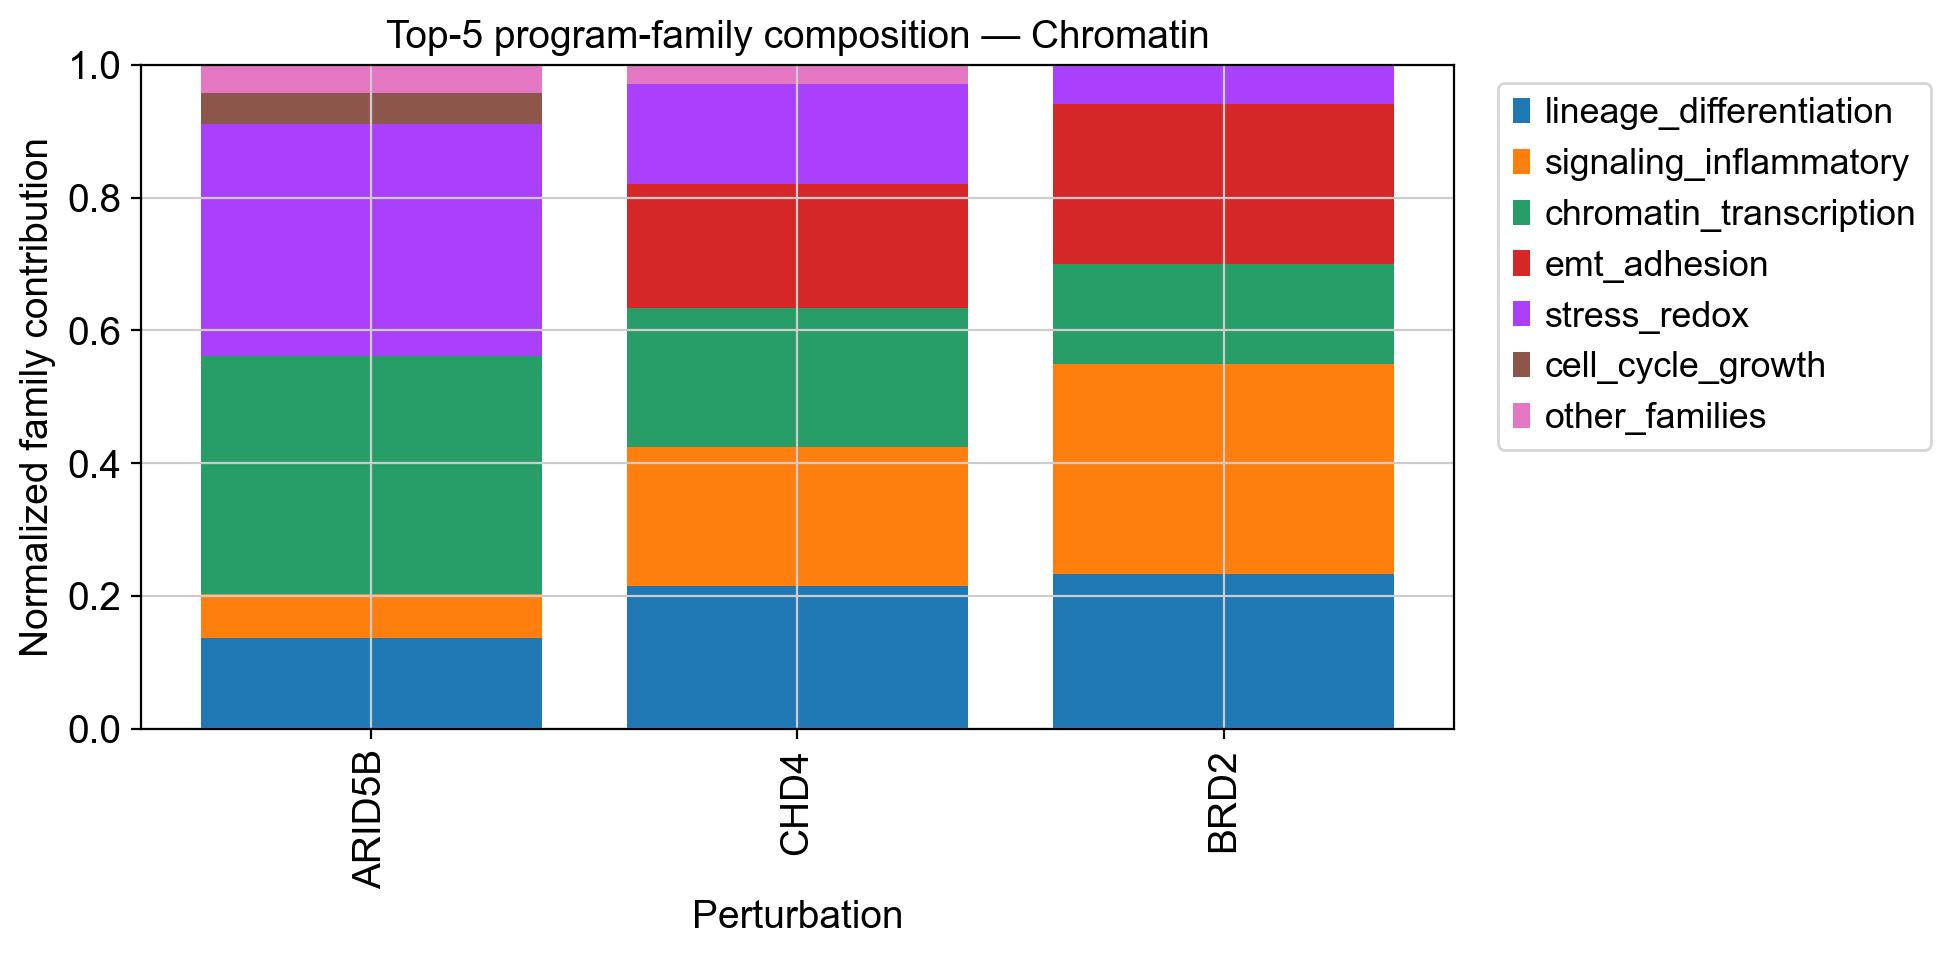

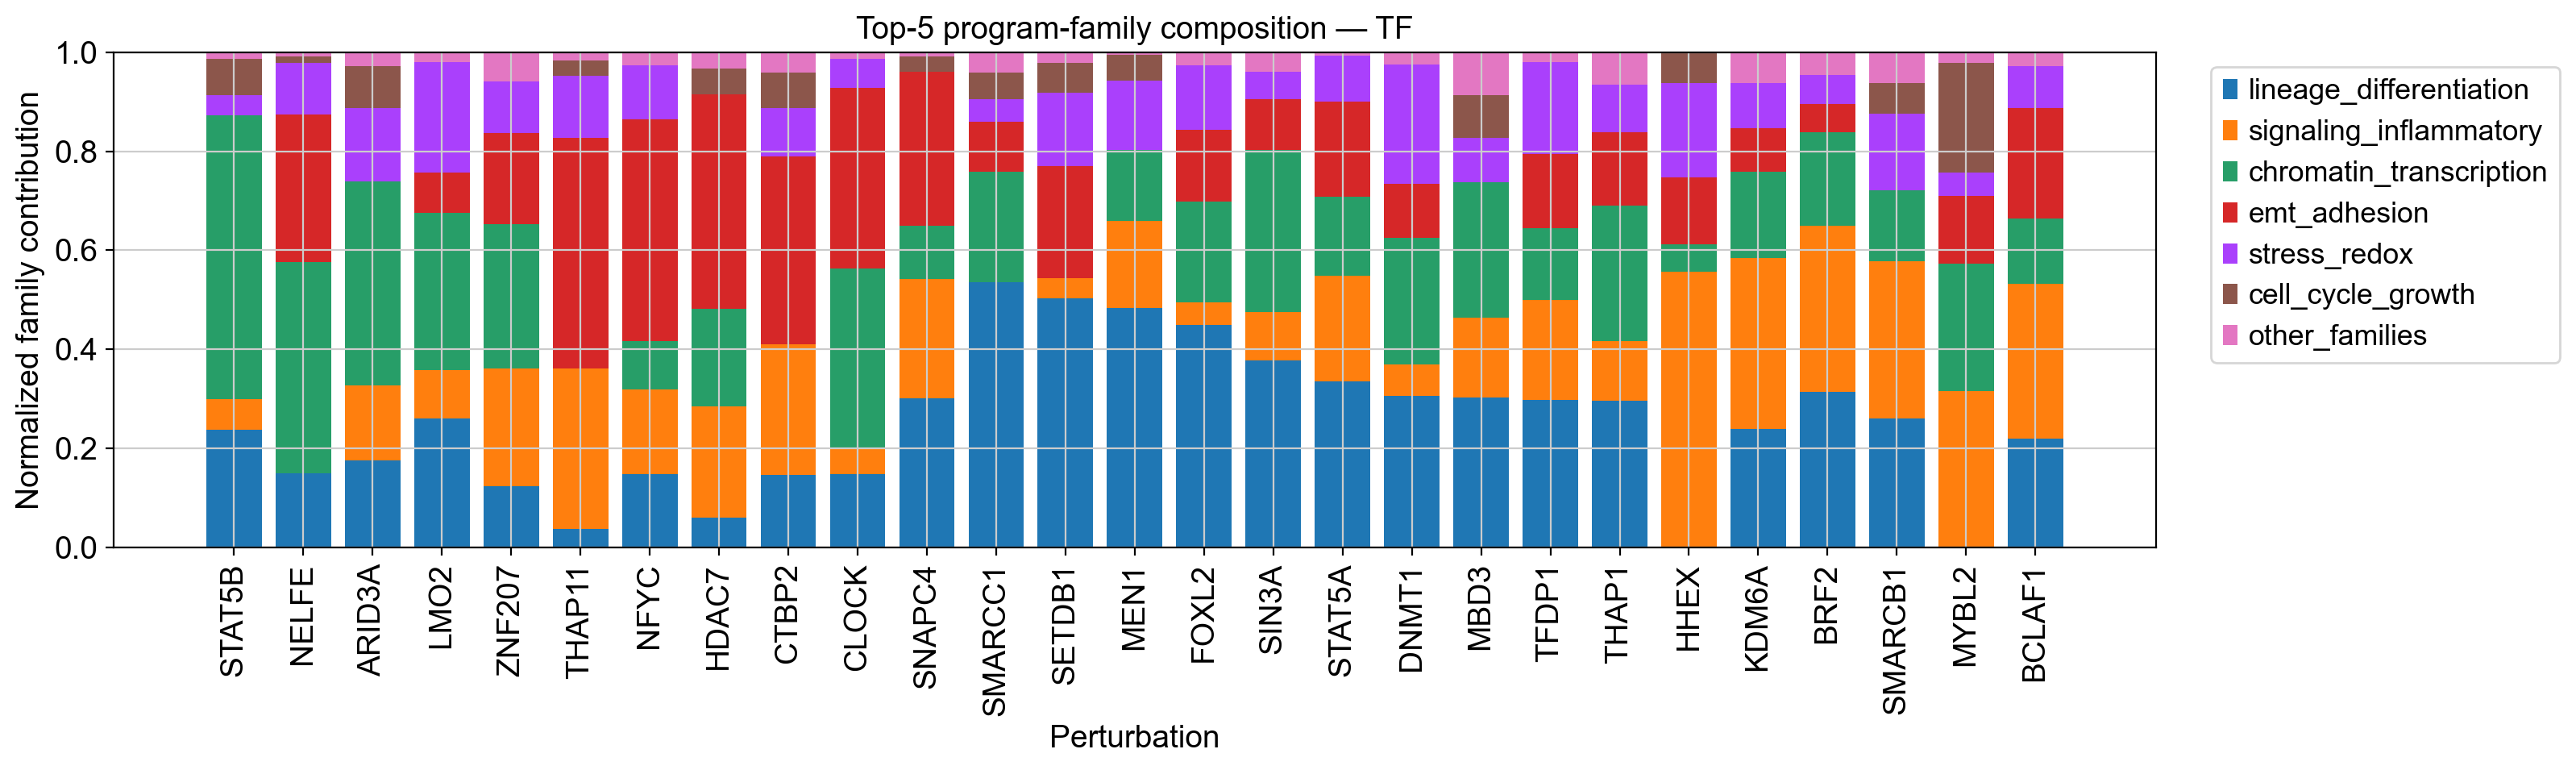

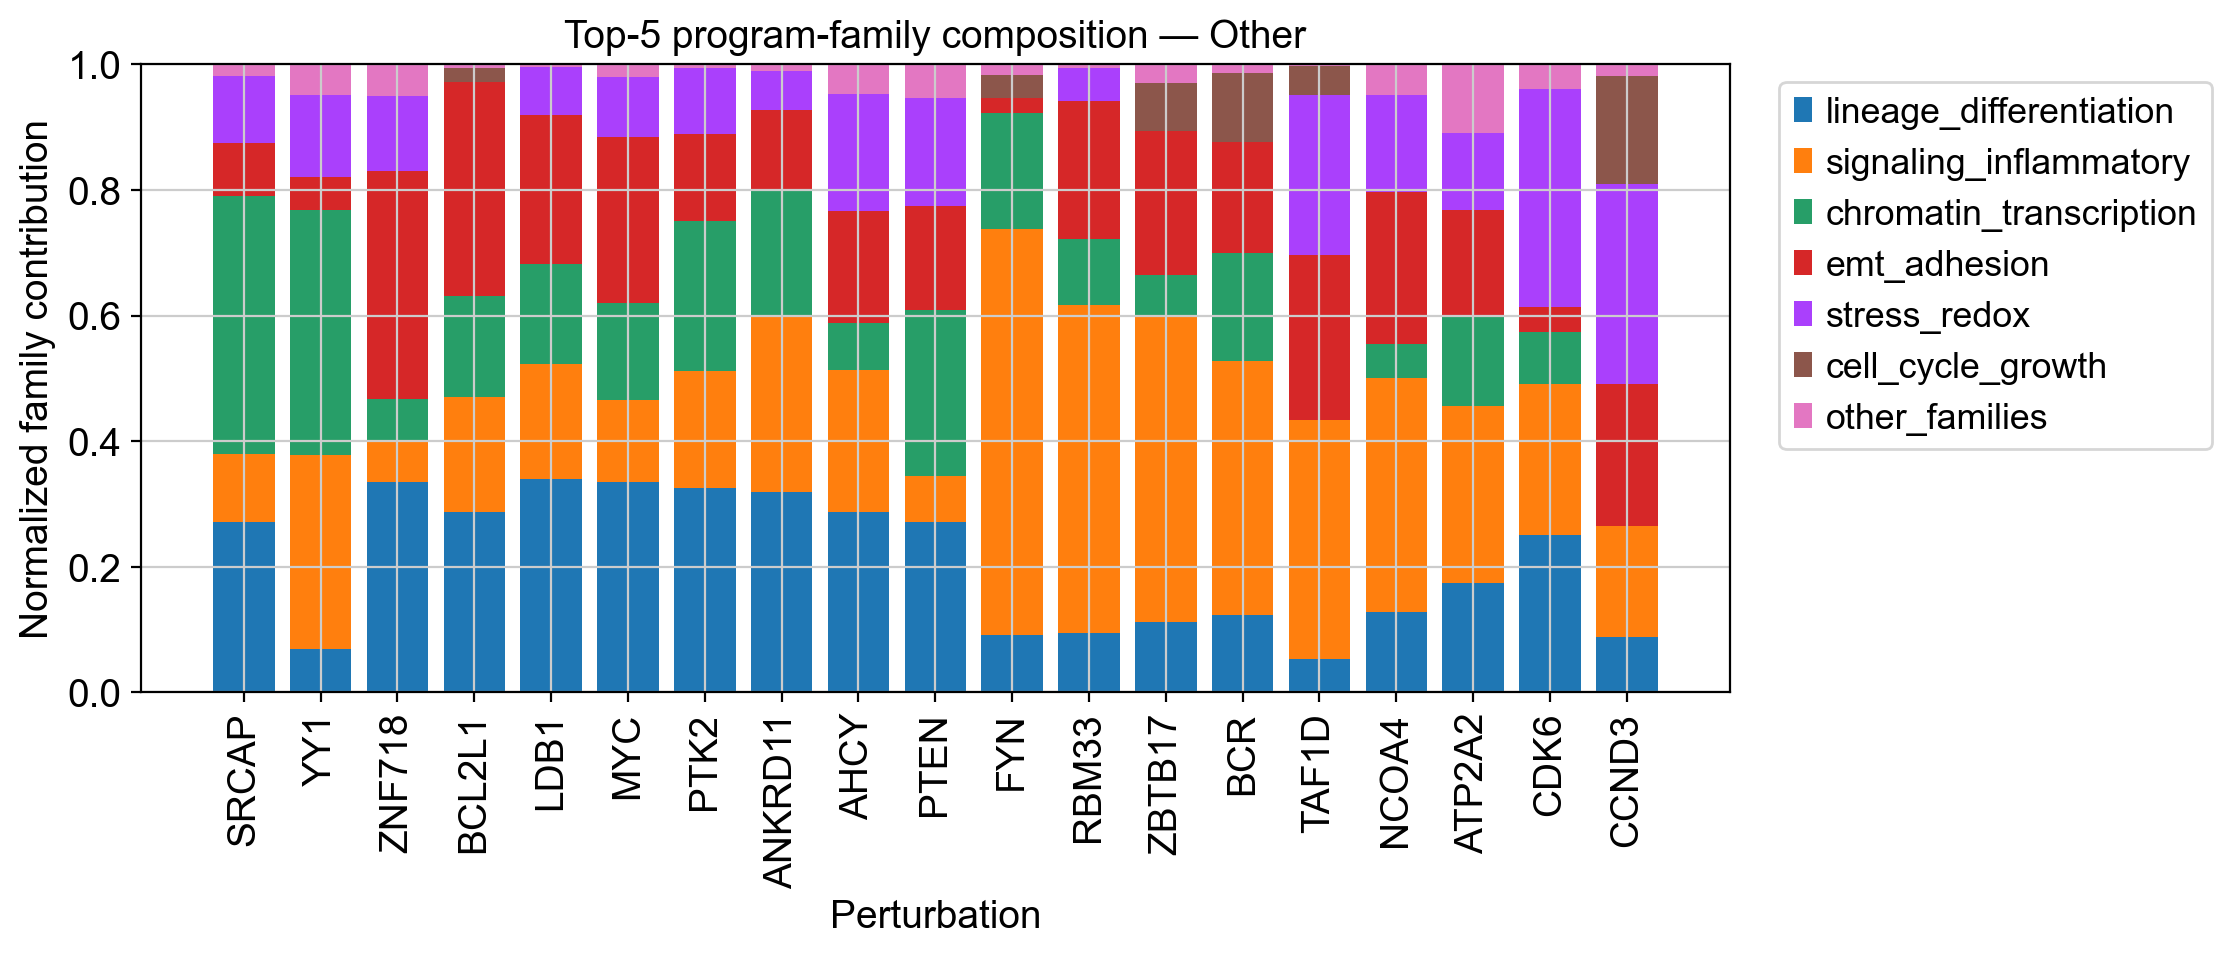

,lineage_differentiation,signaling_inflammatory,chromatin_transcription,emt_adhesion,stress_redox,other_families,perturbation,category,cell_cycle_growth,dominant_family,dominant_weight
0,0.136535,0.066468,0.358494,0.000000,0.349680,0.042658,ARID5B,Chromatin,0.046165,chromatin_transcription,0.358494
1,0.215856,0.209172,0.209064,0.186914,0.150170,0.028824,CHD4,Chromatin,0.000000,lineage_differentiation,0.215856
2,0.233386,0.316718,0.149708,0.240659,0.059492,0.000037,BRD2,Chromatin,0.000000,signaling_inflammatory,0.316718
3,0.237312,0.062489,0.572290,0.000000,0.041360,0.013938,STAT5B,TF,0.072611,chromatin_transcription,0.572290
4,0.148951,0.000000,0.427541,0.298121,0.104573,0.009224,NELFE,TF,0.011590,chromatin_transcription,0.427541


In [56]:
# === Plot program composition per perturbation class (stacked bars of top 5 families) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = [
    "REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS",
    "final_regulator_table",
]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing required object: {name}")

delta_family_mapped = REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS["delta_family_mapped"].copy()

# -------------------------------------------------
# 1. Category map
# -------------------------------------------------
perturbation_category_map = (
    final_regulator_table[["gene", "regulator_class"]]
    .drop_duplicates()
    .assign(
        category=lambda df: df["regulator_class"].map(
            lambda x: "TF" if x == "tf" else ("Chromatin" if x == "chromatin" else "Other")
        )
    )
    .set_index("gene")["category"]
)

perturbation_category_map = perturbation_category_map.loc[
    perturbation_category_map.index.intersection(delta_family_mapped.index.astype(str))
]

delta_family_mapped = delta_family_mapped.loc[perturbation_category_map.index]

# -------------------------------------------------
# 2. Convert each perturbation to normalized family composition
# -------------------------------------------------
abs_family = delta_family_mapped.abs().copy()
family_comp = abs_family.div(abs_family.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

family_comp["category"] = perturbation_category_map.loc[family_comp.index].values
family_comp["perturbation"] = family_comp.index.astype(str)

# -------------------------------------------------
# 3. Keep top 5 families per perturbation, collapse remainder
# -------------------------------------------------
family_cols = [c for c in family_comp.columns if c not in ["category", "perturbation"]]

top5_rows = []
for pert in family_comp.index:
    row = family_comp.loc[pert, family_cols].astype(float).sort_values(ascending=False)
    top5 = row.head(5)
    rest = float(row.iloc[5:].sum())

    out = top5.to_dict()
    out["other_families"] = rest
    out["perturbation"] = str(pert)
    out["category"] = family_comp.loc[pert, "category"]
    top5_rows.append(out)

top5_comp_df = pd.DataFrame(top5_rows).fillna(0.0)

# numeric columns only
plot_family_cols = [c for c in top5_comp_df.columns if c not in ["perturbation", "category"]]
top5_comp_df[plot_family_cols] = top5_comp_df[plot_family_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# stable order by overall mean contribution
plot_family_cols = (
    top5_comp_df[plot_family_cols]
    .mean(axis=0)
    .sort_values(ascending=False)
    .index.tolist()
)

# -------------------------------------------------
# 4. Sort perturbations within class
# -------------------------------------------------
top5_comp_df["dominant_family"] = top5_comp_df[plot_family_cols].idxmax(axis=1)
top5_comp_df["dominant_weight"] = top5_comp_df[plot_family_cols].max(axis=1)

category_order = ["Chromatin", "TF", "Other"]
top5_comp_df["category"] = pd.Categorical(
    top5_comp_df["category"],
    categories=category_order,
    ordered=True
)

top5_comp_df = top5_comp_df.sort_values(
    ["category", "dominant_family", "dominant_weight", "perturbation"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

# -------------------------------------------------
# 5. Plot one figure per category
# -------------------------------------------------
for cat in category_order:
    sub = top5_comp_df[top5_comp_df["category"] == cat].copy()
    if sub.empty:
        continue

    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))

    plt.figure(figsize=(max(10, 0.6 * len(sub)), 5))
    for fam in plot_family_cols:
        vals = sub[fam].astype(float).values
        plt.bar(x, vals, bottom=bottom, label=fam)
        bottom += vals

    plt.xticks(x, sub["perturbation"], rotation=90)
    plt.ylim(0, 1.0)
    plt.ylabel("Normalized family contribution")
    plt.xlabel("Perturbation")
    plt.title(f"Top-5 program-family composition — {cat}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# 6. Save tables
# -------------------------------------------------
REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS["top5_comp_df"] = top5_comp_df
REPLGLE_PROGRAM_LEVEL_MAPPED_ARTIFACTS["plot_family_cols"] = plot_family_cols

display(top5_comp_df.head())

### Section 7 — Cross-dataset reproducibility (Norman vs Replogle)

This section evaluates whether learned regulatory structure reproduces.

**Comparisons:**
- Concept axes (loading similarity)
- Perturbation fingerprints
- Concept selectivity
- Manifold geometry (principal angles)

**Findings:**
- Weak axis-level reproducibility:
  - Different TFs dominate each dataset
- Strong geometric reproducibility:
  - Low-dimensional structure preserved
  - Similar sparsity and compression

**Interpretation:**

Reproducibility is:
- ❌ Not at TF identity level
- ✅ At regulatory geometry level

Conclusion:
> MM-KPNN recovers **dataset-specific regulatory programs**
> but a **shared low-dimensional regulatory structure**

This refines the core claim:
- Interpretability is **architecture-driven**
- Biological content is **context-dependent**

In [57]:
# === Cross-dataset reproducibility: Norman ↔ Replogle ===
# Formal comparison of concept axes, response fingerprints, and concept selectivity

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path.home() / "Desktop" / "MM-KPNN"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# -------------------------------------------------
# 0. Replogle inputs from the current notebook state
# -------------------------------------------------
required_replogle = [
    "delta_fingerprints_final",
    "loadings_final_df",
    "concept_selectivity_final_df",
    "pca_var_final_df",
]
for name in required_replogle:
    if name not in globals():
        raise RuntimeError(f"Missing required Replogle object: {name}")

replogle_delta = delta_fingerprints_final.copy()
replogle_loadings = loadings_final_df.copy()
replogle_selectivity = concept_selectivity_final_df.copy()

print("Replogle inputs")
print(f"delta fingerprint matrix : {replogle_delta.shape}")
print(f"loading matrix           : {replogle_loadings.shape}")
print(f"selectivity table        : {replogle_selectivity.shape}")

# -------------------------------------------------
# 1. Load Norman perturbation artifacts
# -------------------------------------------------
norman_response_path = ARTIFACTS_DIR / "perturbseq_response_program_matrix.tsv"

if not norman_response_path.exists():
    raise FileNotFoundError(
        f"Missing Norman artifact: {norman_response_path}\n"
        "Run the Norman perturbation notebook through the response-matrix stage first."
    )

norman_delta = pd.read_csv(norman_response_path, sep="\t", index_col=0)
norman_delta.index = norman_delta.index.astype(str)
norman_delta.columns = norman_delta.columns.astype(str)

print("\nNorman inputs")
print(f"delta fingerprint matrix : {norman_delta.shape}")

# -------------------------------------------------
# 2. Recompute Norman PCA/loadings in the same style as Replogle
# -------------------------------------------------
norman_pca = PCA(
    n_components=min(10, norman_delta.shape[0], norman_delta.shape[1]),
    random_state=42
)
norman_scores = norman_pca.fit_transform(norman_delta.values)

norman_pca_var_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(norman_pca.explained_variance_ratio_))],
    "explained_variance_ratio": norman_pca.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(norman_pca.explained_variance_ratio_)
})

norman_loadings_df = pd.DataFrame(
    norman_pca.components_.T,
    index=norman_delta.columns.astype(str),
    columns=[f"PC{i+1}" for i in range(norman_pca.components_.shape[0])]
)

# -------------------------------------------------
# 3. Recompute Norman concept selectivity in the same metric as Replogle
#    selectivity = max(abs mean shift across perturbations) / mean(abs mean shift)
# -------------------------------------------------
eps = 1e-8
norman_selectivity_series = (
    norman_delta.abs().max(axis=0) /
    (norman_delta.abs().mean(axis=0) + eps)
).sort_values(ascending=False)

norman_selectivity_df = pd.DataFrame({
    "concept": norman_selectivity_series.index,
    "selectivity_score": norman_selectivity_series.values
})

# -------------------------------------------------
# 4. Shared concept universe
# -------------------------------------------------
shared_concepts = sorted(
    set(norman_delta.columns.astype(str)).intersection(set(replogle_delta.columns.astype(str)))
)

if len(shared_concepts) == 0:
    raise RuntimeError("No shared concepts found between Norman and Replogle.")

print("\nShared concept universe")
print(f"shared concepts : {len(shared_concepts)}")

# restrict to shared concepts for fair comparison
norman_delta_shared = norman_delta.loc[:, shared_concepts].copy()
replogle_delta_shared = replogle_delta.loc[:, shared_concepts].copy()

norman_loadings_shared = norman_loadings_df.loc[shared_concepts].copy()
replogle_loadings_shared = replogle_loadings.loc[shared_concepts].copy()

# -------------------------------------------------
# 5. Concept-axis reproducibility
#    For PC1-PC3:
#    - Spearman correlation across shared concept loadings
#    - overlap among top positive / negative concepts
# -------------------------------------------------
def top_overlap(series_a, series_b, k=10, direction="positive"):
    if direction == "positive":
        top_a = set(series_a.sort_values(ascending=False).head(k).index)
        top_b = set(series_b.sort_values(ascending=False).head(k).index)
    else:
        top_a = set(series_a.sort_values(ascending=True).head(k).index)
        top_b = set(series_b.sort_values(ascending=True).head(k).index)
    return top_a, top_b, sorted(top_a & top_b)

axis_rows = []
axis_overlap_rows = []

for pc in ["PC1", "PC2", "PC3"]:
    n_vec = norman_loadings_shared[pc]
    r_vec = replogle_loadings_shared[pc]

    rho_signed, p_signed = spearmanr(n_vec, r_vec)
    rho_abs, p_abs = spearmanr(np.abs(n_vec), np.abs(r_vec))

    pos_a, pos_b, pos_overlap = top_overlap(n_vec, r_vec, k=10, direction="positive")
    neg_a, neg_b, neg_overlap = top_overlap(n_vec, r_vec, k=10, direction="negative")

    axis_rows.append({
        "PC": pc,
        "spearman_signed": rho_signed,
        "p_signed": p_signed,
        "spearman_abs": rho_abs,
        "p_abs": p_abs,
        "positive_top10_overlap_n": len(pos_overlap),
        "negative_top10_overlap_n": len(neg_overlap),
        "positive_top10_overlap": ", ".join(pos_overlap),
        "negative_top10_overlap": ", ".join(neg_overlap),
    })

    axis_overlap_rows.append({
        "PC": pc,
        "norman_top_positive": norman_loadings_shared[pc].sort_values(ascending=False).head(10).index.tolist(),
        "replogle_top_positive": replogle_loadings_shared[pc].sort_values(ascending=False).head(10).index.tolist(),
        "norman_top_negative": norman_loadings_shared[pc].sort_values(ascending=True).head(10).index.tolist(),
        "replogle_top_negative": replogle_loadings_shared[pc].sort_values(ascending=True).head(10).index.tolist(),
    })

axis_repro_df = pd.DataFrame(axis_rows)
axis_overlap_df = pd.DataFrame(axis_overlap_rows)

print("\nConcept-axis reproducibility")
display(axis_repro_df)

print("\nAxis loading summaries")
display(axis_overlap_df)

# -------------------------------------------------
# 6. Response-manifold similarity
#    A. exact shared perturbation names across datasets
#    B. recurrent concept programs across perturbations
# -------------------------------------------------
shared_perturbations = sorted(
    set(norman_delta_shared.index.astype(str)).intersection(set(replogle_delta_shared.index.astype(str)))
)

if len(shared_perturbations) > 0:
    exact_similarity = pd.DataFrame({
        "perturbation": shared_perturbations,
        "cosine_similarity": [
            float(
                cosine_similarity(
                    norman_delta_shared.loc[[p]].values,
                    replogle_delta_shared.loc[[p]].values
                )[0, 0]
            )
            for p in shared_perturbations
        ],
        "pearson_correlation": [
            float(pd.Series(norman_delta_shared.loc[p]).corr(pd.Series(replogle_delta_shared.loc[p])))
            for p in shared_perturbations
        ],
    }).sort_values("cosine_similarity", ascending=False)
else:
    exact_similarity = pd.DataFrame(columns=["perturbation", "cosine_similarity", "pearson_correlation"])

print("\nExact shared perturbations across datasets")
print(f"n_shared_perturbations : {len(shared_perturbations)}")
if len(shared_perturbations) > 0:
    display(exact_similarity)
else:
    print("No exact shared perturbation names found.")

# recurrent response programs
def recurrent_concepts(delta_df, topk=10):
    counts = {}
    for pert in delta_df.index:
        top = delta_df.loc[pert].abs().sort_values(ascending=False).head(topk).index.tolist()
        for c in top:
            counts[c] = counts.get(c, 0) + 1
    out = (
        pd.Series(counts, name="topk_recurrence")
        .sort_values(ascending=False)
        .to_frame()
        .reset_index()
        .rename(columns={"index": "concept"})
    )
    return out

norman_recurrent_df = recurrent_concepts(norman_delta_shared, topk=10)
replogle_recurrent_df = recurrent_concepts(replogle_delta_shared, topk=10)

recurrent_merge = (
    norman_recurrent_df.merge(
        replogle_recurrent_df,
        on="concept",
        how="outer",
        suffixes=("_norman", "_replogle")
    )
    .fillna(0)
)

recurrent_merge["mean_recurrence"] = (
    recurrent_merge["topk_recurrence_norman"] + recurrent_merge["topk_recurrence_replogle"]
) / 2.0

recurrent_merge["abs_recurrence_gap"] = np.abs(
    recurrent_merge["topk_recurrence_norman"] - recurrent_merge["topk_recurrence_replogle"]
)

recurrent_rank_df = recurrent_merge.sort_values(
    ["mean_recurrence", "abs_recurrence_gap"],
    ascending=[False, True]
)

top20_norman_recurrent = set(norman_recurrent_df.head(20)["concept"])
top20_replogle_recurrent = set(replogle_recurrent_df.head(20)["concept"])
top20_recurrent_overlap = sorted(top20_norman_recurrent & top20_replogle_recurrent)

print("\nRecurrent response-program comparison")
print(f"top20 overlap : {len(top20_recurrent_overlap)}")
print("overlap concepts:", top20_recurrent_overlap)

print("\nTop recurrent concepts across datasets")
display(recurrent_rank_df.head(30))

# -------------------------------------------------
# 7. Concept selectivity consistency
# -------------------------------------------------
norman_sel = norman_selectivity_df.copy()
replogle_sel = replogle_selectivity.copy()

selectivity_merge = (
    norman_sel.merge(replogle_sel, on="concept", how="inner", suffixes=("_norman", "_replogle"))
    .sort_values("concept")
)

rho_selectivity, p_selectivity = spearmanr(
    selectivity_merge["selectivity_score_norman"],
    selectivity_merge["selectivity_score_replogle"]
)

top25_norman_sel = set(norman_sel.head(25)["concept"])
top25_replogle_sel = set(replogle_sel.head(25)["concept"])
top25_selectivity_overlap = sorted(top25_norman_sel & top25_replogle_sel)

print("\nConcept selectivity consistency")
print(f"shared concepts compared      : {selectivity_merge.shape[0]}")
print(f"spearman rho                 : {rho_selectivity:.4f}")
print(f"p-value                      : {p_selectivity:.4e}")
print(f"top25 overlap                : {len(top25_selectivity_overlap)}")
print("top25 overlap concepts      :", top25_selectivity_overlap)

print("\nTop selective concepts in both datasets")
display(
    selectivity_merge.assign(
        rank_norman=selectivity_merge["selectivity_score_norman"].rank(ascending=False, method="min"),
        rank_replogle=selectivity_merge["selectivity_score_replogle"].rank(ascending=False, method="min"),
        mean_rank=(selectivity_merge["selectivity_score_norman"].rank(ascending=False, method="min") +
                   selectivity_merge["selectivity_score_replogle"].rank(ascending=False, method="min")) / 2.0
    )
    .sort_values("mean_rank")
    .head(30)
)

# -------------------------------------------------
# 8. Summary table
# -------------------------------------------------
summary_rows = [
    {
        "analysis": "Norman manifold",
        "result": ", ".join(
            f"{row.PC}={row.explained_variance_ratio:.3f}"
            for _, row in norman_pca_var_df.head(5).iterrows()
        ),
    },
    {
        "analysis": "Replogle manifold",
        "result": ", ".join(
            f"{row.PC}={row.explained_variance_ratio:.3f}"
            for _, row in pca_var_final_df.head(5).iterrows()
        ),
    },
    {
        "analysis": "Axis reproducibility (PC1-PC3 abs rho)",
        "result": "; ".join(
            f"{row.PC}: rho={row.spearman_abs:.3f}"
            for _, row in axis_repro_df.iterrows()
        ),
    },
    {
        "analysis": "Top20 recurrent concept overlap",
        "result": f"{len(top20_recurrent_overlap)} concepts",
    },
    {
        "analysis": "Selectivity consistency",
        "result": f"rho={rho_selectivity:.3f}, top25 overlap={len(top25_selectivity_overlap)}",
    },
    {
        "analysis": "Exact shared perturbations",
        "result": f"{len(shared_perturbations)} shared labels",
    },
]

cross_dataset_summary_df = pd.DataFrame(summary_rows)

print("\nCross-dataset reproducibility summary")
display(cross_dataset_summary_df)

# -------------------------------------------------
# 9. Save outputs
# -------------------------------------------------
cross_axis_path = ARTIFACTS_DIR / "cross_dataset_axis_reproducibility.tsv"
cross_overlap_path = ARTIFACTS_DIR / "cross_dataset_axis_overlap_details.tsv"
cross_exact_path = ARTIFACTS_DIR / "cross_dataset_exact_shared_perturbations.tsv"
cross_recurrent_path = ARTIFACTS_DIR / "cross_dataset_recurrent_concepts.tsv"
cross_selectivity_path = ARTIFACTS_DIR / "cross_dataset_selectivity_consistency.tsv"
cross_summary_path = ARTIFACTS_DIR / "cross_dataset_reproducibility_summary.tsv"

axis_repro_df.to_csv(cross_axis_path, sep="\t", index=False)
axis_overlap_df.to_csv(cross_overlap_path, sep="\t", index=False)
exact_similarity.to_csv(cross_exact_path, sep="\t", index=False)
recurrent_rank_df.to_csv(cross_recurrent_path, sep="\t", index=False)
selectivity_merge.to_csv(cross_selectivity_path, sep="\t", index=False)
cross_dataset_summary_df.to_csv(cross_summary_path, sep="\t", index=False)

print("\nSaved cross-dataset artifacts")
print(cross_axis_path)
print(cross_overlap_path)
print(cross_exact_path)
print(cross_recurrent_path)
print(cross_selectivity_path)
print(cross_summary_path)

Replogle inputs
delta fingerprint matrix : (49, 312)
loading matrix           : (312, 10)
selectivity table        : (312, 2)

Norman inputs
delta fingerprint matrix : (105, 315)

Shared concept universe
shared concepts : 312

Concept-axis reproducibility


,PC,spearman_signed,p_signed,spearman_abs,p_abs,positive_top10_overlap_n,negative_top10_overlap_n,positive_top10_overlap,negative_top10_overlap
0,PC1,-0.014809,0.794447,0.050925,0.369992,2,0,"PAX6, PROX1",
1,PC2,-0.071223,0.209623,0.019255,0.734781,0,0,,
2,PC3,-0.026873,0.636313,0.061057,0.282307,0,0,,



Axis loading summaries


,PC,norman_top_positive,replogle_top_positive,norman_top_negative,replogle_top_negative
0,PC1,"[PAX6, GATA6, ZNF217, CREB3, KLF5, ZNF83, ATF7...","[PAX6, ZEB2, RELB, CHD2, PPARG, ONECUT1, TP73,...","[CDX2, E2F7, NR1H2, BACH1, HDAC2, NEUROD1, IRF...","[ZBED1, ETV4, FOXJ2, TRIM28, LEF1, EPAS1, ZNF2..."
1,PC2,"[BACH1, HDAC2, ARID2, BRCA1, E2F7, BRF2, CREB3...","[SMARCA4, PAX6, ZBED1, NR1H2, CEBPZ, EZH2, ZHX...","[NEUROD1, CCNT2, CUX1, PTTG1, BDP1, MYBL2, PBX...","[PPARG, MAF, ZEB2, SOX9, PRDM1, NFE2L1, RELB, ..."
2,PC3,"[HDAC2, BRCA1, MBD2, THAP1, CDX2, ZC3H8, NR1H3...","[PAX6, SMAD1, ESRRA, MAZ, GRHL2, TP73, ZNF143,...","[BACH1, ZNF589, ZHX1, PTTG1, SMAD1, TCF3, CCNT...","[RELB, PPARG, CEBPZ, SMARCA4, ONECUT1, ETV4, Z..."



Exact shared perturbations across datasets
n_shared_perturbations : 1


...


Concept selectivity consistency
shared concepts compared      : 312
spearman rho                 : 0.1541
p-value                      : 6.3728e-03
top25 overlap                : 0
top25 overlap concepts      : []

Top selective concepts in both datasets


,concept,selectivity_score_norman,selectivity_score_replogle,rank_norman,rank_replogle,mean_rank
28,ATF7,13.297979,20.261831,29.0,12.0,20.5
45,KLF5,10.148445,48.992405,46.0,1.0,23.5
26,E2F3,13.464411,15.156643,27.0,20.0,23.5
16,NFE2L1,19.924914,8.901250,17.0,32.0,24.5
3,BRF1,74.450739,6.951696,4.0,46.0,25.0
51,CUX1,9.380778,41.450691,52.0,6.0,29.0
50,TEAD2,9.548456,21.075653,51.0,10.0,30.5
7,PML,28.467707,6.019719,8.0,59.0,33.5
20,HOXA1,16.597142,6.408900,21.0,53.0,37.0
24,MAZ,14.854314,6.554364,25.0,51.0,38.0



Cross-dataset reproducibility summary


,analysis,result
0,Norman manifold,"PC1=0.304, PC2=0.157, PC3=0.111, PC4=0.100, PC..."
1,Replogle manifold,"PC1=0.253, PC2=0.174, PC3=0.103, PC4=0.071, PC..."
2,Axis reproducibility (PC1-PC3 abs rho),PC1: rho=0.051; PC2: rho=0.019; PC3: rho=0.061
3,Top20 recurrent concept overlap,1 concepts
4,Selectivity consistency,"rho=0.154, top25 overlap=0"
5,Exact shared perturbations,1 shared labels



Saved cross-dataset artifacts
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_axis_reproducibility.tsv
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_axis_overlap_details.tsv
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_exact_shared_perturbations.tsv
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_recurrent_concepts.tsv
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_selectivity_consistency.tsv
/Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_reproducibility_summary.tsv


In [58]:
# ============================================================
# Cross-dataset manifold comparison using principal angles
# ============================================================

import numpy as np
import pandas as pd
from scipy.linalg import svd
from sklearn.decomposition import PCA

# Norman and Replogle matrices restricted to shared concepts
Xn = norman_delta_shared.values
Xr = replogle_delta_shared.values

# PCA projection
n_components = 10

pca_n = PCA(n_components=n_components, random_state=42)
pca_r = PCA(n_components=n_components, random_state=42)

Un = pca_n.fit(Xn).components_.T
Ur = pca_r.fit(Xr).components_.T

# compute principal angles
M = Un.T @ Ur
U, s, Vt = svd(M)

principal_angles = np.arccos(np.clip(s, -1, 1))
principal_angles_deg = np.degrees(principal_angles)

angles_df = pd.DataFrame({
    "dimension": np.arange(1, len(principal_angles_deg)+1),
    "principal_angle_deg": principal_angles_deg
})

print("Principal angles between Norman and Replogle manifolds")
display(angles_df)

print("\nMean principal angle:", principal_angles_deg.mean())

Principal angles between Norman and Replogle manifolds


,dimension,principal_angle_deg
0,1,51.636418
1,2,62.472778
2,3,77.048018
3,4,82.395818
4,5,84.857635
5,6,86.024147
6,7,86.642637
7,8,87.619834
8,9,89.267628
9,10,89.789739



Mean principal angle: 79.77546513732693


In [59]:
display(group_concept_summary)
display(filtered_top1_group_summary)
display(cumulative_coverage_summary)
display(summary)  # mechanistic verdict summary
display(program_family_group_mapped_summary)
display(family_coverage_mapped_summary)
display(family_assignment_mapped_summary)

,n_perturbations,activation_magnitude_mean,activation_magnitude_median,concept_sparsity_mean,concept_sparsity_median,concept_selectivity_mean,concept_selectivity_median
category,,,,,,,
Chromatin,3,0.236618,0.223979,0.805556,0.817308,16.543991,16.878090
Other,19,0.167336,0.165969,0.780027,0.778846,15.660168,13.370031
TF,27,0.211682,0.156988,0.761871,0.762821,14.262544,13.789671


,n_perturbations,n_top_genes_after_filter_mean,n_active_program_genes_after_filter_mean,overlap_frac_mean,null_mean,enrichment_mean,zscore_mean
category,,,,,,,
Chromatin,3,35.000000,244.333333,0.209524,0.040948,5.486214,5.230879
Other,19,32.631579,281.789474,0.208188,0.046991,4.549837,4.372892
TF,27,32.888889,274.222222,0.213280,0.045866,4.966155,4.748105


n_perturbations  n_top_genes_after_filter_mean  \
topk_concepts category                                                    
1             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
3             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
5             Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   
10            Chromatin                3                      35.000000   
              Other                   19                      32.631579   
              TF                      27                      32.888889   

                         n_active_program_genes_after_filter_mean  \
topk_concepts category                                              
1             Chromatin                                244.333333   
              Other                                    281.789474   
              TF                                       274.222222   
3             Chromatin                                677.333333   
              Other                                    683.210526   
              TF                                       680.629630   
5             Chromatin                                997.000000   
              Other                                    999.000000   
              TF                                       982.222222   
10            Chromatin                               1592.666667   
              Other                                   1536.263158   
              TF                                      1508.148148   

                         coverage_frac_mean  coverage_frac_median  
topk_concepts category                                             
1             Chromatin            0.209524              0.171429  
              Other                0.208188              0.181818  
              TF                   0.213280              0.176471  
3             Chromatin            0.590476              0.657143  
              Other                0.496498              0.515152  
              TF                   0.467415              0.484848  
5             Chromatin            0.704762              0.685714  
              Other                0.607055              0.633333  
              TF                   0.591126              0.612903  
10            Chromatin            0.790476              0.828571  
              Other                0.738129              0.763158  
              TF                   0.749079              0.735294

{'top_positive': ['ETV4',
  'PAX6',
  'PPARG',
  'ZBTB11',
  'HOXA9',
  'PRDM1',
  'TP73',
  'LEF1',
  'AHR',
  'ETV1'],
 'top_negative': ['RELB',
  'ZEB2',
  'CHD2',
  'MAZ',
  'SOX13',
  'GRHL2',
  'NCOA1',
  'ONECUT1',
  'BHLHE22',
  'SMARCA4']}

,n_perturbations,family_activation_magnitude_mean,family_n_active_rel25_mean,family_active_frac_rel25_mean,family_selectivity_mean,family_entropy_mean,family_dominance_mean
category,,,,,,,
Chromatin,3,5.154200,5.000000,0.833333,1.595461,2.369210,0.265910
Other,19,3.579100,4.947368,0.824561,1.797120,2.350741,0.299520
TF,27,4.285628,4.888889,0.814815,1.688926,2.348680,0.281488


n_perturbations  \
topk_families category                     
1             Chromatin                3   
              Other                   19   
              TF                      27   
2             Chromatin                3   
              Other                   19   
              TF                      27   
3             Chromatin                3   
              Other                   19   
              TF                      27   
5             Chromatin                3   
              Other                   19   
              TF                      27   

                         n_active_family_genes_after_filter_mean  \
topk_families category                                             
1             Chromatin                              1854.666667   
              Other                                  1640.947368   
              TF                                     1784.555556   
2             Chromatin                              2407.333333   
              Other                                  2466.894737   
              TF                                     2638.703704   
3             Chromatin                              3178.333333   
              Other                                  2974.526316   
              TF                                     3124.740741   
5             Chromatin                              3828.666667   
              Other                                  3788.947368   
              TF                                     3750.111111   

                         coverage_frac_mean  coverage_frac_median  
topk_families category                                             
1             Chromatin            0.571429              0.514286  
              Other                0.544838              0.516129  
              TF                   0.585640              0.558824  
2             Chromatin            0.685714              0.657143  
              Other                0.714364              0.687500  
              TF                   0.760364              0.794118  
3             Chromatin            0.828571              0.828571  
              Other                0.814887              0.806452  
              TF                   0.836972              0.875000  
5             Chromatin            0.942857              0.942857  
              Other                0.935747              0.967742  
              TF                   0.937197              0.966667

,unique_frac,ambiguous_frac,unassigned_frac
category,,,
Chromatin,0.352381,0.476190,0.171429
Other,0.273059,0.541828,0.185113
TF,0.287851,0.549122,0.163028


### Summary

This notebook shows that MM-KPNN captures structured perturbation responses in Replogle, but mechanistic support is uneven across perturbations.

**Main findings**
- concept-space organization is preserved despite perturbation heterogeneity
- concept-level interpretability varies within, not just across, regulator classes
- stringent overlap analyses retain a subset of high-confidence mechanistic cases
- program-level abstraction improves interpretability for some perturbations, but does not eliminate heterogeneity

**Take-home message**
In Replogle, interpretability is perturbation-specific and heterogeneous rather than cleanly class-driven.


### Section 8 — Consistency checks and manuscript exports

The final cells perform lightweight checks and export the exact tables used for cross-dataset synthesis and figure generation.

**Expected outputs**
- Replogle synthesis table for cross-dataset comparison
- descriptive summaries of concept selectivity and gene-level support
- exact Figure 4 input tables saved to the project artifacts directory


In [60]:
# === Replogle prerequisite check for Section 5.2 / 5.3 ===

required = [
    "REPLGLE_MECHANISTIC_CASEBOOK",
    "delta_fingerprints_final",
    "perturbation_top_attributions_df",
    "concept_selectivity_final_df",
    "REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS",
    "FILTERED_TOP1_OVERLAP_ARTIFACTS",
    "CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS",
    "REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE",
    "REPLGLE_MECHANISTIC_EVALUATION",
]

for name in required:
    print(f"{name}: {'FOUND' if name in globals() else 'MISSING'}")

REPLGLE_MECHANISTIC_CASEBOOK: FOUND
delta_fingerprints_final: FOUND
perturbation_top_attributions_df: FOUND
concept_selectivity_final_df: FOUND
REPLOGLE_STRATIFIED_CONCEPT_ARTIFACTS: FOUND
FILTERED_TOP1_OVERLAP_ARTIFACTS: FOUND
CUMULATIVE_MECHANISTIC_COVERAGE_ARTIFACTS: FOUND
REPLGLE_MECHANISTIC_EXPECTATION_TEMPLATE: FOUND
REPLGLE_MECHANISTIC_EVALUATION: FOUND


In [61]:
# === Export Replogle cross-dataset synthesis table ===

from pathlib import Path
import pandas as pd

if "REPLGLE_MECHANISTIC_EVALUATION" not in globals():
    raise RuntimeError(
        "REPLGLE_MECHANISTIC_EVALUATION not found.\n"
        "Run: '# === Section 5.3 — Assign mechanistic verdicts (metric-based) ==='"
    )

PROJECT_DIR = Path("/Users/sally/Desktop/MM-KPNN")
SYNTHESIS_DIR = PROJECT_DIR / "artifacts" / "cross_dataset_synthesis"
SYNTHESIS_DIR.mkdir(parents=True, exist_ok=True)

replogle_synthesis_df = REPLGLE_MECHANISTIC_EVALUATION.copy()

replogle_synthesis_df = replogle_synthesis_df.rename(columns={
    "perturbation": "entity",
    "top1_active_concept": "concept",
    "top1_strict_driver_overlap_frac": "overlap_fraction_topk",
    "mechanistic_verdict": "activation_class",
})

replogle_synthesis_df["dataset"] = "Replogle"

# This field is not produced in Replogle Section 5.2 / 5.3
replogle_synthesis_df["delta_activation_vs_control"] = pd.NA

def concordance_class(x):
    if pd.isna(x):
        return pd.NA
    if x >= 0.40:
        return "strong"
    if x >= 0.20:
        return "moderate"
    return "weak"

replogle_synthesis_df["concordance_class"] = (
    replogle_synthesis_df["overlap_fraction_topk"].apply(concordance_class)
)

replogle_synthesis_df = replogle_synthesis_df[[
    "dataset",
    "entity",
    "concept",
    "delta_activation_vs_control",
    "concept_selectivity",
    "overlap_fraction_topk",
    "activation_class",
    "concordance_class",
]]

replogle_synthesis_path = SYNTHESIS_DIR / "replogle_synthesis_table.tsv"
replogle_synthesis_df.to_csv(replogle_synthesis_path, sep="\t", index=False)

print("Saved:", replogle_synthesis_path)
display(replogle_synthesis_df.head())

Saved: /Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_synthesis/replogle_synthesis_table.tsv


,dataset,entity,concept,delta_activation_vs_control,concept_selectivity,overlap_fraction_topk,activation_class,concordance_class
0,Replogle,MYBL2,ZBTB11,<NA>,11.266799,0.029412,weak_or_non_mechanistic,weak
1,Replogle,CLOCK,SMARCA4,<NA>,36.624893,0.333333,strong_mechanistic,moderate
2,Replogle,LMO2,ETV4,<NA>,12.886209,0.166667,strong_mechanistic,weak
3,Replogle,KDM6A,ESRRA,<NA>,9.938190,0.157895,moderate_mechanistic,weak
4,Replogle,HHEX,PAX6,<NA>,11.448058,0.352941,moderate_mechanistic,moderate


In [62]:
replogle_synthesis_df[["concept_selectivity", "overlap_fraction_topk"]].describe()

,concept_selectivity,overlap_fraction_topk
count,12.000000,12.000000
mean,15.329085,0.179604
std,7.145524,0.105913
min,9.938190,0.029412
25%,11.402743,0.116807
50%,13.462369,0.154705
75%,15.031411,0.211905
max,36.624893,0.352941


In [66]:
# === Replogle dataset → export EXACT Figure 4 inputs ===

from pathlib import Path
import pandas as pd

BASE = Path("/Users/sally/Desktop/MM-KPNN")
OUTDIR = BASE / "artifacts" / "paper_figures" / "figure4_inputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Required existing tables
# -----------------------------
if "perturbation_concept_metrics" not in globals():
    raise RuntimeError("perturbation_concept_metrics not found")

if "final_regulator_table" not in globals():
    raise RuntimeError("final_regulator_table not found")

if "replogle_synthesis_df" not in globals():
    raise RuntimeError("replogle_synthesis_df not found")

pert_df = perturbation_concept_metrics.copy()
class_df = final_regulator_table.copy()
synth_df = replogle_synthesis_df.copy()

# -----------------------------
# Keep only fields needed for Figure 4
# -----------------------------
# perturbation-level metrics
needed_metric_cols = [
    c for c in pert_df.columns
    if c in [
        "perturbation",
        "gene",
        "concept",
        "concept_selectivity",
        "overlap_fraction_topk",
        "mechanistic_score",
        "mechanistic_verdict",
        "top_concept",
        "best_concept",
    ]
]

if len(needed_metric_cols) == 0:
    raise RuntimeError(f"Could not find expected metric columns in perturbation_concept_metrics: {list(pert_df.columns)}")

figure4_metrics_df = pert_df[needed_metric_cols].copy()

# class/category labels
needed_class_cols = [
    c for c in class_df.columns
    if c in ["gene", "perturbation", "regulator_class", "category", "is_direct_tf"]
]

if len(needed_class_cols) == 0:
    raise RuntimeError(f"Could not find expected class columns in final_regulator_table: {list(class_df.columns)}")

figure4_classes_df = class_df[needed_class_cols].copy()

# synthesis table
figure4_synthesis_df = synth_df.copy()

# -----------------------------
# Save
# -----------------------------
figure4_metrics_df.to_csv(OUTDIR / "figure4_metrics.tsv", sep="\t", index=False)
figure4_classes_df.to_csv(OUTDIR / "figure4_classes.tsv", sep="\t", index=False)
figure4_synthesis_df.to_csv(OUTDIR / "figure4_synthesis.tsv", sep="\t", index=False)

print("Saved Figure 4 inputs:")
print(" -", OUTDIR / "figure4_metrics.tsv", figure4_metrics_df.shape)
print(" -", OUTDIR / "figure4_classes.tsv", figure4_classes_df.shape)
print(" -", OUTDIR / "figure4_synthesis.tsv", figure4_synthesis_df.shape)

print("\nMetrics columns:", list(figure4_metrics_df.columns))
print("Classes columns:", list(figure4_classes_df.columns))
print("Synthesis columns:", list(figure4_synthesis_df.columns))

Saved Figure 4 inputs:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/figure4_inputs/figure4_metrics.tsv (49, 2)
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/figure4_inputs/figure4_classes.tsv (49, 3)
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/figure4_inputs/figure4_synthesis.tsv (12, 8)

Metrics columns: ['perturbation', 'concept_selectivity']
Classes columns: ['gene', 'is_direct_tf', 'regulator_class']
Synthesis columns: ['dataset', 'entity', 'concept', 'delta_activation_vs_control', 'concept_selectivity', 'overlap_fraction_topk', 'activation_class', 'concordance_class']
